---
title: "DEL - Mini Challenge"
author: "Luca Manna"
date: "2026-04-17"
format:
  html:
    toc: true
    number-sections: true
    code-fold: show
    embed-resources: true
lang: de
---

# Mini-Challenge DEL: Hyperparameter Tuning und Model Evaluation

**Task:** Bildklassifikation mit dem Intel Image Classification Dataset (6 Klassen: buildings, forest, glacier, mountain, sea, street).

**Stage 1:** Basismodell mit CNN, LR- und Batch-Size-Tuning, Cross-Validation.

## Imports und Setup

Alle benötigten Bibliotheken: PyTorch, torchvision, HuggingFace datasets, scikit-learn, W&B.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import copy
import pickle

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset
from torchvision.models import resnet18, ResNet18_Weights

# HuggingFace datasets
from datasets import load_dataset, load_from_disk

# Scikit-learn (metrics, cross-validation)
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats as scipy_stats

# Experiment tracking
import wandb

# Utilities
import os
import time
from pathlib import Path

# GLobal variablen
RANDOM_SEED = 42
DATA_DIR = Path("../data/intel-image-classification")
PHASE2_EPOCHS = 50
BATCH_SIZE = 64
IMG_SIZE = 64  # Muss mit transforms.Resize übereinstimmen
NUM_CLASSES = 6
LR_EPOCHS = 100
BS_EPOCHS = 100

K_FOLDS = 5
CV_EPOCHS = 100


SWEEP_PATH = (
    "mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/oeiyw1i9"
)
SWEEP_CACHE = Path("../data/sweep_oeiyw1i9_runs.pkl")

SEEDS = [42, 7, 123]
PHASE_FINAL_EPOCHS = PHASE2_EPOCHS  # 50 Epochen, identisch zu allen Phase-2-Hypothesen

# Set random seeds for reproducibility
torch.manual_seed(RANDOM_SEED)

### Daten laden

Intel Image Classification Dataset von HuggingFace laden (bzw. von Disk falls bereits heruntergeladen).

In [2]:
if DATA_DIR.exists():
    print("Loading dataset from disk...")
    dataset = load_from_disk(str(DATA_DIR))
else:
    print("Downloading dataset from HuggingFace...")
    dataset = load_dataset("sfarrukhm/intel-image-classification")
    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    dataset.save_to_disk(str(DATA_DIR))
    print(f"Dataset saved to {DATA_DIR}")

print(dataset)
print(f"\nTrain samples: {len(dataset['train'])}")
print(f"Test samples:  {len(dataset['test'])}")
print(f"\nFeatures: {dataset['train'].features}")
print(f"Labels:   {dataset['train'].features['label'].names}")

Loading dataset from disk...
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 14034
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 3000
    })
})

Train samples: 14034
Test samples:  3000

Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'])}
Labels:   ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Explorative Analyse

   Klasse  Train  Test  Train %  Test %
buildings   2191   437     15.6    14.6
   forest   2271   474     16.2    15.8
  glacier   2404   553     17.1    18.4
 mountain   2512   525     17.9    17.5
      sea   2274   510     16.2    17.0
   street   2382   501     17.0    16.7


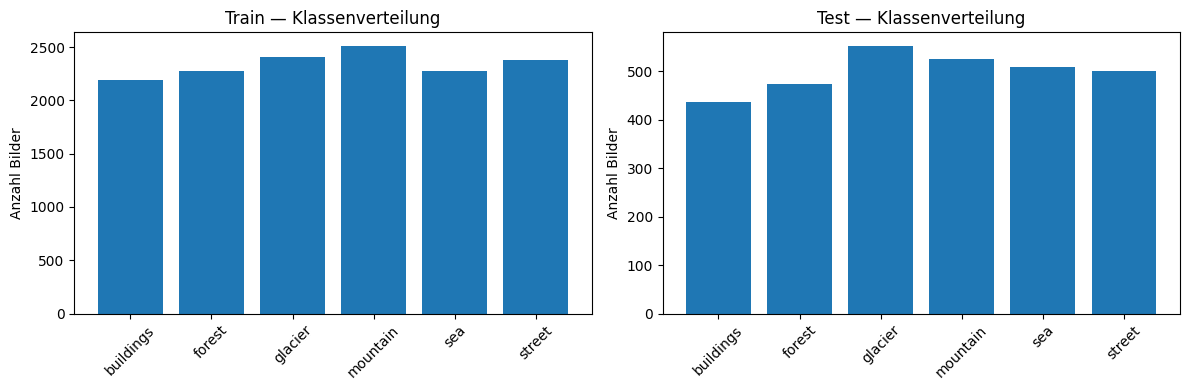

In [3]:
# Klassenverteilung im Train- und Test-Split
label_names = dataset["train"].features["label"].names
train_labels = dataset["train"]["label"]
test_labels = dataset["test"]["label"]

train_counts = pd.Series(train_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

dist_df = pd.DataFrame(
    {"Klasse": label_names, "Train": train_counts.values, "Test": test_counts.values}
)
dist_df["Train %"] = (dist_df["Train"] / dist_df["Train"].sum() * 100).round(1)
dist_df["Test %"] = (dist_df["Test"] / dist_df["Test"].sum() * 100).round(1)
print(dist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(label_names, train_counts.values)
axes[0].set_title("Train — Klassenverteilung")
axes[0].set_ylabel("Anzahl Bilder")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(label_names, test_counts.values)
axes[1].set_title("Test — Klassenverteilung")
axes[1].set_ylabel("Anzahl Bilder")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Fazit Klassenverteilung

Sowohl das Train als auch das Test Datafram hat eine ausgewogene Klassenverteilung. Es benötigt keine Oversampling oder Undersampling einer Klasse.

- Train Dataset: 
  - Die `mountain` Klasse hat am meisten Vorkommnisse mit knapp unter 2500 Bilder. 
  - Die `buildings` Klasse und die `sea` Klasse haben am wenigsten ausprägungen mit ca. 2200 ausprägungen.
- Test Dataset:
  - Die `glacier` Klasse hat am meisten ausprägungen mit ca. 560 Bilder.
  - Die `buildings` Klasse hat am wenigsten ausprägungen mit 440 Bildern. 
  
Die Klassenimbalance ist moderat und sollte keine Auswirkungen auf die Modelle haben. 

### Beispielbilder

Je 2 Beispielbilder pro Klasse zur visuellen Inspektion.

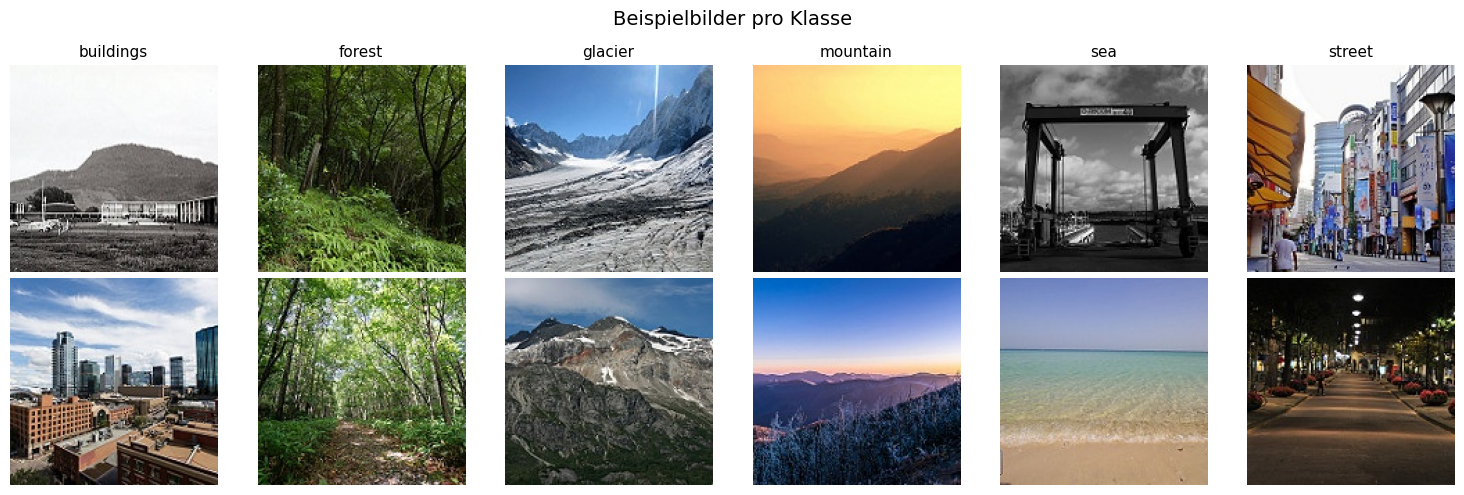

In [4]:
# Beispielbilder pro Klasse anzeigen
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle("Beispielbilder pro Klasse", fontsize=14)

for class_idx, class_name in enumerate(label_names):
    class_samples = dataset["train"].filter(lambda x: x["label"] == class_idx)
    for row in range(2):
        ax = axes[row, class_idx]
        ax.imshow(class_samples[row]["image"])
        ax.axis("off")
        if row == 0:
            ax.set_title(class_name, fontsize=11)

plt.tight_layout()
plt.show()

### Fazit Beispielbilder pro Klasse

Meine vorhersage für die Modelle ist: 
- Die Klasse `forest` wird wahrscheinlich am einfachstenzu unterscheiden sein: Vertikale kanten und grün dominant. 
- Die Klassen `buildings` und `street` könnten Problematisch zu unterscheiden sein. Bei dem ersten Beispielbild von `street` sieht man auch Gebäude was schwer zu unterscheiden sein kann für das Modell.
- Auch die Klassen `glacier` und `mountain` können schwer vorhersagbar sein für das Modell, da bei den `glacier` Beispielbildern auch Berge zu sehen sind. 
- Bei dem ersten Beispielbild von `sea` und `building` ist zu erkennen, dass der Datensatz auch Schwarz-Weiss Bilder enthält. Das Modell kann sich somit nicht lediglich auf die Farbkanäle verlassen. 

### Bildgrössen und Pixelwerte

Prüfen, ob alle Bilder die gleiche Grösse haben und wie der Wertebereich aussieht.

In [5]:
# Bildgrössen in allen Splits prüfen
train_sizes = [dataset["train"][i]["image"].size for i in range(len(dataset["train"]))]
test_sizes = [dataset["test"][i]["image"].size for i in range(len(dataset["test"]))]

unique_train_sizes = set(train_sizes)
unique_test_sizes = set(test_sizes)

print(f"Einzigartige Bildgrössen im Train-Split: {unique_train_sizes}")
print(f"Einzigartige Bildgrössen im Test-Split:  {unique_test_sizes}")

sample_img = dataset["train"][0]["image"]
img_array = np.array(sample_img)
print(f"\nShape eines Beispielbildes: {img_array.shape}")
print(f"Wertebereich: [{img_array.min()}, {img_array.max()}]")
print(f"Dtype: {img_array.dtype}")

Einzigartige Bildgrössen im Train-Split: {(150, 136), (150, 81), (150, 145), (150, 142), (150, 105), (150, 102), (150, 108), (150, 111), (150, 120), (150, 123), (150, 135), (150, 141), (150, 144), (150, 150), (150, 147), (150, 110), (150, 113), (150, 119), (150, 131), (150, 76), (150, 134), (150, 140), (150, 143), (150, 146), (150, 149), (150, 100), (150, 97), (150, 103), (150, 115), (150, 124), (150, 133)}
Einzigartige Bildgrössen im Test-Split:  {(150, 149), (150, 110), (150, 81), (150, 141), (150, 131), (150, 76), (150, 150), (150, 72)}

Shape eines Beispielbildes: (150, 150, 3)
Wertebereich: [0, 255]
Dtype: uint8


### Fazit Bildgrössen

Die Bilddimensionen sind in der Höhe immer 150 pixel. In der Breite variieren die Bilder jedoch. Im Trainings Datensatz ist die Bildbreite zwischen 81 pixel und 150 pixel. Im Test Datensatz sind die Bildbreiten zwischen 72 pixel und 150 pixeln. 

Dies muss bei dem Preprocessing Berücksichtigt werden. 

### Pixelwert-Verteilung pro Kanal pro Klasse

Boxplot der mittleren Pixelwerte pro RGB-Kanal, aufgeschlüsselt nach Klasse (je 200 Bilder pro Klasse). So lässt sich erkennen, ob bestimmte Klassen systematisch andere Farbverteilungen aufweisen.

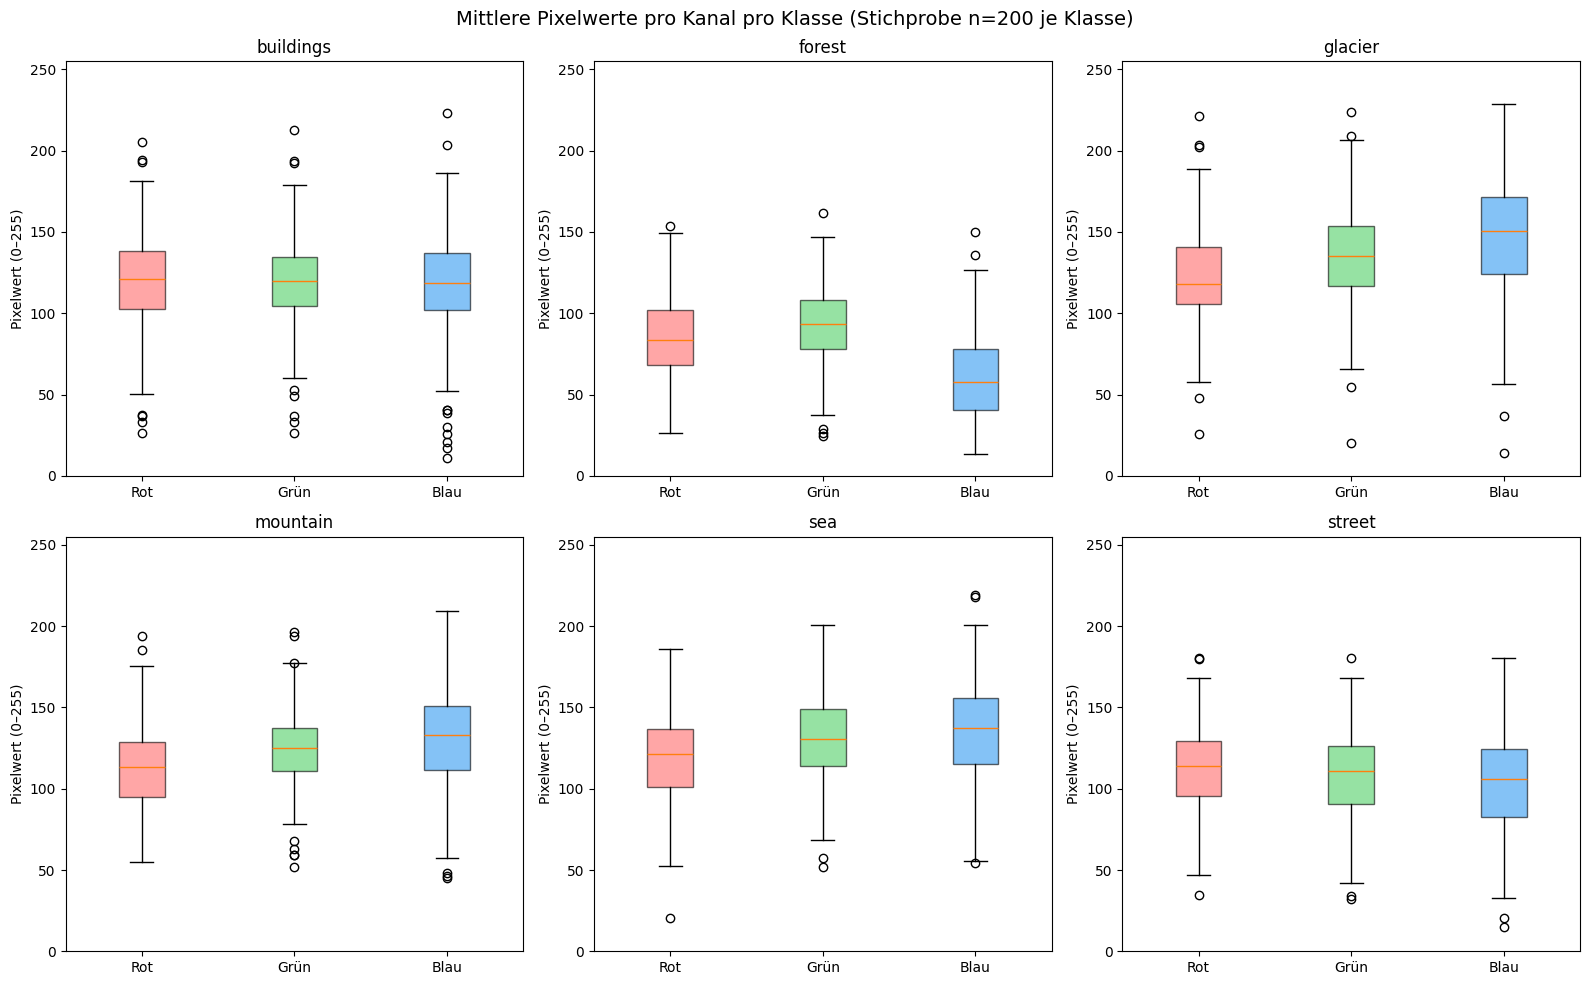


Klasse              R        G        B
--------------------------------------
buildings       118.8    119.4    118.1
forest           84.9     92.3     60.7
glacier         120.4    134.2    146.1
mountain        113.4    124.6    131.2
sea             119.0    129.4    136.8
street          111.5    107.5    103.6


In [6]:
# Pixelwert-Verteilung pro Kanal pro Klasse
rng = np.random.default_rng(RANDOM_SEED)
n_samples_per_class = 200
all_labels = dataset["train"]["label"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Mittlere Pixelwerte pro Kanal pro Klasse (Stichprobe n=200 je Klasse)", fontsize=14
)

summary = {}

for class_idx, class_name in enumerate(label_names):
    ax = axes[class_idx // 3, class_idx % 3]

    class_indices = [i for i, lbl in enumerate(all_labels) if lbl == class_idx]
    sample_indices = rng.choice(
        class_indices, size=min(n_samples_per_class, len(class_indices)), replace=False
    )

    pixel_data = {"R": [], "G": [], "B": []}
    for idx in sample_indices:
        img = np.array(dataset["train"][int(idx)]["image"])
        for c, name in enumerate(["R", "G", "B"]):
            pixel_data[name].append(img[:, :, c].mean())

    summary[class_name] = pixel_data

    bp = ax.boxplot(
        [pixel_data["R"], pixel_data["G"], pixel_data["B"]],
        tick_labels=["Rot", "Grün", "Blau"],
        patch_artist=True,
    )
    colors = ["#FF6B6B", "#51CF66", "#339AF0"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(class_name, fontsize=12)
    ax.set_ylabel("Pixelwert (0–255)")
    ax.set_ylim(0, 255)

plt.tight_layout()
plt.show()

# Zusammenfassung: Mittelwerte pro Klasse und Kanal
print(f"\n{'Klasse':<12} {'R':>8} {'G':>8} {'B':>8}")
print("-" * 38)
for class_name, data in summary.items():
    print(
        f"{class_name:<12} {np.mean(data['R']):>8.1f} {np.mean(data['G']):>8.1f} {np.mean(data['B']):>8.1f}"
    )

### Fazit der mittleren Farbkanalwerte pro Klasse
**Beobachtungen:**

- `forest` ist die am einfachsten unterscheidbare Klasse: Sie hat die niedrigste Gesamthelligkeit und eine Grün Dominanz. Der blaue Kanal ist mit 60.7 der niedrigste Wert im gesamten Datensatz.
- `glacier`, `mountain` und `sea` bilden ein problematisches Cluster. Alle drei Klassen sind blau dominant und liegen in der Gesamthelligkeit nahe beieinander. Die Farbinformation allein reicht hier nicht aus, um zuverlässig zwischen diesen Klassen zu unterscheiden.
- `buildings` zeigt ein nahezu perfekt neutrales Farbprofil. Rot, Grün und Blau sind sehr ausgeglichen. 
- `street` ist ebenfalls relativ ausgeglichen, wobei rot am dominantesten ist. Die `street` Pixelverteilung ist dazu noch leicht tiefer (dünkler) als die `buildings` Pixelwerte

**Implikationen für das Modell:**

1. **Farbinformation ist notwendig, aber nicht hinreichend.** Während `Forest` anhand der Farbverteilung gut trennbar ist, muss das CNN für die Unterscheidung von Glacier/Mountain/Sea auf **Textur- und Strukturmerkmale** (Kanten, Muster, räumliche Frequenzen) zurückgreifen. Dies muss anhand der Convulutional Layern entnommen werden
2. **Normalisierung ist wichtig.** Die Mittelwerte weichen deutlich von 128 (Mitte des [0, 255]-Bereichs) ab und unterscheiden sich zwischen den Kanälen. Eine kanalweise Normalisierung hilft dem Modell, schneller zu konvergieren, da die Eingabedaten zentriert und skaliert werden.

## Preprocessing

### Train/Validation-Split und Kanal-Statistiken berechnen

Zuerst wird der Train/Validation-Split (80/20, stratifiziert) durchgeführt. Danach werden Mittelwerte und Standardabweichungen pro RGB-Kanal **ausschliesslich über den Trainings-Split** berechnet, nicht über den gesamten Datensatz, um Data Leakage zu vermeiden.

Der Validation Split entsteht aus 20% von den vorgegebenen trainings Datensatz. 
- `train`:        80% von dem **Train** Datensatz
- `validation`:   20% von dem **Train** Datensatz
- `test`:         100% von dem **Test** Datensatz

In [7]:
# Train/Validation-Split zuerst, damit Kanal-Statistiken nur auf Trainingsdaten berechnet werden
train_indices, val_indices = train_test_split(
    range(len(dataset["train"])),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=dataset["train"]["label"],
)

# Kanal-Mittelwerte und Standardabweichungen NUR über den Train-Split berechnen
# Validation- und Test-Daten dürfen nicht einfliessen (Data Leakage)
channel_sum = np.zeros(3)
channel_sq_sum = np.zeros(3)
n_pixels = 0

for i in train_indices:
    img = np.array(dataset["train"][i]["image"], dtype=np.float32) / 255.0
    channel_sum += img.sum(axis=(0, 1))
    channel_sq_sum += (img**2).sum(axis=(0, 1))
    n_pixels += img.shape[0] * img.shape[1]

channel_mean = channel_sum / n_pixels
channel_std = np.sqrt(channel_sq_sum / n_pixels - channel_mean**2)

print(f"Train-Split: {len(train_indices)} Bilder, Val-Split: {len(val_indices)} Bilder")
print(f"Channel means (nur Train-Split): {channel_mean}")
print(f"Channel stds  (nur Train-Split): {channel_std}")

Train-Split: 11227 Bilder, Val-Split: 2807 Bilder
Channel means (nur Train-Split): [0.43018795 0.45737195 0.45355669]
Channel stds  (nur Train-Split): [0.26945614 0.26800597 0.29854997]


### Transform-Pipeline

**Train Pipeline**
- `RandomResizedCrop` (64x64) für Training: Aus den ~150x150 Bildern wird pro Aufruf ein zufälliger 64x64-Ausschnitt genommen. Der Ausschnitt darf zwischen 40% und 100% gross sein. Das wirkt als Data Augmentation.
- `RandomHorizontalFlip` Die Bilder werden mit einer Wahrscheinlichkeit von 50% Horizontal geflipped. Das macht das Modell robuster. 
- `ToTensor` wandelt die Bilder von einem PIL-Bild zu einem PyTorch-Tensor um. Dabei wird:
  - Wertebereich von 0–255 auf 0–1 skaliert
  - Format wird von HWC (64, 64, 3) zu CHW (3, 64, 64) geändert
- `Normalize` Hier werden die Pixelwerte pro Farbkanal normalisiert.
  - $x_{neu} = \frac{x - \text{mean}}{\text{std}}$

**Validation und Test Pipeline**
- `Resize` (64x64): Das gesamte Bild wird auf 64x64 herunter skaliert, damit keine Bildinformation durch Cropping verloren geht und die Evaluation auf dem vollständigen Bildinhalt basiert.

In [ ]:
# Train: RandomResizedCrop + HorizontalFlip als Data Augmentation
transform_train = transforms.Compose(
    [
        transforms.RandomResizedCrop(64, scale=(0.4, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),  # PIL -> Tensor [0,1], HWC -> CHW
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)


# Validation/Test: CenterCrop für deterministische Evaluation
transform_eval = transforms.Compose(
    [
        transforms.Resize((64, 64)),  # Beide Dimensionen auf 64x64 erzwingen
        transforms.ToTensor(),
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)

### PyTorch Dataset-Wrapper

Wrapper-Klasse, die das HuggingFace Dataset in ein PyTorch Dataset konvertiert und den Transform anwendet.

In [9]:
# PyTorch Dataset-Wrapper für HuggingFace Dataset
class IntelImageDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        image = sample["image"]
        label = sample["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

### Train/Validation/Test-Split

`train_indices` und `val_indices` wurden bereits oben erstellt (80/20, stratifiziert). Hier werden die HuggingFace-Subsets und PyTorch Datasets daraus erzeugt. Das Testset bleibt unverändert.

In [10]:
# train_indices und val_indices wurden oben bei der Kanal-Statistik-Berechnung erstellt
hf_train = dataset["train"].select(train_indices)
hf_val = dataset["train"].select(val_indices)

train_dataset = IntelImageDataset(hf_train, transform=transform_train)
val_dataset = IntelImageDataset(hf_val, transform=transform_eval)
test_dataset = IntelImageDataset(dataset["test"], transform=transform_eval)

print(f"Train:      {len(train_dataset)} Bilder")
print(f"Validation: {len(val_dataset)} Bilder")
print(f"Test:       {len(test_dataset)} Bilder")

Train:      11227 Bilder
Validation: 2807 Bilder
Test:       3000 Bilder


### DataLoaders erstellen

DataLoader für Train, Validation und Test mit initialer Batch-Size von 64. Sanity Check der Batch-Dimensionen und Pixelwerte.

In [11]:
# DataLoaders erstellen
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity Check: ein Batch laden
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # [64, 3, 64, 64]
print(f"Labels shape: {labels.shape}")  # [64]
print(f"Pixel range:  [{images.min():.2f}, {images.max():.2f}]")

Batch shape: torch.Size([64, 3, 64, 64])
Labels shape: torch.Size([64])
Pixel range:  [-1.71, 2.11]


## Schritt 1: Setup (Device, Metriken, W&B)

Als Kostenfunktion (Loss-Funktion) wird `CrossEntropyLoss` verwendet. `CrossEntropyLoss` wird verwendet, weil das Modell Bilder mehreren möglichen Klassen zuordnen soll, wobei jedes Bild genau eine richtige Klasse besitzt. Die Funktion misst, wie gut die Vorhersage des Modells mit dem tatsächlichen Klassenlabel übereinstimmt, und eignet sich deshalb gut für Multiclass-Classification.

In [12]:
# Device Setup (Apple Silicon MPS / CUDA / CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

# Kostenfunktion
criterion = nn.CrossEntropyLoss()

# Klassennamen
CLASS_NAMES = dataset["train"].features["label"].names
print(f"Klassen ({NUM_CLASSES}): {CLASS_NAMES}")

Device: mps
Klassen (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### W&B Login

Authentifizierung bei Weights & Biases für Experiment-Tracking.

In [13]:
# W&B Login
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/lucamanna/.netrc.
wandb: Currently logged in as: mannaluca02 (mannaluca02-fachhochschule-nordwestschweiz-fhnw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Schritt 2: Training- und Evaluierungsfunktionen

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Trainiert eine Epoche. Gibt (loss, accuracy) zurück."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = criterion(pred, Y)

        optimizer.zero_grad()  # entfernt alte Gradienten
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (pred.argmax(dim=1) == Y).sum().item()
        total += Y.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    """Evaluiert das Modell. Gibt (loss, accuracy) zurück."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Keine Gradientenberechnung für Evaluation
        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            pred = model(X)
            total_loss += criterion(pred, Y).item()
            correct += (pred.argmax(dim=1) == Y).sum().item()
            total += Y.size(0)

    return total_loss / len(loader), correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    log_wandb=True,
    return_best_state=False,
):
    """Kompletter Trainingsloop mit Best-Val-Acc-Checkpointing.

    Loggt zusaetzlich `val_acc_best` pro Epoche zu W&B und im History-Dict, damit
    die "Last-Epoch-Problematik" aus H1/H3/H5 strukturell gelöst ist: das
    Endergebnis wird nicht mehr von der letzten Epoche dominiert, sondern von der
    besten beobachteten.

    Wenn `return_best_state=True`, wird zusätzlich das State-Dict der besten
    Epoche zurückgegeben, damit der Aufrufer das Modell auf den Peak
    zurücksetzen kann. Default False, um Speicher zu sparen und die Signatur
    der Phase-1/2-Hypothesen-Zellen unverändert zu lassen.
    """
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_acc_best": [],
        "best_epoch": [],
    }
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None
    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            if return_best_state:
                best_state = copy.deepcopy(model.state_dict())

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_acc_best"].append(best_val_acc)
        history["best_epoch"].append(best_epoch)

        if log_wandb:
            wandb.log(
                {
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                    "val_acc_best": best_val_acc,
                    "best_epoch": best_epoch,
                }
            )

        print(
            f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
            f"Best {best_val_acc:.4f}@{best_epoch}"
        )

    elapsed = time.time() - start_time
    minutes, seconds = divmod(elapsed, 60)
    print(
        f"\nTraining abgeschlossen in {int(minutes)}m {seconds:.1f}s "
        f"({epochs} Epochen, {elapsed/epochs:.2f}s/Epoche)"
    )

    if return_best_state:
        return history, best_state
    return history


def plot_training(history, title="Lernkurven"):
    """Plottet Loss und Accuracy (Train vs Val). Gibt die Figure zurück."""
    epochs = range(len(history["train_loss"]))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], "b-", label="Train")
    ax1.plot(epochs, history["val_loss"], "r-", label="Validation")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_acc"], "b-", label="Train")
    ax2.plot(epochs, history["val_acc"], "r-", label="Validation")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

### Evaluierungs- und Visualisierungsfunktionen

- **Lernkurven** (Train Loss / Val Loss / Train Accuracy / Val Accuracy): wie sich das Modell über die Epochen entwickelt.
- **Generalization Gap**: zeigt direkt den Unterschied zwischen Trainings- und Validierungsleistung.
- **Confusion Matrix**: Sie zeigt für jede Klasse:
  - wie oft sie korrekt erkannt wurde
  - mit welchen anderen Klassen sie verwechselt wurde
- **Per-Class Metrics**: Balkendiagramm pro Klasse mit folgenden Werten:
  - Precision
  - Recall
  - F1-Score
- **Top-Loss Samples**: Zeigt die Bilder bei denen das Modell die grössten Schwierigkeiten hatte.
- **Cross-Validation Boxplot**: wie stabil das Modell über verschiedene Folds hinweg performt.

> Im Verlauf der Implementierung habe ich immer wie mehr auf W&B Plots gesetzt.

In [15]:
def denormalize(tensor, mean, std):
    """Denormalisiert einen Bild-Tensor für die Anzeige."""
    mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
    std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def collect_predictions(model, loader, device):
    """Sammelt Bilder, Predictions, Labels und Per-Sample-Losses vom gesamten Loader."""
    model.eval()
    all_images, all_labels, all_preds, all_probs, all_losses = [], [], [], [], []
    with torch.no_grad():
        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            logits = model(X)
            probs = torch.softmax(logits, dim=1)
            losses = F.cross_entropy(logits, Y, reduction="none")
            all_images.append(X.cpu())
            all_labels.append(Y.cpu())
            all_preds.append(logits.argmax(dim=1).cpu())
            all_probs.append(probs.cpu())
            all_losses.append(losses.cpu())
    return {
        "images": torch.cat(all_images),
        "y_true": torch.cat(all_labels).numpy(),
        "y_pred": torch.cat(all_preds).numpy(),
        "y_probs": torch.cat(all_probs).numpy(),
        "losses": torch.cat(all_losses).numpy(),
    }


def plot_cv_boxplot(fold_results, title="Cross-Validation Accuracy"):
    """Box-Plot und Einzelwerte der Cross-Validation Ergebnisse."""
    best_accs = [r["best_val_acc"] for r in fold_results]
    final_accs = [r["final_val_acc"] for r in fold_results]

    fig, ax = plt.subplots(figsize=(7, 5))
    bp = ax.boxplot(
        [best_accs, final_accs],
        tick_labels=["Best Val Acc", "Final Val Acc"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor("#2196F3")
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor("#FF9800")
    bp["boxes"][1].set_alpha(0.6)

    for i, data in enumerate([best_accs, final_accs], 1):
        ax.scatter([i] * len(data), data, color="black", zorder=5, s=50)
        for j, val in enumerate(data):
            ax.annotate(f"  Fold {j + 1}", (i, val), fontsize=8, va="center")

    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
    return fig


def evaluate_model(
    model,
    loader,
    class_names,
    device,
    mean,
    std,
    top_n_loss=16,
    log_wandb=True,
):
    """Sammelt Predictions und loggt alle Rohdaten zu W&B, damit Confusion Matrix,
    Per-Class Metrics und Top-Loss Samples im W&B-Report interaktiv dargestellt werden.
    Erzeugt keine Plots im Notebook."""
    results = collect_predictions(model, loader, device)
    y_true = results["y_true"]
    y_pred = results["y_pred"]

    report = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True
    )
    acc = float(np.mean(y_true == y_pred))

    if log_wandb and wandb.run is not None:
        # Confusion Matrix — native interaktiv via wandb.plot.confusion_matrix
        wandb.log(
            {
                "eval/confusion_matrix": wandb.plot.confusion_matrix(
                    y_true=y_true, preds=y_pred, class_names=class_names
                )
            }
        )

        # Drei separate native Bar-Charts via wandb.plot.bar.
        # Enthalten alle Klassen + macro/weighted avg als Summary-Rows.
        groups = list(class_names) + ["macro avg", "weighted avg"]
        bar_panels = {}
        for metric, panel_key, title in [
            ("precision", "eval/per_class_precision", "Per-Class Precision"),
            ("recall", "eval/per_class_recall", "Per-Class Recall"),
            ("f1-score", "eval/per_class_f1", "Per-Class F1-Score"),
        ]:
            tbl = wandb.Table(
                columns=["class", metric],
                data=[[g, float(report[g][metric])] for g in groups],
            )
            bar_panels[panel_key] = wandb.plot.bar(tbl, "class", metric, title=title)
        wandb.log(bar_panels)

        # Classification Report als flache Tabelle (für Detail-Ansicht im Report)
        wandb.log(
            {
                "eval/classification_report": wandb.Table(
                    columns=["class", "precision", "recall", "f1-score", "support"],
                    data=[
                        [
                            name,
                            report[name]["precision"],
                            report[name]["recall"],
                            report[name]["f1-score"],
                            int(report[name]["support"]),
                        ]
                        for name in class_names
                    ],
                ),
                "eval/accuracy": acc,
            }
        )

        # Top-Loss Samples als Table mit Bildern -> sortierbares Panel im Report
        # Zusaetzliche Spalte "run" erleichtert Zuordnung beim Vergleich mehrerer Modelle.
        run_name = wandb.run.name if wandb.run is not None else "unknown"
        top_idx = np.argsort(results["losses"])[-top_n_loss:][::-1]
        top_loss_table = wandb.Table(
            columns=["run", "image", "true", "pred", "confidence", "loss"]
        )
        for idx in top_idx:
            img = (
                denormalize(results["images"][idx], mean, std).permute(1, 2, 0).numpy()
            )
            top_loss_table.add_data(
                run_name,
                wandb.Image(img),
                class_names[int(y_true[idx])],
                class_names[int(y_pred[idx])],
                float(results["y_probs"][idx][int(y_pred[idx])]),
                float(results["losses"][idx]),
            )
        wandb.log({"eval/top_loss_samples": top_loss_table})

    print(f"\nGesamtgenauigkeit: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return results

### Cross-Validation-Visualisierungen

- **Per-Class Accuracy pro Fold**: gruppiertes Balkendiagramm, das die Accuracy jeder Klasse für jeden einzelnen Fold darstellt.
- **Mean ± Std der Per-Class Accuracy**: ergänzt die klassenweisen Fold-Ergebnisse durch den Mittelwert und die Standardabweichung, um die Stabilität der Klassenleistung über alle Folds hinweg sichtbar zu machen.

In [16]:
# Per-Class Accuracy pro Fold und Mean ± Std der Per-Class Accuracy


def plot_cv_per_class_accuracy(
    fold_predictions,
    class_names,
    title="Cross-Validation — Per-Class Accuracy pro Fold",
):
    """Gruppiertes Balkendiagramm: Accuracy pro Klasse, aufgeschluesselt nach Fold."""
    n_folds = len(fold_predictions)
    n_classes = len(class_names)

    # Per-Class Accuracy pro Fold berechnen
    per_class_accs = np.zeros((n_folds, n_classes))
    for f_idx, pred in enumerate(fold_predictions):
        for c_idx in range(n_classes):
            mask = pred["y_true"] == c_idx
            if mask.sum() > 0:
                per_class_accs[f_idx, c_idx] = (pred["y_pred"][mask] == c_idx).mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(n_classes)
    width = 0.8 / n_folds

    for f_idx in range(n_folds):
        offset = (f_idx - n_folds / 2 + 0.5) * width
        ax.bar(
            x + offset,
            per_class_accs[f_idx],
            width,
            label=f"Fold {f_idx + 1}",
            alpha=0.8,
        )

    # Mean + Std als Fehlerbalken
    mean_accs = per_class_accs.mean(axis=0)
    std_accs = per_class_accs.std(axis=0)
    ax.errorbar(
        x,
        mean_accs,
        yerr=std_accs,
        fmt="ko",
        capsize=5,
        capthick=2,
        linewidth=0,
        elinewidth=2,
        label="Mean ± Std",
        zorder=5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()
    return fig

## Schritt 3: CNN-Basismodell

Architektur für 64x64x3 Bilder (Resize zur Verkürzung der Trainingszeit):
- 3 Conv-Blöcke (Conv2d + ReLU + MaxPool2d) für Feature-Extraktion
- 2 Fully Connected Layers für Klassifikation
- Kein Dropout, kein BatchNorm (Vorgabe Stage 1)
- Output: raw logits (CrossEntropyLoss enthält Softmax)
- Die Linear-Layer-Grösse wird automatisch aus der Bildgrösse berechnet

In [17]:
class BaseCNN(nn.Module):
    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # Feature-Map-Grösse nach 3x MaxPool2d(2)
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Modell instanzieren und Architektur prüfen
model = BaseCNN(NUM_CLASSES).to(device)
print(model)
print(f"\nParameter: {sum(p.numel() for p in model.parameters()):,}")

# Forward-Pass Test mit aktueller Bildgrösse
with torch.no_grad():
    test_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    test_output = model(test_input)
    print(f"\nInput:  {test_input.shape}")
    print(f"Output: {test_output.shape}")  # Erwartet: [2, 6]

BaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)

Parameter: 548,774

Input:  torch.Size([2, 3, 64, 64])
Output: torch.Size([2, 6])


## Schritt 4: Overfitting-Test

Laut Aufgabenstellung (Punkt 3d): Trainiere auf einem einzelnen Batch. Der Loss muss gegen 0 gehen. Das bestätigt, dass Modell und Training-Loop korrekt funktionieren.

Epoch   0 | Train Loss: 1.7883  Acc: 0.1406 | Val Loss: 1.7796  Acc: 0.3438 | Best 0.3438@0
Epoch   1 | Train Loss: 1.7796  Acc: 0.3438 | Val Loss: 1.7721  Acc: 0.3281 | Best 0.3438@0
Epoch   2 | Train Loss: 1.7721  Acc: 0.3281 | Val Loss: 1.7650  Acc: 0.3594 | Best 0.3594@2
Epoch   3 | Train Loss: 1.7650  Acc: 0.3594 | Val Loss: 1.7577  Acc: 0.3281 | Best 0.3594@2
Epoch   4 | Train Loss: 1.7577  Acc: 0.3281 | Val Loss: 1.7502  Acc: 0.3438 | Best 0.3594@2
Epoch   5 | Train Loss: 1.7502  Acc: 0.3438 | Val Loss: 1.7417  Acc: 0.3594 | Best 0.3594@2
Epoch   6 | Train Loss: 1.7417  Acc: 0.3594 | Val Loss: 1.7321  Acc: 0.3438 | Best 0.3594@2
Epoch   7 | Train Loss: 1.7321  Acc: 0.3438 | Val Loss: 1.7211  Acc: 0.3438 | Best 0.3594@2
Epoch   8 | Train Loss: 1.7211  Acc: 0.3438 | Val Loss: 1.7087  Acc: 0.3438 | Best 0.3594@2
Epoch   9 | Train Loss: 1.7087  Acc: 0.3438 | Val Loss: 1.6947  Acc: 0.3438 | Best 0.3594@2
Epoch  10 | Train Loss: 1.6947  Acc: 0.3438 | Val Loss: 1.6792  Acc: 0.3438 | Be

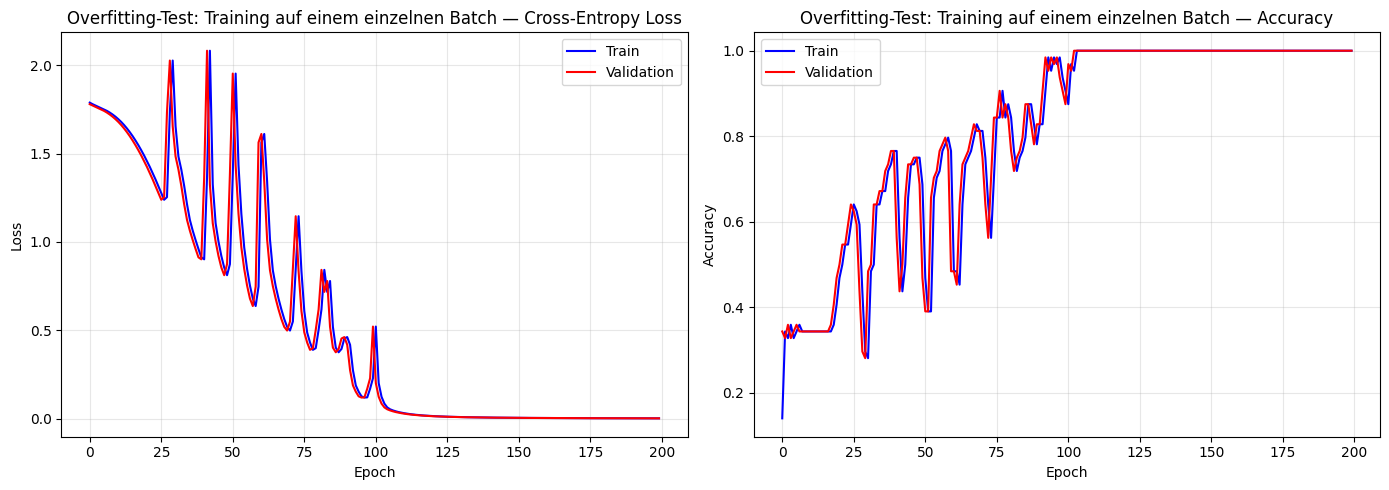


Final Loss: 0.001984 | Final Acc: 1.0000
BESTANDEN: Modell kann einen Batch overfitten. Training-Loop funktioniert korrekt.


In [18]:
# Overfitting-Test: ein einzelner Batch, 200 Iterationen mit höherer LR

overfit_model = BaseCNN(NUM_CLASSES).to(device)
overfit_optimizer = optim.SGD(overfit_model.parameters(), lr=0.05)

# Einen Batch extrahieren und als DataLoader wrappen
single_batch_X, single_batch_Y = next(iter(train_loader))
single_batch_dataset = TensorDataset(single_batch_X, single_batch_Y)
single_batch_loader = DataLoader(single_batch_dataset, batch_size=len(single_batch_X))

# 200 Epochs = 200 Iterationen (Loader enthält nur 1 Batch)
history_overfit = train_model(
    overfit_model,
    single_batch_loader,
    single_batch_loader,  # Val = gleicher Batch (Overfitting-Test)
    criterion,
    overfit_optimizer,
    device,
    epochs=200,
    log_wandb=False,
)

plot_training(
    history_overfit, title="Overfitting-Test: Training auf einem einzelnen Batch"
)

final_loss = history_overfit["train_loss"][-1]
final_acc = history_overfit["train_acc"][-1]
print(f"\nFinal Loss: {final_loss:.6f} | Final Acc: {final_acc:.4f}")
if final_loss < 0.01 and final_acc > 0.99:
    print(
        "BESTANDEN: Modell kann einen Batch overfitten. Training-Loop funktioniert korrekt."
    )
else:
    print("NICHT BESTANDEN: Loss konvergiert nicht gegen 0.")

### Beobachtungen Overfitting-Test

**Train vs. Validation identisch:** Da beide Kurven auf exakt denselben Daten operieren (gleicher DataLoader für Train und Validation), liegen sie nahezu perfekt übereinander. Der minimale Unterschied entsteht dadurch, dass `train_epoch()` im `model.train()`-Modus läuft und die Metriken **während** des Gradientenupdates berechnet (der Loss am Anfang des Batches, bevor die Gewichte aktualisiert werden), während `evaluate()` im `model.eval()`-Modus die Metriken **nach** dem Update berechnet. Daher ist die rote Validation-Kurve immer minimal besser als die blaue Train-Kurve.


**Spikes im Verlauf:** Die Spikes entstehen durch die Kombination aus hoher Lernrate (0.05) und SGD ohne Momentum auf nur einem einzigen Batch. Bei einem einzelnen Batch von 64 Bildern ist die Loss-Landschaft nicht glatt, sondern hat krümmungen. Mit `lr=0.05` sind die Gradientenschritte gross genug, um über ein lokales Minimum hinauszuschiessen und in einen Bereich mit höherem Loss zu springen. Das Modell "springt" dann wieder zurück, was die wiederholten Spikes erklärt.

Der Gesamttrend ist klar abwärts, und ab ca. Epoch 150 konvergiert der Loss stabil gegen 0. Die Spikes sind also kein Problem. Sie zeigen nur, dass die LR für diesen kleinen Datensatz aggressiv ist. Mit einer kleineren LR (z.B. 0.01) wären die Kurven glatter, aber die Konvergenz langsamer.

## Schritt 5: Basis-Training mit W&B

Training des Basismodells mit SGD (ohne Momentum), lr=0.05, 150 Epochs. W&B trackt alle Metriken.

In [19]:
# Basis-Training
run = wandb.init(
    project="del-mini-challenge",
    name="base-model-sgd-lr0.05",
    config={
        "architecture": "BaseCNN",
        "optimizer": "SGD",
        "lr": 0.05,
        "momentum": 0.0,
        "batch_size": BATCH_SIZE,
        "epochs": 150,
        "num_classes": NUM_CLASSES,
    },
)

model = BaseCNN(NUM_CLASSES).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.05)
wandb.watch(model, log="all")

history_base = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, epochs=150
)

Epoch   0 | Train Loss: 1.4319  Acc: 0.4348 | Val Loss: 1.1624  Acc: 0.5575 | Best 0.5575@0
Epoch   1 | Train Loss: 1.1265  Acc: 0.5475 | Val Loss: 1.0127  Acc: 0.6074 | Best 0.6074@1
Epoch   2 | Train Loss: 1.0324  Acc: 0.5887 | Val Loss: 1.2185  Acc: 0.5020 | Best 0.6074@1
Epoch   3 | Train Loss: 0.9450  Acc: 0.6358 | Val Loss: 0.9090  Acc: 0.6534 | Best 0.6534@3
Epoch   4 | Train Loss: 0.8658  Acc: 0.6689 | Val Loss: 0.8978  Acc: 0.6427 | Best 0.6534@3
Epoch   5 | Train Loss: 0.8293  Acc: 0.6917 | Val Loss: 0.8913  Acc: 0.6605 | Best 0.6605@5
Epoch   6 | Train Loss: 0.7923  Acc: 0.7098 | Val Loss: 0.8012  Acc: 0.7061 | Best 0.7061@6
Epoch   7 | Train Loss: 0.7389  Acc: 0.7271 | Val Loss: 0.8860  Acc: 0.6587 | Best 0.7061@6
Epoch   8 | Train Loss: 0.7148  Acc: 0.7345 | Val Loss: 0.7295  Acc: 0.7228 | Best 0.7228@8
Epoch   9 | Train Loss: 0.6921  Acc: 0.7413 | Val Loss: 0.7316  Acc: 0.7253 | Best 0.7253@9
Epoch  10 | Train Loss: 0.6663  Acc: 0.7535 | Val Loss: 0.7679  Acc: 0.7040 | Be

### Evaluation Basismodell

Vollständige Evaluation auf dem Validierungsset. Alle Rohdaten (Confusion Matrix, Per-Class Precision/Recall/F1, Top-Loss Samples inkl. Bilder) werden zu W&B geloggt und ausschliesslich im **W&B-Report** interaktiv dargestellt. Im Notebook werden keine Plots mehr erzeugt.

In [20]:
# Vollständige Evaluation des Basismodells auf dem Validierungsset
# Rohdaten werden zu W&B geloggt; alle Visualisierungen im W&B-Report erzeugt.
results_base = evaluate_model(
    model,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

wandb.finish()


Gesamtgenauigkeit: 0.8532
              precision    recall  f1-score   support

   buildings       0.89      0.82      0.86       438
      forest       0.99      0.93      0.96       454
     glacier       0.79      0.80      0.80       481
    mountain       0.80      0.80      0.80       503
         sea       0.82      0.86      0.84       455
      street       0.84      0.91      0.88       476

    accuracy                           0.85      2807
   macro avg       0.86      0.85      0.85      2807
weighted avg       0.86      0.85      0.85      2807



best_epoch,▁▁▂▂▂▂▂▂▂▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇████████████
epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▃▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▇▅▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▇▇▇▇█▇▇▇▇█▇███████████████▇▇▇██▇█████
val_acc_best,▁▂▄▄▆▆▆▇▇▇██████████████████████████████
val_loss,█▇▆▆▄▅▄▃▃▂▁▂▄▂▂▂▁▁▁▁▄▂▂▁▂▂▂▂▂▂▂▂▂▄▆▂▂▅▂▃
best_epoch,98
epoch,149
eval/accuracy,0.85322


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Basis-modell-Report--VmlldzoxNjU5ODYwMQ" style="border:none;height:1024px;width:100%">


## Schritt 6: Lernraten-Tuning

Wir testen mehrere Lernraten (0.001, 0.005, 0.01, 0.05, 0.1) mit SGD ohne Momentum. Jedes Training wird als eigener W&B-Run geloggt. Anschliessend vergleichen wir die Lernkurven.

In [21]:
# LR-Tuning: mehrere Lernraten vergleichen
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
lr_histories = {}

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"Training mit lr={lr}")
    print(f"{'='*60}")

    run = wandb.init(
        project="del-mini-challenge",
        name=f"lr-tuning-{lr}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": lr,
            "momentum": 0.0,
            "batch_size": BATCH_SIZE,
            "epochs": LR_EPOCHS,
            "experiment": "lr-tuning",
        },
        reinit=True,
    )

    model_lr = BaseCNN(NUM_CLASSES).to(device)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr)

    lr_histories[lr] = train_model(
        model_lr,
        train_loader,
        val_loader,
        criterion,
        optimizer_lr,
        device,
        epochs=LR_EPOCHS,
    )

    wandb.finish()


Training mit lr=0.001


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   0 | Train Loss: 1.7887  Acc: 0.1714 | Val Loss: 1.7841  Acc: 0.1721 | Best 0.1721@0
Epoch   1 | Train Loss: 1.7808  Acc: 0.1894 | Val Loss: 1.7754  Acc: 0.2333 | Best 0.2333@1
Epoch   2 | Train Loss: 1.7712  Acc: 0.2430 | Val Loss: 1.7642  Acc: 0.2601 | Best 0.2601@2
Epoch   3 | Train Loss: 1.7581  Acc: 0.2703 | Val Loss: 1.7475  Acc: 0.2993 | Best 0.2993@3
Epoch   4 | Train Loss: 1.7380  Acc: 0.3448 | Val Loss: 1.7209  Acc: 0.3844 | Best 0.3844@4
Epoch   5 | Train Loss: 1.7049  Acc: 0.3906 | Val Loss: 1.6764  Acc: 0.4154 | Best 0.4154@5
Epoch   6 | Train Loss: 1.6507  Acc: 0.4080 | Val Loss: 1.6059  Acc: 0.4296 | Best 0.4296@6
Epoch   7 | Train Loss: 1.5766  Acc: 0.4164 | Val Loss: 1.5183  Acc: 0.4421 | Best 0.4421@7
Epoch   8 | Train Loss: 1.5029  Acc: 0.4274 | Val Loss: 1.4477  Acc: 0.4556 | Best 0.4556@8
Epoch   9 | Train Loss: 1.4544  Acc: 0.4334 | Val Loss: 1.4051  Acc: 0.4646 | Best 0.4646@9
Epoch  10 | Train Loss: 1.4285  Acc: 0.4438 | Val Loss: 1.3754  Acc: 0.4777 | Be

best_epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██
epoch,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▁▃▄▄▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████
train_loss,███▇▇▆▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████
val_acc_best,▁▂▂▂▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██████████
val_loss,██▇▇▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
best_epoch,96
epoch,99
train_acc,0.69564
train_loss,0.8217



Training mit lr=0.005


...

Epoch   0 | Train Loss: 1.3605  Acc: 0.4588 | Val Loss: 1.1593  Acc: 0.5262 | Best 0.5262@0
Epoch   1 | Train Loss: 1.0990  Acc: 0.5662 | Val Loss: 0.9257  Acc: 0.6359 | Best 0.6359@1
Epoch   2 | Train Loss: 0.9818  Acc: 0.6199 | Val Loss: 0.8610  Acc: 0.6719 | Best 0.6719@2
Epoch   3 | Train Loss: 0.8907  Acc: 0.6573 | Val Loss: 0.7826  Acc: 0.7278 | Best 0.7278@3
Epoch   4 | Train Loss: 0.8422  Acc: 0.6802 | Val Loss: 0.7974  Acc: 0.7047 | Best 0.7278@3
Epoch   5 | Train Loss: 0.7943  Acc: 0.7037 | Val Loss: 0.7159  Acc: 0.7471 | Best 0.7471@5
Epoch   6 | Train Loss: 0.7384  Acc: 0.7249 | Val Loss: 0.7015  Acc: 0.7382 | Best 0.7471@5
Epoch   7 | Train Loss: 0.6980  Acc: 0.7447 | Val Loss: 0.8062  Acc: 0.7186 | Best 0.7471@5
Epoch   8 | Train Loss: 0.6777  Acc: 0.7472 | Val Loss: 0.6307  Acc: 0.7781 | Best 0.7781@8
Epoch   9 | Train Loss: 0.6531  Acc: 0.7570 | Val Loss: 0.6380  Acc: 0.7716 | Best 0.7781@8
Epoch  10 | Train Loss: 0.6245  Acc: 0.7699 | Val Loss: 0.6823  Acc: 0.7610 | Be

best_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅███
epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train_acc,▁▃▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▇▆▆▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▂▃▅▆▅▃▆▆▇▆█▇▇██▇▄▇▇▆█▇▇▇▇▇█▇█▇██▇█▇███
val_acc_best,▁▄▄▄▅▅▆▆▆▆▇▇▇▇██████████████████████████
val_loss,█▇▅▄▅▃▆▂▂▁▂▂▂▂▂▃▂▂▄▂▂▃▂▂▂▂▂▂▂▂▂▃▂▃▃▃▂▂▂▂
best_epoch,93
epoch,99
train_acc,0.93115
train_loss,0.19047



Training mit lr=0.1


Epoch   0 | Train Loss: 1.3467  Acc: 0.4597 | Val Loss: 1.0622  Acc: 0.5942 | Best 0.5942@0
Epoch   1 | Train Loss: 1.0746  Acc: 0.5670 | Val Loss: 1.0732  Acc: 0.5561 | Best 0.5942@0
Epoch   2 | Train Loss: 0.9695  Acc: 0.6214 | Val Loss: 1.1870  Acc: 0.5265 | Best 0.5942@0
Epoch   3 | Train Loss: 0.9040  Acc: 0.6521 | Val Loss: 0.8009  Acc: 0.6983 | Best 0.6983@3
Epoch   4 | Train Loss: 0.8341  Acc: 0.6855 | Val Loss: 0.7571  Acc: 0.7168 | Best 0.7168@4
Epoch   5 | Train Loss: 0.7826  Acc: 0.7075 | Val Loss: 0.8925  Acc: 0.6601 | Best 0.7168@4
Epoch   6 | Train Loss: 0.7669  Acc: 0.7155 | Val Loss: 0.7782  Acc: 0.7161 | Best 0.7168@4
Epoch   7 | Train Loss: 0.7012  Acc: 0.7424 | Val Loss: 0.7328  Acc: 0.7453 | Best 0.7453@7
Epoch   8 | Train Loss: 0.6708  Acc: 0.7513 | Val Loss: 0.6692  Acc: 0.7545 | Best 0.7545@8
Epoch   9 | Train Loss: 0.6529  Acc: 0.7618 | Val Loss: 0.5718  Acc: 0.8026 | Best 0.8026@9
Epoch  10 | Train Loss: 0.6177  Acc: 0.7744 | Val Loss: 0.7665  Acc: 0.7285 | Be

best_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅███
epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▃▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████████
train_loss,█▆▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▅▆▇▆▇▆▆▇▇█▇▇██▇█▇▇████▇█▇█▇▇██▇█▇▇▇█▇▇
val_acc_best,▁▁▁▄▄▆▆▆▆▆▇▇▇▇▇▇▇▇██████████████████████
val_loss,█▄▃▂▄▂▂▂▃▁▂▁▁▁▂▂▁▁▁▁▁▁▁▁▃▁▂▂▂▂▂▂▂▂▁▂▂▂▂▄
best_epoch,81
epoch,99
train_acc,0.92669
train_loss,0.20372


### Beste Lernrate

Wir ermitteln die beste Lernrate mit der Best Validation Accuracy pro Lernrate. Train-/Val-Loss- und Accuracy-Kurven aus den einzelnen Runs werden direkt im W&B-Report als Line-Plots nachgebaut; Generalization-Gap-Panels ebenfalls.


In [22]:
# Beste Lernrate ermitteln
best_lr = max(lr_histories.keys(), key=lambda lr: max(lr_histories[lr]["val_acc"]))
best_val_acc = max(lr_histories[best_lr]["val_acc"])
best_lr_epoch = int(np.argmax(lr_histories[best_lr]["val_acc"]))
print(
    f"\nBeste Lernrate: {best_lr} (Val Accuracy: {best_val_acc:.4f}, Epoche {best_lr_epoch})"
)

# W&B Summary-Run: interaktives Bar-Chart via wandb.plot.bar
run = wandb.init(
    project="del-mini-challenge",
    name="lr-tuning-summary",
    config={
        "experiment": "lr-tuning-summary",
        "learning_rates": [str(lr) for lr in lr_histories.keys()],
    },
    reinit=True,
)

best_acc_table = wandb.Table(
    columns=["lr", "best_val_acc"],
    data=[
        [str(lr), float(max(lr_histories[lr]["val_acc"]))] for lr in lr_histories.keys()
    ],
)
wandb.log(
    {
        "lr_tuning/best_accuracy": wandb.plot.bar(
            best_acc_table,
            "lr",
            "best_val_acc",
            title="Lernraten-Tuning — Best Validation Accuracy",
        ),
        "lr_tuning/best_lr": best_lr,
        "lr_tuning/best_val_acc": best_val_acc,
        "lr_tuning/best_epoch": best_lr_epoch,
    }
)
wandb.finish()


Beste Lernrate: 0.05 (Val Accuracy: 0.8650, Epoche 93)


lr_tuning/best_epoch,▁
lr_tuning/best_lr,▁
lr_tuning/best_val_acc,▁
lr_tuning/best_epoch,93
lr_tuning/best_lr,0.05
lr_tuning/best_val_acc,0.86498


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Learning-Rate-Tuning-Report--VmlldzoxNjYwMTUxMA" style="border:none;height:1024px;width:100%">

## Schritt 7: Batch-Size-Tuning

Wir testen verschiedene Batch-Sizes (16, 32, 64, 128) mit der besten Lernrate aus Schritt 6 (lr=0.05).

In [23]:
# Batch-Size-Tuning mit bester LR
batch_sizes = [16, 32, 64, 128]
bs_histories = {}

for bs in batch_sizes:
    print(f"\n{'='*60}")
    print(f"Training mit batch_size={bs}, lr={best_lr}")
    print(f"{'='*60}")

    # Neue DataLoader mit angepasster Batch-Size
    bs_train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    bs_val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

    run = wandb.init(
        project="del-mini-challenge",
        name=f"bs-tuning-{bs}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "momentum": 0.0,
            "batch_size": bs,
            "epochs": BS_EPOCHS,
            "experiment": "batch-size-tuning",
        },
        reinit=True,
    )

    model_bs = BaseCNN(NUM_CLASSES).to(device)
    optimizer_bs = optim.SGD(model_bs.parameters(), lr=best_lr)

    bs_histories[bs] = train_model(
        model_bs,
        bs_train_loader,
        bs_val_loader,
        criterion,
        optimizer_bs,
        device,
        epochs=BS_EPOCHS,
    )

    wandb.finish()


Training mit batch_size=16, lr=0.05


Epoch   0 | Train Loss: 1.2097  Acc: 0.5098 | Val Loss: 0.9312  Acc: 0.6277 | Best 0.6277@0
Epoch   1 | Train Loss: 0.9381  Acc: 0.6342 | Val Loss: 0.7806  Acc: 0.7207 | Best 0.7207@1
Epoch   2 | Train Loss: 0.8032  Acc: 0.7017 | Val Loss: 0.6556  Acc: 0.7645 | Best 0.7645@2
Epoch   3 | Train Loss: 0.7264  Acc: 0.7323 | Val Loss: 0.8375  Acc: 0.7057 | Best 0.7645@2
Epoch   4 | Train Loss: 0.6780  Acc: 0.7537 | Val Loss: 0.7166  Acc: 0.7439 | Best 0.7645@2
Epoch   5 | Train Loss: 0.6232  Acc: 0.7748 | Val Loss: 0.5972  Acc: 0.7859 | Best 0.7859@5
Epoch   6 | Train Loss: 0.6046  Acc: 0.7792 | Val Loss: 0.5648  Acc: 0.8055 | Best 0.8055@6
Epoch   7 | Train Loss: 0.5747  Acc: 0.7908 | Val Loss: 0.5477  Acc: 0.8137 | Best 0.8137@7
Epoch   8 | Train Loss: 0.5487  Acc: 0.8016 | Val Loss: 0.6049  Acc: 0.8001 | Best 0.8137@7
Epoch   9 | Train Loss: 0.5295  Acc: 0.8062 | Val Loss: 0.4932  Acc: 0.8294 | Best 0.8294@9
Epoch  10 | Train Loss: 0.5266  Acc: 0.8044 | Val Loss: 0.5639  Acc: 0.8069 | Be

best_epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅█████
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇████
train_acc,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████████████
train_loss,█▇▆▅▅▅▅▄▄▄▄▃▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁
val_acc,▁▃▄▆▇▅▇█▇▇▇▇██▇█▇█▇▇█▆▇▇▇▇█▇▇▇▇▆▇▇▇▇████
val_acc_best,▁▁▃▄▅▆▇▇▇▇▇▇▇▇▇█████████████████████████
val_loss,█▆▅▃▃▂▂▁▂▁▂▂▁▂▂▂▁▂▂▄▂▃▂▁▂▂▂▄▃▂▂▂▃▃▂▃▂▃▂▂
best_epoch,99
epoch,99
train_acc,0.90986
train_loss,0.24555



Training mit batch_size=32, lr=0.05


Epoch   0 | Train Loss: 1.2985  Acc: 0.4817 | Val Loss: 1.0008  Acc: 0.5935 | Best 0.5935@0
Epoch   1 | Train Loss: 1.0217  Acc: 0.6060 | Val Loss: 0.8345  Acc: 0.6815 | Best 0.6815@1
Epoch   2 | Train Loss: 0.9208  Acc: 0.6458 | Val Loss: 0.8829  Acc: 0.6605 | Best 0.6815@1
Epoch   3 | Train Loss: 0.8298  Acc: 0.6855 | Val Loss: 0.7800  Acc: 0.6886 | Best 0.6886@3
Epoch   4 | Train Loss: 0.7615  Acc: 0.7175 | Val Loss: 0.9422  Acc: 0.6395 | Best 0.6886@3
Epoch   5 | Train Loss: 0.7113  Acc: 0.7335 | Val Loss: 0.6218  Acc: 0.7838 | Best 0.7838@5
Epoch   6 | Train Loss: 0.6831  Acc: 0.7508 | Val Loss: 0.6093  Acc: 0.7823 | Best 0.7838@5
Epoch   7 | Train Loss: 0.6411  Acc: 0.7651 | Val Loss: 0.5763  Acc: 0.7998 | Best 0.7998@7
Epoch   8 | Train Loss: 0.6139  Acc: 0.7761 | Val Loss: 0.5719  Acc: 0.7998 | Best 0.7998@7
Epoch   9 | Train Loss: 0.5955  Acc: 0.7815 | Val Loss: 0.5925  Acc: 0.7912 | Best 0.7998@7
Epoch  10 | Train Loss: 0.5684  Acc: 0.7888 | Val Loss: 0.5223  Acc: 0.8169 | Be

...

Epoch   0 | Train Loss: 1.3912  Acc: 0.4524 | Val Loss: 1.0945  Acc: 0.5447 | Best 0.5447@0
Epoch   1 | Train Loss: 1.0963  Acc: 0.5662 | Val Loss: 0.9433  Acc: 0.6238 | Best 0.6238@1
Epoch   2 | Train Loss: 0.9814  Acc: 0.6247 | Val Loss: 1.0602  Acc: 0.5896 | Best 0.6238@1
Epoch   3 | Train Loss: 0.9197  Acc: 0.6505 | Val Loss: 0.8097  Acc: 0.7025 | Best 0.7025@3
Epoch   4 | Train Loss: 0.8411  Acc: 0.6834 | Val Loss: 0.7940  Acc: 0.7072 | Best 0.7072@4
Epoch   5 | Train Loss: 0.7948  Acc: 0.6999 | Val Loss: 0.8384  Acc: 0.6879 | Best 0.7072@4
Epoch   6 | Train Loss: 0.7642  Acc: 0.7142 | Val Loss: 0.6884  Acc: 0.7488 | Best 0.7488@6
Epoch   7 | Train Loss: 0.7182  Acc: 0.7318 | Val Loss: 1.1909  Acc: 0.5875 | Best 0.7488@6
Epoch   8 | Train Loss: 0.7154  Acc: 0.7383 | Val Loss: 0.9777  Acc: 0.6409 | Best 0.7488@6
Epoch   9 | Train Loss: 0.6842  Acc: 0.7452 | Val Loss: 0.6172  Acc: 0.7848 | Best 0.7848@9
Epoch  10 | Train Loss: 0.6547  Acc: 0.7609 | Val Loss: 0.6684  Acc: 0.7663 | Be

best_epoch,▁▁▁▁▁▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇██████████
epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
train_loss,█▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▃▂▅▆▇▆▇▆▆▇▆▆▇▇▇▇▇▇████▇█▇▇████▇█▇▇██▇█
val_acc_best,▁▁▃▅▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████████████
val_loss,▇▄▅▃█▂▃▃▂▃▂▃▂▁▂▁▂▁▂▁▁▁▂▂▁▁▂▂▁▁▃▁▂▁▁▂▂▂▁▂
best_epoch,81
epoch,99
train_acc,0.92776
train_loss,0.19702



Training mit batch_size=128, lr=0.05


Epoch   0 | Train Loss: 1.5332  Acc: 0.3863 | Val Loss: 1.2720  Acc: 0.5205 | Best 0.5205@0
Epoch   1 | Train Loss: 1.2640  Acc: 0.5037 | Val Loss: 1.2571  Acc: 0.5020 | Best 0.5205@0
Epoch   2 | Train Loss: 1.1475  Acc: 0.5484 | Val Loss: 1.1090  Acc: 0.5607 | Best 0.5607@2
Epoch   3 | Train Loss: 1.0737  Acc: 0.5782 | Val Loss: 1.0573  Acc: 0.5650 | Best 0.5650@3
Epoch   4 | Train Loss: 1.0275  Acc: 0.5983 | Val Loss: 1.0246  Acc: 0.5996 | Best 0.5996@4
Epoch   5 | Train Loss: 0.9824  Acc: 0.6165 | Val Loss: 0.9002  Acc: 0.6587 | Best 0.6587@5
Epoch   6 | Train Loss: 0.9414  Acc: 0.6429 | Val Loss: 0.8705  Acc: 0.6598 | Best 0.6598@6
Epoch   7 | Train Loss: 0.9113  Acc: 0.6471 | Val Loss: 0.8588  Acc: 0.6897 | Best 0.6897@7
Epoch   8 | Train Loss: 0.8662  Acc: 0.6741 | Val Loss: 0.7834  Acc: 0.7029 | Best 0.7029@8
Epoch   9 | Train Loss: 0.8268  Acc: 0.6898 | Val Loss: 0.7710  Acc: 0.7121 | Best 0.7121@9
Epoch  10 | Train Loss: 0.8170  Acc: 0.6983 | Val Loss: 0.8611  Acc: 0.6708 | Be

best_epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇███████
epoch,▁▁▁▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
train_acc,▁▃▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train_loss,██▇▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▁▃▄▄▅▄▆▆▇▆▇▇▇▇▇▇▇▇▆█▇██████▇▇████▇███▇█
val_acc_best,▁▂▃▃▄▅▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████████████
val_loss,██▆▅▄▃▃▅▃▃▂▃▂▂▂▁▂▂▁▃▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁
best_epoch,74
epoch,99
train_acc,0.90478
train_loss,0.26337


### Beste Batch-Size

Best Validation Accuracy pro Batch-Size. Train-/Val-Loss- und Accuracy-Kurven sowie Generalization-Gap werden im W&B-Report aus den per-run-Logs nachgebaut.


In [24]:
# Beste Batch-Size ermitteln
best_bs = max(bs_histories.keys(), key=lambda bs: max(bs_histories[bs]["val_acc"]))
best_bs_acc = max(bs_histories[best_bs]["val_acc"])
best_bs_epoch = int(np.argmax(bs_histories[best_bs]["val_acc"]))
print(
    f"\nBeste Batch-Size: {best_bs} (Val Accuracy: {best_bs_acc:.4f}, Epoche {best_bs_epoch})"
)
print(f"Beste Hyperparameter für Stage 1: lr={best_lr}, batch_size={best_bs}")

# W&B Summary-Run: interaktives Bar-Chart via wandb.plot.bar
run = wandb.init(
    project="del-mini-challenge",
    name="bs-tuning-summary",
    config={
        "experiment": "bs-tuning-summary",
        "batch_sizes": [str(bs) for bs in bs_histories.keys()],
    },
    reinit=True,
)

best_acc_table_bs = wandb.Table(
    columns=["batch_size", "best_val_acc"],
    data=[
        [str(bs), float(max(bs_histories[bs]["val_acc"]))] for bs in bs_histories.keys()
    ],
)
wandb.log(
    {
        "bs_tuning/best_accuracy": wandb.plot.bar(
            best_acc_table_bs,
            "batch_size",
            "best_val_acc",
            title="Batch-Size-Tuning — Best Validation Accuracy",
        ),
        "bs_tuning/best_bs": best_bs,
        "bs_tuning/best_val_acc": best_bs_acc,
        "bs_tuning/best_epoch": best_bs_epoch,
    }
)
wandb.finish()


Beste Batch-Size: 64 (Val Accuracy: 0.8675, Epoche 81)
Beste Hyperparameter für Stage 1: lr=0.05, batch_size=64


bs_tuning/best_bs,▁
bs_tuning/best_epoch,▁
bs_tuning/best_val_acc,▁
bs_tuning/best_bs,64
bs_tuning/best_epoch,81
bs_tuning/best_val_acc,0.86747


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Batch-size-Tuning-Report--VmlldzoxNjYwMTc1Ng" style="border:none;height:1024px;width:100%">

## Schritt 8: Cross-Validation (Statistischer Fehler)

5-Fold Cross-Validation auf dem gesamten Trainingsset mit den besten Hyperparametern. Ziel: Schätzung der Generalisierungs-Performance mit **Mittelwert** und einer korrekten Quantifizierung der Unsicherheit dieser Schätzung (**statistischer Fehler**).


### Standardabweichung vs. Standardfehler — was ist der "statistische Fehler"?

Bei K-Fold Cross-Validation erhalten wir K Accuracy-Werte (einen pro Fold) $a_1, a_2, \dots, a_K$. Daraus berechnen wir:

**Mittelwert** (Punktschätzung der Generalisierungs-Accuracy):

$$\bar{a} = \frac{1}{K}\sum_{i=1}^{K} a_i$$

**Stichproben-Standardabweichung** (SD) — beschreibt die *Streuung der einzelnen Fold-Accuracies* um den Mittelwert. Sie sagt aus, wie stark die Modell-Performance je nach Fold schwankt:

$$\mathrm{SD} = \sqrt{\frac{1}{K-1}\sum_{i=1}^{K} (a_i - \bar{a})^2}$$

**Standardfehler des Mittelwerts** (SE oder SEM) — beschreibt die *Unsicherheit der Schätzung von $\bar{a}$ selbst*. Das ist der **statistische Fehler** im Sinne der Aufgabenstellung:

$$\mathrm{SE} = \frac{\mathrm{SD}}{\sqrt{K}}$$

**95 %-Konfidenzintervall** (über die t-Verteilung, da K klein):

$$\mathrm{CI}_{95\%} = \bar{a} \pm t_{0.975,\,K-1} \cdot \mathrm{SE}$$

**Unterschied auf den Punkt gebracht:**

| Grösse | Was sie misst | Verhalten bei mehr Folds |
|---|---|---|
| **SD** | Streuung der Fold-Performance | bleibt etwa konstant (Eigenschaft der Daten/Modell-Stabilität) |
| **SE** | Unsicherheit unserer Mittelwert-Schätzung | wird kleiner ($\propto 1/\sqrt{K}$), je mehr Folds wir mitteln |

Der **statistische Fehler** der CV-Schätzung ist also der **SE**, nicht die SD. Die SD ist trotzdem nützlich, weil sie zeigt, wie stabil das Modell über verschiedene Datensplits hinweg ist.

**Wichtige Einschränkung:** Die K Folds teilen sich überlappende Trainingsdaten und sind deshalb nicht vollständig unabhängig. Die Formel $\mathrm{SE} = \mathrm{SD}/\sqrt{K}$ setzt Unabhängigkeit voraus und kann den wahren Fehler tendenziell unterschätzen (vgl. Bayle et al., 2020). Für die Mini-Challenge folgen wir trotzdem der klassischen Formel und benennen die Annahme transparent.


In [25]:
# Cross-Validation: 5-Fold auf gesamtem Trainingsset


# Gesamtes Trainingsset (ohne Split) für CV
full_train_dataset = IntelImageDataset(dataset["train"], transform=transform_train)
full_eval_dataset = IntelImageDataset(dataset["train"], transform=transform_eval)

kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fold_results = []
fold_predictions = []  # Predictions pro Fold für Per-Class Analyse

for fold, (train_ids, val_ids) in enumerate(kfold.split(full_train_dataset)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{K_FOLDS}")
    print(f"{'='*60}")

    # DataLoader pro Fold via SubsetRandomSampler
    fold_train_loader = DataLoader(
        full_train_dataset,
        batch_size=best_bs,
        sampler=torch.utils.data.SubsetRandomSampler(train_ids),
    )
    fold_val_loader = DataLoader(
        full_eval_dataset,
        batch_size=best_bs,
        sampler=torch.utils.data.SubsetRandomSampler(val_ids),
    )

    run = wandb.init(
        project="del-mini-challenge",
        name=f"cv-fold-{fold+1}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "batch_size": best_bs,
            "epochs": CV_EPOCHS,
            "experiment": "cross-validation",
            "fold": fold + 1,
            "k_folds": K_FOLDS,
        },
        reinit=True,
    )

    model_cv = BaseCNN(NUM_CLASSES).to(device)
    optimizer_cv = optim.SGD(model_cv.parameters(), lr=best_lr)

    history_cv = train_model(
        model_cv,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_cv,
        device,
        epochs=CV_EPOCHS,
    )

    # Predictions auf Validation-Fold sammeln (für Per-Class Analyse)
    preds_cv = collect_predictions(model_cv, fold_val_loader, device)
    fold_predictions.append(preds_cv)

    best_fold_acc = max(history_cv["val_acc"])
    final_fold_acc = history_cv["val_acc"][-1]
    fold_results.append(
        {
            "fold": fold + 1,
            "best_val_acc": best_fold_acc,
            "final_val_acc": final_fold_acc,
            "history": history_cv,
        }
    )

    print(
        f"\nFold {fold+1}: Best Val Acc = {best_fold_acc:.4f}, Final Val Acc = {final_fold_acc:.4f}"
    )


FOLD 1/5


Epoch   0 | Train Loss: 1.3582  Acc: 0.4576 | Val Loss: 1.1291  Acc: 0.5444 | Best 0.5444@0
Epoch   1 | Train Loss: 1.0892  Acc: 0.5616 | Val Loss: 1.0722  Acc: 0.5789 | Best 0.5789@1
Epoch   2 | Train Loss: 0.9893  Acc: 0.6090 | Val Loss: 1.1387  Acc: 0.5661 | Best 0.5789@1
Epoch   3 | Train Loss: 0.9045  Acc: 0.6532 | Val Loss: 0.8394  Acc: 0.6851 | Best 0.6851@3
Epoch   4 | Train Loss: 0.8608  Acc: 0.6693 | Val Loss: 0.8839  Acc: 0.6612 | Best 0.6851@3
Epoch   5 | Train Loss: 0.8158  Acc: 0.6923 | Val Loss: 0.7315  Acc: 0.7385 | Best 0.7385@5
Epoch   6 | Train Loss: 0.7794  Acc: 0.7045 | Val Loss: 0.9006  Acc: 0.6762 | Best 0.7385@5
Epoch   7 | Train Loss: 0.7417  Acc: 0.7175 | Val Loss: 0.7003  Acc: 0.7453 | Best 0.7453@7
Epoch   8 | Train Loss: 0.7269  Acc: 0.7341 | Val Loss: 0.7581  Acc: 0.7203 | Best 0.7453@7
Epoch   9 | Train Loss: 0.6939  Acc: 0.7472 | Val Loss: 0.7298  Acc: 0.7157 | Best 0.7453@7
Epoch  10 | Train Loss: 0.6761  Acc: 0.7504 | Val Loss: 0.6126  Acc: 0.7784 | Be

best_epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆██████
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇████
train_acc,▁▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇███████
train_loss,█▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▁▄▄▅▆▆▇▆▇▇▇▆▇███▇█▇█▆▅██▇███▇▇████▇███
val_acc_best,▁▂▄▅▅▆▆▇▇▇▇▇▇▇▇▇████████████████████████
val_loss,██▄▃▂▂▂▂▁▂▁▂▁▁▁▂▂▂▂▄▁▃▂▁▁▂▂▁▂▁▁▂▁▁▂▁▂▂▂▂
best_epoch,83
epoch,99
train_acc,0.92865
train_loss,0.20199


Epoch   0 | Train Loss: 1.3974  Acc: 0.4481 | Val Loss: 1.1842  Acc: 0.5711 | Best 0.5711@0
Epoch   1 | Train Loss: 1.1080  Acc: 0.5651 | Val Loss: 1.2717  Acc: 0.4973 | Best 0.5711@0
Epoch   2 | Train Loss: 0.9957  Acc: 0.6151 | Val Loss: 0.8951  Acc: 0.6676 | Best 0.6676@2
Epoch   3 | Train Loss: 0.9302  Acc: 0.6419 | Val Loss: 0.8276  Acc: 0.6904 | Best 0.6904@3
Epoch   4 | Train Loss: 0.8696  Acc: 0.6779 | Val Loss: 0.9315  Acc: 0.6466 | Best 0.6904@3
Epoch   5 | Train Loss: 0.8043  Acc: 0.6970 | Val Loss: 0.9293  Acc: 0.6420 | Best 0.6904@3
Epoch   6 | Train Loss: 0.7684  Acc: 0.7188 | Val Loss: 0.7072  Acc: 0.7382 | Best 0.7382@6
Epoch   7 | Train Loss: 0.7256  Acc: 0.7319 | Val Loss: 0.8428  Acc: 0.6961 | Best 0.7382@6
Epoch   8 | Train Loss: 0.6946  Acc: 0.7405 | Val Loss: 0.7683  Acc: 0.7182 | Best 0.7382@6
Epoch   9 | Train Loss: 0.6731  Acc: 0.7513 | Val Loss: 0.7293  Acc: 0.7303 | Best 0.7382@6
Epoch  10 | Train Loss: 0.6555  Acc: 0.7589 | Val Loss: 0.7621  Acc: 0.7150 | Be

best_epoch,▁▁▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▇▇▇▇▇▇▇████████████
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▃▄▄▅▅▆▆▇▆▇▇▇▇▇▇▇▇▇▇█▇██████████████████
train_loss,█▆▆▅▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▄▄▆▅▆▅▇▆█▇▇█▇▇██▇████▇█▇▇█▇███████████
val_acc_best,▁▄▅▅▅▆▆▆▇▇▇▇▇▇▇█████████████████████████
val_loss,█▅▅▄▄▃▄▂▂▂▄▂▂▁▁▁▂▂▁▂▁▁▁▁▁▃▁▂▂▁▁▂▁▁▃▂▁▂▂▂
best_epoch,72
epoch,99
train_acc,0.93035
train_loss,0.19182


Epoch   0 | Train Loss: 1.3943  Acc: 0.4410 | Val Loss: 1.2156  Acc: 0.5151 | Best 0.5151@0
Epoch   1 | Train Loss: 1.1079  Acc: 0.5532 | Val Loss: 1.0446  Acc: 0.5981 | Best 0.5981@1
Epoch   2 | Train Loss: 1.0041  Acc: 0.6060 | Val Loss: 0.9729  Acc: 0.6363 | Best 0.6363@2
Epoch   3 | Train Loss: 0.9422  Acc: 0.6341 | Val Loss: 0.8781  Acc: 0.6747 | Best 0.6747@3
Epoch   4 | Train Loss: 0.8967  Acc: 0.6573 | Val Loss: 0.8803  Acc: 0.6548 | Best 0.6747@3
Epoch   5 | Train Loss: 0.8430  Acc: 0.6854 | Val Loss: 0.7374  Acc: 0.7307 | Best 0.7307@5
Epoch   6 | Train Loss: 0.7941  Acc: 0.7018 | Val Loss: 0.7967  Acc: 0.7064 | Best 0.7307@5
Epoch   7 | Train Loss: 0.7628  Acc: 0.7168 | Val Loss: 0.6460  Acc: 0.7699 | Best 0.7699@7
Epoch   8 | Train Loss: 0.7299  Acc: 0.7297 | Val Loss: 0.6876  Acc: 0.7503 | Best 0.7699@7
Epoch   9 | Train Loss: 0.6973  Acc: 0.7434 | Val Loss: 0.7603  Acc: 0.7396 | Best 0.7699@7
Epoch  10 | Train Loss: 0.6739  Acc: 0.7522 | Val Loss: 0.6092  Acc: 0.7838 | Be

best_epoch,▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▆█████████
epoch,▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█
train_acc,▁▂▃▃▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███▇██████
train_loss,█▆▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▄▅▅▆▆▆▆▆▇▇▇▆▇█▇▇▇▆█▇▇▇██▇▆██████▇▇█▇██
val_acc_best,▁▃▅▅▆▆▆▆▇▇▇▇▇▇▇█████████████████████████
val_loss,█▇▇▅▅▄▃▃▅▃▂▂▂▃▂▁▂▁▁▁▂▂▂▁▁▂▁▂▂▁▁▁▁▁▂▁▂▂▃▂
best_epoch,78
epoch,99
train_acc,0.92509
train_loss,0.20834


Epoch   0 | Train Loss: 1.4462  Acc: 0.4119 | Val Loss: 1.5443  Acc: 0.3844 | Best 0.3844@0
Epoch   1 | Train Loss: 1.1373  Acc: 0.5468 | Val Loss: 1.0061  Acc: 0.5957 | Best 0.5957@1
Epoch   2 | Train Loss: 1.0345  Acc: 0.5954 | Val Loss: 0.9176  Acc: 0.6502 | Best 0.6502@2
Epoch   3 | Train Loss: 0.9573  Acc: 0.6299 | Val Loss: 0.8301  Acc: 0.6904 | Best 0.6904@3
Epoch   4 | Train Loss: 0.9073  Acc: 0.6532 | Val Loss: 0.8729  Acc: 0.6911 | Best 0.6911@4
Epoch   5 | Train Loss: 0.8420  Acc: 0.6814 | Val Loss: 0.7465  Acc: 0.7321 | Best 0.7321@5
Epoch   6 | Train Loss: 0.7906  Acc: 0.7073 | Val Loss: 0.7201  Acc: 0.7453 | Best 0.7453@6
Epoch   7 | Train Loss: 0.7620  Acc: 0.7158 | Val Loss: 0.7816  Acc: 0.7243 | Best 0.7453@6
Epoch   8 | Train Loss: 0.7335  Acc: 0.7291 | Val Loss: 0.6678  Acc: 0.7577 | Best 0.7577@8
Epoch   9 | Train Loss: 0.7046  Acc: 0.7353 | Val Loss: 0.6467  Acc: 0.7684 | Best 0.7684@9
Epoch  10 | Train Loss: 0.6894  Acc: 0.7432 | Val Loss: 0.6326  Acc: 0.7759 | Be

best_epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▅▅▅▅▅▅▅▅▅▅▅▅▇███████
epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇████
train_acc,▁▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█▇█████████████
train_loss,█▇▆▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▆▆▇▇▇▇▇█▇███▇███▇█▇███████████████▇███
val_acc_best,▁▄▆▆▆▇▇▇▇▇██████████████████████████████
val_loss,█▇▆▅▄▆▃▄▃▃▃▂▂▂▂▂▂▂▂▃▁▃▁▂▁▂▃▃▃▂▂▂▂▂▂▂▂▂▄▂
best_epoch,85
epoch,99
train_acc,0.92848
train_loss,0.20196


Epoch   0 | Train Loss: 1.4106  Acc: 0.4476 | Val Loss: 1.0869  Acc: 0.5727 | Best 0.5727@0
Epoch   1 | Train Loss: 1.0905  Acc: 0.5675 | Val Loss: 0.9462  Acc: 0.6368 | Best 0.6368@1
Epoch   2 | Train Loss: 0.9989  Acc: 0.6138 | Val Loss: 0.9561  Acc: 0.6290 | Best 0.6368@1
Epoch   3 | Train Loss: 0.9329  Acc: 0.6405 | Val Loss: 0.7988  Acc: 0.7042 | Best 0.7042@3
Epoch   4 | Train Loss: 0.8683  Acc: 0.6722 | Val Loss: 0.9887  Acc: 0.6415 | Best 0.7042@3
Epoch   5 | Train Loss: 0.8139  Acc: 0.6912 | Val Loss: 0.6802  Acc: 0.7598 | Best 0.7598@5
Epoch   6 | Train Loss: 0.7742  Acc: 0.7125 | Val Loss: 0.8286  Acc: 0.6917 | Best 0.7598@5
Epoch   7 | Train Loss: 0.7539  Acc: 0.7230 | Val Loss: 0.7615  Acc: 0.7145 | Best 0.7598@5
Epoch   8 | Train Loss: 0.7105  Acc: 0.7397 | Val Loss: 0.8334  Acc: 0.7096 | Best 0.7598@5
Epoch   9 | Train Loss: 0.6845  Acc: 0.7491 | Val Loss: 0.6231  Acc: 0.7708 | Best 0.7708@9
Epoch  10 | Train Loss: 0.6725  Acc: 0.7537 | Val Loss: 0.5968  Acc: 0.7865 | Be

### Ergebnisse und statistischer Fehler

Wir geben pro Fold die Best- und Final-Validation-Accuracy aus, und am Ende:
- **Mittelwert** $\bar{a}$ der Fold-Accuracies (Punktschätzung)
- **Standardabweichung (SD)** mit $\texttt{ddof=1}$ (Stichproben-SD). Streuung über die Folds.
- **Standardfehler (SE)** $= \mathrm{SD}/\sqrt{K}$ — der **statistische Fehler** der Mittelwert-Schätzung
- **95 %-Konfidenzintervall** über die t-Verteilung mit $K-1$ Freiheitsgraden


Cross-Validation Ergebnisse:
  Fold | Best Val Acc | Final Val Acc
----------------------------------------
     1 |       0.8696 |        0.8415
     2 |       0.8653 |        0.8575
     3 |       0.8700 |        0.8700
     4 |       0.8607 |        0.8596
     5 |       0.8721 |        0.8617
----------------------------------------
  Mean |       0.8675 |        0.8581
    SD |       0.0045 |        0.0104   (Streuung über Folds, ddof=1)
    SE |       0.0020 |        0.0047   (= SD/sqrt(K), Unsicherheit des Mittels)

--- Best Val Acc ---
Mittelwert            : 0.8675
Standardabweichung SD : 0.0045   (Streuung der Fold-Accuracies)
Standardfehler     SE : 0.0020   (statistischer Fehler des Mittelwerts)
95%-Konfidenzintervall: [0.8619, 0.8732]   (t_{0.975,4} = 2.776)

>>> Statistischer Fehler (Mean +/- SE): 0.8675 +/- 0.0020
>>> Zur Information         (Mean +/- SD): 0.8675 +/- 0.0045

--- Final Val Acc ---
Mittelwert            : 0.8581
Standardabweichung SD : 0.0104
Standardfehle

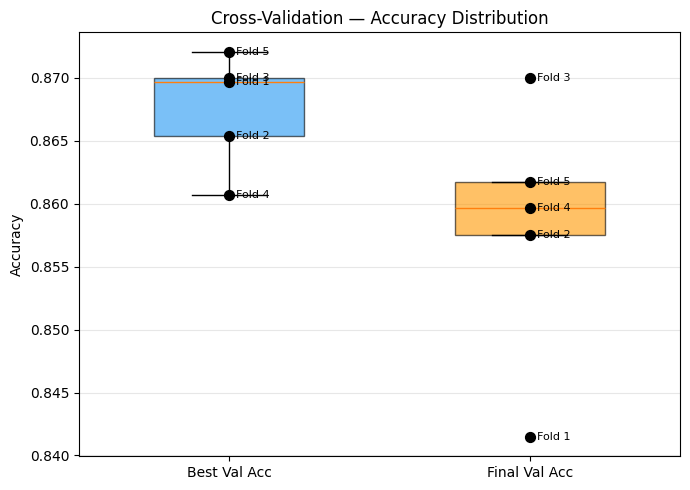

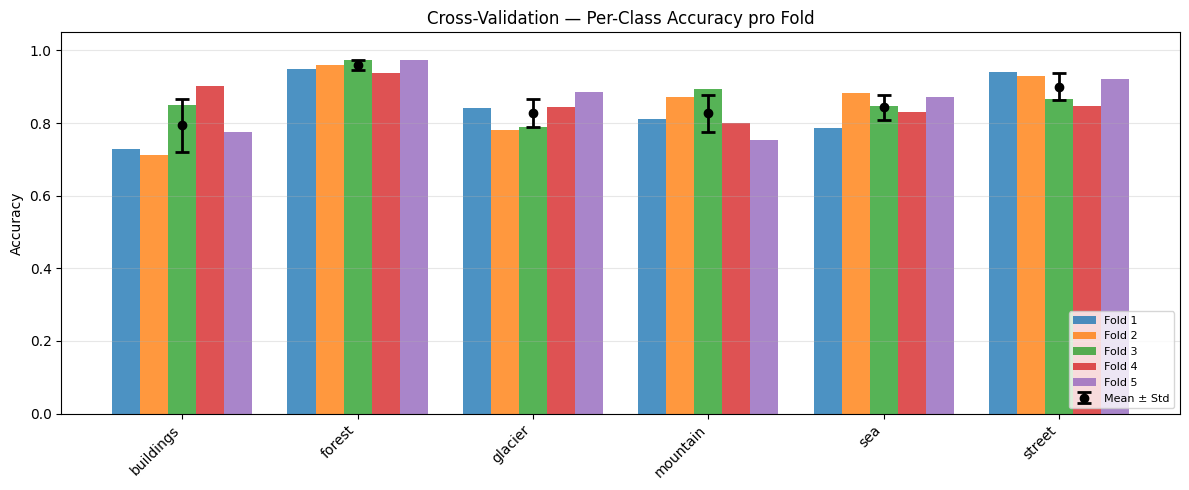

best_epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇██████
epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██
train_acc,▁▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇███████████████████████
train_loss,█▇▆▅▅▄▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▃▁▅▅▅▇▆▇▆▇▇▇▇▇█▇▇██▆█▆▇▇██▇▇▇▇██▇▇████▇█
val_acc_best,▁▃▅▅▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
val_loss,█▇▅▃▃▃▅▃▂▂▂▂▂▂▁▁▁▃▁▂▂▁▁▂▃▁▁▁▂▂▁▁▁▂▁▂▁▁▁▂
best_epoch,83
epoch,99
train_acc,0.92528
train_loss,0.20976


cv/ci95_best_high,▁
cv/ci95_best_low,▁
cv/ci95_final_high,▁
cv/ci95_final_low,▁
cv/mean_best_acc,▁
cv/mean_final_acc,▁
cv/sd_best_acc,▁
cv/sd_final_acc,▁
cv/se_best_acc,▁
cv/se_final_acc,▁
cv/ci95_best_high,0.87316


In [ ]:
# Cross-Validation Ergebnisse zusammenfassen

best_accs = np.array([r["best_val_acc"] for r in fold_results])
final_accs = np.array([r["final_val_acc"] for r in fold_results])

K = len(best_accs)
t_crit = scipy_stats.t.ppf(0.975, df=K - 1)  # zweiseitig, 95%


def summarize(accs):
    mean = accs.mean()
    sd = accs.std(ddof=1)  # Stichproben-SD
    se = sd / np.sqrt(len(accs))  # Standardfehler des Mittelwerts
    ci_half = t_crit * se
    return mean, sd, se, ci_half


mean_best, sd_best, se_best, ci_best = summarize(best_accs)
mean_final, sd_final, se_final, ci_final = summarize(final_accs)

print("Cross-Validation Ergebnisse:")
print(f"{'Fold':>6} | {'Best Val Acc':>12} | {'Final Val Acc':>13}")
print("-" * 40)
for r in fold_results:
    print(f"{r['fold']:>6} | {r['best_val_acc']:>12.4f} | {r['final_val_acc']:>13.4f}")
print("-" * 40)
print(f"{'Mean':>6} | {mean_best:>12.4f} | {mean_final:>13.4f}")
print(
    f"{'SD':>6} | {sd_best:>12.4f} | {sd_final:>13.4f}   (Streuung über Folds, ddof=1)"
)
print(
    f"{'SE':>6} | {se_best:>12.4f} | {se_final:>13.4f}   (= SD/sqrt(K), Unsicherheit des Mittels)"
)

print("\n--- Best Val Acc ---")
print(f"Mittelwert            : {mean_best:.4f}")
print(f"Standardabweichung SD : {sd_best:.4f}   (Streuung der Fold-Accuracies)")
print(f"Standardfehler     SE : {se_best:.4f}   (statistischer Fehler des Mittelwerts)")
print(
    f"95%-Konfidenzintervall: [{mean_best - ci_best:.4f}, {mean_best + ci_best:.4f}]   (t_{{0.975,{K-1}}} = {t_crit:.3f})"
)
print(f"\n>>> Statistischer Fehler (Mean +/- SE): {mean_best:.4f} +/- {se_best:.4f}")
print(f">>> Zur Information         (Mean +/- SD): {mean_best:.4f} +/- {sd_best:.4f}")

print("\n--- Final Val Acc ---")
print(f"Mittelwert            : {mean_final:.4f}")
print(f"Standardabweichung SD : {sd_final:.4f}")
print(f"Standardfehler     SE : {se_final:.4f}")
print(
    f"95%-Konfidenzintervall: [{mean_final - ci_final:.4f}, {mean_final + ci_final:.4f}]"
)

print(f"\nHyperparameter: lr={best_lr}, batch_size={best_bs}")

# Box-Plot der CV-Ergebnisse
fig_box = plot_cv_boxplot(
    fold_results, title="Cross-Validation — Accuracy Distribution"
)

# Per-Class Accuracy pro Fold
fig_per_class = plot_cv_per_class_accuracy(
    fold_predictions,
    CLASS_NAMES,
    title="Cross-Validation — Per-Class Accuracy pro Fold",
)

# CV-Zusammenfassung an W&B loggen
run = wandb.init(
    project="del-mini-challenge",
    name="cv-summary",
    config={
        "experiment": "cross-validation-summary",
        "k_folds": K_FOLDS,
        "lr": best_lr,
        "batch_size": best_bs,
    },
    reinit=True,
)
wandb.log(
    {
        "cv/boxplot": wandb.Image(fig_box),
        "cv/per_class_accuracy": wandb.Image(fig_per_class),
        "cv/mean_best_acc": mean_best,
        "cv/sd_best_acc": sd_best,
        "cv/se_best_acc": se_best,
        "cv/ci95_best_low": mean_best - ci_best,
        "cv/ci95_best_high": mean_best + ci_best,
        "cv/mean_final_acc": mean_final,
        "cv/sd_final_acc": sd_final,
        "cv/se_final_acc": se_final,
        "cv/ci95_final_low": mean_final - ci_final,
        "cv/ci95_final_high": mean_final + ci_final,
    }
)
for fig in [fig_box, fig_per_class]:
    plt.close(fig)
wandb.finish()

<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Cross-validation-Report--VmlldzoxNjYwMTgzNg" style="border:none;height:1024px;width:100%">


# Phase 2: Hyperparameter Tuning TODO: texte überarbeiten (Nicht KI like)

In dieser Phase werden 11 Hypothesen aus sieben Themengruppen untersucht: Modellkomplexitaet (Tiefe, Breite), Conv Layer Settings (Kernel Size, Pooling), Regularisierung (Dropout, Data Augmentation, Weight Decay), BatchNorm, Gewichts-Initialisierung, Adam Optimizer und Transfer Learning.

## Methodik

**Fixe Phase 2 Baseline als Referenz.** Statt pro Hypothese zweimal zu trainieren, wird einmal ein `phase2-baseline` Run mit dem BaseCNN und den besten Hyperparametern aus Stage 1 (lr=0.05, bs=64) trainiert. Alle folgenden Hypothesen werden gegen diesen einen Run verglichen. Das spart Rechenzeit und die Vergleiche sind deterministisch unter identischen Bedingungen.

**50 Epochen pro Experiment.** Aus Stage 1 wissen wir, dass die Val Accuracy beim Basismodell bereits ab ca. Epoche 30 auf einem Plateau zwischen 83 und 86 Prozent liegt und danach hauptsaechlich der Generalization Gap weiter waechst. 50 Epochen reichen also aus, um Peak Accuracy, Konvergenzverhalten und Overfitting-Trend zu beobachten. Laengeres Training wuerde den Vergleich nicht informativer machen, sondern nur Ressourcen binden. Ausnahmen (z.B. Transfer Learning mit weniger Epochen) werden pro Hypothese begruendet.

**Data Augmentation.** Die Stage 1 Pipeline enthaelt bereits `RandomResizedCrop` und `RandomHorizontalFlip`. Die Phase 2 Baseline uebernimmt diese Pipeline unveraendert. H6 (Data Augmentation) untersucht entsprechend, wie stark die Performance einbricht, wenn Augmentation entfernt wird, bzw. was zusaetzliche Augmentations (ColorJitter, RandomRotation) bringen.

## Ablauf pro Hypothese

1. **Hypothese** mit theoretischer Begruendung und Kursreferenz.
2. **Experiment** mit klar definierter Aenderung, alle anderen Hyperparameter konstant.
3. **Analyse und Reflexion** mit Beobachtung, Interpretation und Abgleich mit der Hypothese.

Am Schluss wird das beste Modell aus der Kombination der erfolgversprechenden Techniken gebaut.


## Phase 2 Baseline

Referenz-Run fuer alle Hypothesen. BaseCNN, lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum, keine Regularisierung. W&B Run Name: `phase2-baseline`.


In [27]:
# Phase 2 Baseline: wird einmal trainiert und als Referenz fuer alle Hypothesen verwendet.


run = wandb.init(
    project="del-mini-challenge",
    name="phase2-baseline",
    config={
        "architecture": "BaseCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "phase2-baseline",
    },
    reinit=True,
)

model_phase2_base = BaseCNN(NUM_CLASSES).to(device)
optimizer_phase2_base = optim.SGD(model_phase2_base.parameters(), lr=best_lr)

history_phase2_base = train_model(
    model_phase2_base,
    train_loader,
    val_loader,
    criterion,
    optimizer_phase2_base,
    device,
    epochs=PHASE2_EPOCHS,
)

results_phase2_base = evaluate_model(
    model_phase2_base,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_base = max(history_phase2_base["val_acc"])
print(f"\nPhase 2 Baseline Peak Val Accuracy: {peak_val_acc_base:.4f}")
wandb.finish()

Epoch   0 | Train Loss: 1.4719  Acc: 0.4006 | Val Loss: 1.1479  Acc: 0.5294 | Best 0.5294@0
Epoch   1 | Train Loss: 1.1412  Acc: 0.5399 | Val Loss: 1.0969  Acc: 0.5148 | Best 0.5294@0
Epoch   2 | Train Loss: 1.0323  Acc: 0.5860 | Val Loss: 0.9600  Acc: 0.6110 | Best 0.6110@2
Epoch   3 | Train Loss: 0.9539  Acc: 0.6266 | Val Loss: 0.8530  Acc: 0.6772 | Best 0.6772@3
Epoch   4 | Train Loss: 0.8875  Acc: 0.6605 | Val Loss: 0.8994  Acc: 0.6655 | Best 0.6772@3
Epoch   5 | Train Loss: 0.8226  Acc: 0.6865 | Val Loss: 0.9530  Acc: 0.6441 | Best 0.6772@3
Epoch   6 | Train Loss: 0.7887  Acc: 0.7071 | Val Loss: 0.6974  Acc: 0.7663 | Best 0.7663@6
Epoch   7 | Train Loss: 0.7403  Acc: 0.7241 | Val Loss: 0.6841  Acc: 0.7531 | Best 0.7663@6
Epoch   8 | Train Loss: 0.7124  Acc: 0.7356 | Val Loss: 0.7114  Acc: 0.7300 | Best 0.7663@6
Epoch   9 | Train Loss: 0.6957  Acc: 0.7416 | Val Loss: 0.7287  Acc: 0.7289 | Best 0.7663@6
Epoch  10 | Train Loss: 0.6746  Acc: 0.7550 | Val Loss: 0.6143  Acc: 0.7905 | Be

best_epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▇▇▇▇▇▇█████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
eval/accuracy,▁
train_acc,▁▃▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▆▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁
val_acc,▁▁▃▄▄▆▆▆▅▇▆▄▇▇▇▇▇▇▇▇▇█▇▇▆█▇▇███▇▇▇▆██▇██
val_acc_best,▁▁▃▄▄▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
val_loss,█▇▆▅▆▄▃▄▄▃▃▃▆▂▃▂▂▂▂▂▃▁▂▂▅▂▂▂▂▁▁▃▂▂▃▁▁▂▂▄
best_epoch,44
epoch,49
eval/accuracy,0.83648


## Hypothese 1: Modelltiefe

**Hypothesen:**

1. Ein tieferes CNN mit vier Conv Blöcken statt drei lernt eine reichere Feature Hierarchie und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Da mehr Parameter dazukommen und ohne BatchNorm trainiert wird, entsteht gleichzeitig ein grösserer Generalization Gap.
3. In den ersten Epochen ist mit einem instabileren Trainingsverlauf zu rechnen, weil Gradienten durch mehr Schichten propagieren müssen.

**Begründung:** CNNs lernen hierarchisch. Untere Schichten erkennen Kanten und Texturen, mittlere Schichten Formen, tiefere Schichten ganze Objektteile. Auf den Intel Image Scenes mit Gebäuden, Strassen, Wald, Gletschern, Bergen und Meer sollten gerade die objekthaften Klassen von einer tieferen Hierarchie profitieren. Das Risiko liegt im Optimierer. Bei SGD ohne Momentum und ohne BatchNorm können Gradienten in tieferen Schichten verschwinden oder instabil werden.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`, `05-02-MLP-vs-CNN.pdf`

### Experiment

`DeepCNN`: vier Conv-Bloecke (16 → 32 → 64 → 128 Filter, 3x3 Kernel, MaxPool(2) nach jedem Block). FC-Teil unveraendert. Training mit identischen Bedingungen wie Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen).


In [28]:
# TODO: Fazit so anpassen, dass nun best val score verwendet wird (sollte nun automatisch geloggt werden -> muss in wandb neu visualisiert werden)


class DeepCNN(nn.Module):
    """Vier Conv-Bloecke (16 -> 32 -> 64 -> 128) statt drei. FC-Teil unveraendert."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 16  # 4x MaxPool(2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
deep_params = sum(p.numel() for p in DeepCNN(NUM_CLASSES).parameters())
print(f"Baseline (3 Bloecke): {base_params:,} Parameter")
print(
    f"DeepCNN  (4 Bloecke): {deep_params:,} Parameter ({(deep_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h1-depth-4blocks",
    config={
        "architecture": "DeepCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "h1-depth",
        "hypothesis": "Mehr Tiefe -> hoehere Val Accuracy, groesserer Gap",
    },
    reinit=True,
)

model_h1 = DeepCNN(NUM_CLASSES).to(device)
optimizer_h1 = optim.SGD(model_h1.parameters(), lr=best_lr)

history_h1, best_state_h1 = train_model(
    model_h1,
    train_loader,
    val_loader,
    criterion,
    optimizer_h1,
    device,
    epochs=PHASE2_EPOCHS,
    return_best_state=True,
)
model_h1.load_state_dict(best_state_h1)

results_h1 = evaluate_model(
    model_h1,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h1 = max(history_h1["val_acc"])
print(f"\nH1 DeepCNN Peak Val Accuracy: {peak_val_acc_h1:.4f}")
print(f"Baseline Peak Val Accuracy:   {peak_val_acc_base:.4f}")
print(
    f"Differenz:                    {(peak_val_acc_h1 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)
wandb.finish()

Baseline (3 Bloecke): 548,774 Parameter
DeepCNN  (4 Bloecke): 360,486 Parameter (-34.3%)


Epoch   0 | Train Loss: 1.5396  Acc: 0.3781 | Val Loss: 1.1592  Acc: 0.5554 | Best 0.5554@0
Epoch   1 | Train Loss: 1.1931  Acc: 0.5227 | Val Loss: 1.2061  Acc: 0.5208 | Best 0.5554@0
Epoch   2 | Train Loss: 1.0665  Acc: 0.5710 | Val Loss: 0.9961  Acc: 0.5892 | Best 0.5892@2
Epoch   3 | Train Loss: 1.0014  Acc: 0.6070 | Val Loss: 1.0254  Acc: 0.5625 | Best 0.5892@2
Epoch   4 | Train Loss: 0.9474  Acc: 0.6278 | Val Loss: 0.8531  Acc: 0.6808 | Best 0.6808@4
Epoch   5 | Train Loss: 0.9029  Acc: 0.6513 | Val Loss: 0.8197  Acc: 0.6744 | Best 0.6808@4
Epoch   6 | Train Loss: 0.8443  Acc: 0.6780 | Val Loss: 0.8312  Acc: 0.6965 | Best 0.6965@6
Epoch   7 | Train Loss: 0.8280  Acc: 0.6874 | Val Loss: 0.7443  Acc: 0.7232 | Best 0.7232@7
Epoch   8 | Train Loss: 0.7786  Acc: 0.7124 | Val Loss: 0.6822  Acc: 0.7563 | Best 0.7563@8
Epoch   9 | Train Loss: 0.7516  Acc: 0.7199 | Val Loss: 0.7759  Acc: 0.7157 | Best 0.7563@8
Epoch  10 | Train Loss: 0.7292  Acc: 0.7321 | Val Loss: 0.6440  Acc: 0.7777 | Be

best_epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇████████
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▂▂▄▅▅▆▅▆▆▆▇▆▆▇▇▇▇▇▇█▇▇▇█▆█▇█▆█████▇██▇
val_acc_best,▁▁▂▂▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇████████████████████
val_loss,█▆▆▅▅▄▃▄▃▅▃▂▃▃▂▂▂▂▂▂▁▂▂▃▂▁▃▁▁▁▃▁▁▁▁▁▂▁▁▂
best_epoch,42
epoch,49
eval/accuracy,0.85786


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H1-Modelltiefe--VmlldzoxNjYxNDYzMQ" style="border:none;height:1024px;width:100%">

## Hypothese 2: Modellbreite

**Hypothesen:**

1. Ein breiteres CNN mit doppelt so vielen Filtern pro Block lernt vielfältigere Muster pro Schicht und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Da die Parameterzahl stark ansteigt und weiterhin ohne BatchNorm und ohne Regularisierung trainiert wird, ist mit einem grösseren Generalization Gap zu rechnen.
3. Da die Anzahl Schichten gleich bleibt und die Filter voneinander unabhängig lernen, ist das Training nicht merklich instabiler als bei der Baseline.

**Begründung:** Die Anzahl Filter pro Conv Schicht bestimmt, wie viele unterschiedliche Merkmale auf derselben Abstraktionsebene parallel erkannt werden können. Mit doppelt so vielen Filtern kann das Netz mehr Kantenorientierungen, Texturen und Farbmuster gleichzeitig abdecken. Bei den sechs Szenenklassen helfen reichere Texturen vor allem bei ähnlich aussehenden Naturklassen wie `glacier`, `mountain` und `sea`, die von der Baseline oft verwechselt werden. Das Risiko liegt in der deutlich grösseren Parameterzahl, die ohne Regularisierung schneller auswendig lernen kann.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`

### Experiment

`WideCNN`: drei Conv Blöcke wie in der Baseline, aber mit doppelter Filteranzahl (32 → 64 → 128 statt 16 → 32 → 64). Kernel Size 3x3, MaxPool(2) nach jedem Block, FC Teil unverändert. Training unter denselben Bedingungen wie die Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum).

In [29]:
class WideCNN(nn.Module):
    """Drei Conv Blöcke wie BaseCNN, aber mit doppelter Filteranzahl (32 -> 64 -> 128)."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 8  # 3x MaxPool(2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
wide_params = sum(p.numel() for p in WideCNN(NUM_CLASSES).parameters())
print(f"Baseline (Filter 16/32/64):  {base_params:,} Parameter")
print(
    f"WideCNN  (Filter 32/64/128): {wide_params:,} Parameter ({(wide_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h2-width-2x",
    config={
        "architecture": "WideCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "h2-width",
        "hypothesis": "Mehr Filter pro Block -> hoehere Val Accuracy, groesserer Gap",
    },
    reinit=True,
)

model_h2 = WideCNN(NUM_CLASSES).to(device)
optimizer_h2 = optim.SGD(model_h2.parameters(), lr=best_lr)

history_h2, best_state_h2 = train_model(
    model_h2,
    train_loader,
    val_loader,
    criterion,
    optimizer_h2,
    device,
    epochs=PHASE2_EPOCHS,
    return_best_state=True,
)
model_h2.load_state_dict(best_state_h2)

results_h2 = evaluate_model(
    model_h2,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h2 = max(history_h2["val_acc"])
print(f"\nH2 WideCNN Peak Val Accuracy: {peak_val_acc_h2:.4f}")
print(f"Baseline Peak Val Accuracy:   {peak_val_acc_base:.4f}")
print(
    f"Differenz:                    {(peak_val_acc_h2 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)

run.finish()

Baseline (Filter 16/32/64):  548,774 Parameter
WideCNN  (Filter 32/64/128): 1,142,726 Parameter (+108.2%)


Epoch   0 | Train Loss: 1.3558  Acc: 0.4662 | Val Loss: 1.2562  Acc: 0.5159 | Best 0.5159@0
Epoch   1 | Train Loss: 1.0665  Acc: 0.5801 | Val Loss: 0.9267  Acc: 0.6459 | Best 0.6459@1
Epoch   2 | Train Loss: 0.9468  Acc: 0.6436 | Val Loss: 1.3811  Acc: 0.5344 | Best 0.6459@1
Epoch   3 | Train Loss: 0.8902  Acc: 0.6639 | Val Loss: 0.7499  Acc: 0.7207 | Best 0.7207@3
Epoch   4 | Train Loss: 0.8240  Acc: 0.6923 | Val Loss: 0.7376  Acc: 0.7353 | Best 0.7353@4
Epoch   5 | Train Loss: 0.7807  Acc: 0.7113 | Val Loss: 0.7555  Acc: 0.7225 | Best 0.7353@4
Epoch   6 | Train Loss: 0.7365  Acc: 0.7281 | Val Loss: 0.7076  Acc: 0.7496 | Best 0.7496@6
Epoch   7 | Train Loss: 0.6936  Acc: 0.7451 | Val Loss: 0.6717  Acc: 0.7620 | Best 0.7620@7
Epoch   8 | Train Loss: 0.6681  Acc: 0.7544 | Val Loss: 0.7082  Acc: 0.7403 | Best 0.7620@7
Epoch   9 | Train Loss: 0.6326  Acc: 0.7700 | Val Loss: 0.6500  Acc: 0.7766 | Best 0.7766@9
Epoch  10 | Train Loss: 0.6184  Acc: 0.7747 | Val Loss: 1.0732  Acc: 0.6106 | Be

best_epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▆▅▅▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▁▅▅▆▆▆▆▃▆▇▇▇▇▅▇▇█▆▇▇█▇▆▇█▆██▇█▇██▇█▇█▇
val_acc_best,▁▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇████████████████████
val_loss,▇▅█▃▃▃▃▃▃▆▂▂▂▂▃▂▂▂▂▁▂▁▂▁▁▃▂▁▃▁▁▂▁▂▁▂▁▂▁▂
best_epoch,42
epoch,49
eval/accuracy,0.8632


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H2-Modellbreite--VmlldzoxNjYxNTY4Nw" style="border:none;height:1024px;width:100%">

## Hypothese 3: Kernel Size

**Hypothesen:**

1. Ein grösserer Conv Kernel von 5x5 erfasst pro Schicht mehr räumlichen Kontext als ein 3x3 Kernel und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Da mit 5x5 deutlich mehr Gewichte pro Conv Schicht dazukommen, wächst die Parameterzahl moderat, und der Generalization Gap kann leicht zunehmen.
3. Die Trainingsstabilität bleibt vergleichbar mit der Baseline, weil die Netztiefe identisch bleibt und nur die Filtergrösse verändert wird.

**Begründung:** Die Kernelgrösse bestimmt, wie viele benachbarte Pixel pro Filter direkt zusammengefasst werden. Mit 5x5 sieht jeder Filter in einem einzigen Schritt eine grössere Umgebung, was das Receptive Field pro Schicht vergrössert. Bei nur drei Conv Blöcken kann das ein Vorteil sein, weil die Baseline mit 3x3 Kernels erst nach mehreren Schichten genug räumlichen Kontext aggregiert. Für Szenenbilder mit grossräumigen Strukturen wie Bergketten, Wolken oder Waldflächen ist mehr Kontext pro Schicht plausibel hilfreich. Der Nachteil liegt in der Parameterzahl, da ein 5x5 Kernel 25 Gewichte pro Filter benötigt statt 9 bei 3x3.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`

### Experiment

`LargeKernelCNN`: drei Conv Blöcke wie in der Baseline und gleiche Filteranzahl (16 → 32 → 64), aber mit 5x5 Kernel statt 3x3. Padding wird auf 2 erhöht, damit die Feature Map Grösse pro Block gleich bleibt. FC Teil unverändert. Training unter denselben Bedingungen wie die Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum).

In [30]:
class LargeKernelCNN(nn.Module):
    """Drei Conv Blöcke wie BaseCNN, aber mit 5x5 Kernel statt 3x3 (padding=2)."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 8  # 3x MaxPool(2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
lk_params = sum(p.numel() for p in LargeKernelCNN(NUM_CLASSES).parameters())
print(f"Baseline (3x3 Kernel):       {base_params:,} Parameter")
print(
    f"LargeKernelCNN (5x5 Kernel): {lk_params:,} Parameter ({(lk_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h3-kernel-5x5",
    config={
        "architecture": "LargeKernelCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "h3-kernel-size",
        "hypothesis": "5x5 Kernel -> mehr Kontext pro Schicht -> hoehere Val Accuracy",
    },
    reinit=True,
)

model_h3 = LargeKernelCNN(NUM_CLASSES).to(device)
optimizer_h3 = optim.SGD(model_h3.parameters(), lr=best_lr)

history_h3, best_state_h3 = train_model(
    model_h3,
    train_loader,
    val_loader,
    criterion,
    optimizer_h3,
    device,
    epochs=PHASE2_EPOCHS,
    return_best_state=True,
)
model_h3.load_state_dict(best_state_h3)

results_h3 = evaluate_model(
    model_h3,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h3 = max(history_h3["val_acc"])
print(f"\nH3 LargeKernelCNN Peak Val Accuracy: {peak_val_acc_h3:.4f}")
print(f"Baseline Peak Val Accuracy:          {peak_val_acc_base:.4f}")
print(
    f"Differenz:                           {(peak_val_acc_h3 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)

run.finish()

Baseline (3x3 Kernel):       548,774 Parameter
LargeKernelCNN (5x5 Kernel): 590,502 Parameter (+7.6%)


Epoch   0 | Train Loss: 1.3997  Acc: 0.4396 | Val Loss: 1.6264  Acc: 0.3598 | Best 0.3598@0
Epoch   1 | Train Loss: 1.1854  Acc: 0.5349 | Val Loss: 0.9971  Acc: 0.6010 | Best 0.6010@1
Epoch   2 | Train Loss: 1.0020  Acc: 0.6049 | Val Loss: 0.9228  Acc: 0.6163 | Best 0.6163@2
Epoch   3 | Train Loss: 0.9285  Acc: 0.6373 | Val Loss: 0.8885  Acc: 0.6747 | Best 0.6747@3
Epoch   4 | Train Loss: 0.8755  Acc: 0.6643 | Val Loss: 0.8090  Acc: 0.6901 | Best 0.6901@4
Epoch   5 | Train Loss: 0.8085  Acc: 0.6954 | Val Loss: 0.7482  Acc: 0.7121 | Best 0.7121@5
Epoch   6 | Train Loss: 0.7671  Acc: 0.7153 | Val Loss: 0.7829  Acc: 0.7257 | Best 0.7257@6
Epoch   7 | Train Loss: 0.7199  Acc: 0.7330 | Val Loss: 0.6446  Acc: 0.7748 | Best 0.7748@7
Epoch   8 | Train Loss: 0.7006  Acc: 0.7434 | Val Loss: 0.7955  Acc: 0.7221 | Best 0.7748@7
Epoch   9 | Train Loss: 0.6618  Acc: 0.7533 | Val Loss: 0.7457  Acc: 0.7531 | Best 0.7748@7
Epoch  10 | Train Loss: 0.6366  Acc: 0.7688 | Val Loss: 0.7243  Acc: 0.7296 | Be

best_epoch,▁▁▁▂▂▂▂▂▂▂▃▃▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇██████████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▂▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇██████████████
train_loss,█▇▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▆▆▇▆▆▆▇▇▇▇▇▇█▇▇▇▇▇▇██▇██▇█████▇█████
val_acc_best,▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇████████████████████████
val_loss,█▄▄▄▃▃▂▃▃▃▃▂▂▂▂▂▁▂▂▂▂▂▂▁▁▂▁▁▂▁▂▁▁▁▁▂▂▁▂▁
best_epoch,35
epoch,49
eval/accuracy,0.84539


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H3-Kernal-Size--VmlldzoxNjYyNDkzNg" style="border:none;height:1024px;width:100%">

## Hypothese 4: Pooling Strategie

**Hypothesen:**

1. Ein Netz mit AvgPool statt MaxPool erreicht eine tiefere Val Accuracy als die Baseline, weil MaxPool die markantesten lokalen Merkmale gezielt durchlässt, während AvgPool sie glättet.
2. Der Generalization Gap fällt bei AvgPool tendenziell kleiner aus, weil die Durchschnittsbildung eine weichere Repräsentation erzeugt und damit einen milden Regularisierungseffekt hat.
3. Die Trainingsstabilität bleibt vergleichbar mit der Baseline, weil sich weder die Netztiefe, die Breite noch die Parameterzahl ändern.

**Begründung:** MaxPool und AvgPool sind die beiden klassischen Downsampling Operationen in CNNs. MaxPool wählt pro Fenster die stärkste Aktivierung und hebt dadurch scharfe Merkmale wie Kanten und Ecken hervor. AvgPool bildet den Durchschnitt und erzeugt eine glattere, verrauschtere Zusammenfassung. Bei Szenenbildern mit ausgeprägten Strukturen wie Gebäudekanten, Strassenmarkierungen oder Berggraten sollte MaxPool im Vorteil sein. AvgPool könnte umgekehrt bei homogen texturierten Klassen wie Meer oder Wald eine rauschresistentere Repräsentation liefern. Da die Parameterzahl identisch bleibt, ist dies eine reine Ablation auf der Pooling Operation.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `05-02-MLP-vs-CNN.pdf`

### Experiment

`AvgPoolCNN`: identisch zur Baseline (drei Conv Blöcke, 16 → 32 → 64 Filter, 3x3 Kernel), aber mit `AvgPool2d(2)` statt `MaxPool2d(2)` nach jedem Block. FC Teil unverändert. Training unter denselben Bedingungen wie die Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum).

In [31]:
class AvgPoolCNN(nn.Module):
    """Baseline Architektur mit AvgPool2d statt MaxPool2d."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),
        )
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich (sollte identisch sein)
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
avg_params = sum(p.numel() for p in AvgPoolCNN(NUM_CLASSES).parameters())
print(f"Baseline (MaxPool): {base_params:,} Parameter")
print(
    f"AvgPoolCNN:         {avg_params:,} Parameter ({(avg_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h4-avgpool",
    config={
        "architecture": "AvgPoolCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "h4-pooling",
        "hypothesis": "AvgPool statt MaxPool -> tiefere Val Accuracy, kleinerer Gap",
    },
    reinit=True,
)

model_h4 = AvgPoolCNN(NUM_CLASSES).to(device)
optimizer_h4 = optim.SGD(model_h4.parameters(), lr=best_lr)

history_h4, best_state_h4 = train_model(
    model_h4,
    train_loader,
    val_loader,
    criterion,
    optimizer_h4,
    device,
    epochs=PHASE2_EPOCHS,
    return_best_state=True,
)
model_h4.load_state_dict(best_state_h4)

results_h4 = evaluate_model(
    model_h4,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h4 = max(history_h4["val_acc"])
print(f"\nH4 AvgPoolCNN Peak Val Accuracy: {peak_val_acc_h4:.4f}")
print(f"Baseline Peak Val Accuracy:      {peak_val_acc_base:.4f}")
print(
    f"Differenz:                       {(peak_val_acc_h4 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)

run.finish()

Baseline (MaxPool): 548,774 Parameter
AvgPoolCNN:         548,774 Parameter (+0.0%)


Epoch   0 | Train Loss: 1.4714  Acc: 0.4123 | Val Loss: 1.2772  Acc: 0.4866 | Best 0.4866@0
Epoch   1 | Train Loss: 1.2298  Acc: 0.5172 | Val Loss: 1.2380  Acc: 0.4934 | Best 0.4934@1
Epoch   2 | Train Loss: 1.0890  Acc: 0.5737 | Val Loss: 1.0430  Acc: 0.6003 | Best 0.6003@2
Epoch   3 | Train Loss: 1.0133  Acc: 0.6035 | Val Loss: 1.1011  Acc: 0.5575 | Best 0.6003@2
Epoch   4 | Train Loss: 0.9610  Acc: 0.6334 | Val Loss: 1.0086  Acc: 0.6163 | Best 0.6163@4
Epoch   5 | Train Loss: 0.9176  Acc: 0.6472 | Val Loss: 0.9242  Acc: 0.6331 | Best 0.6331@5
Epoch   6 | Train Loss: 0.8919  Acc: 0.6610 | Val Loss: 0.8377  Acc: 0.6669 | Best 0.6669@6
Epoch   7 | Train Loss: 0.8536  Acc: 0.6725 | Val Loss: 0.8208  Acc: 0.6747 | Best 0.6747@7
Epoch   8 | Train Loss: 0.8349  Acc: 0.6831 | Val Loss: 0.8815  Acc: 0.6416 | Best 0.6747@7
Epoch   9 | Train Loss: 0.7954  Acc: 0.6982 | Val Loss: 0.8127  Acc: 0.7007 | Best 0.7007@9
Epoch  10 | Train Loss: 0.7714  Acc: 0.7072 | Val Loss: 0.8391  Acc: 0.6854 | Be

best_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▇▇▇▇▇▇█
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▆▆▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▃▃▄▄▅▅▆▅▆▆▇▇▆▇▆▇▇▆▇▁▇▇█▇▇▇▇▇▇██▇████████
val_acc_best,▁▁▃▃▄▅▅▅▅▅▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
val_loss,▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,49
epoch,49
eval/accuracy,0.83185


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H4-Avg-Pooling--VmlldzoxNjYyNjEwNw" style="border:none;height:1024px;width:100%">

## Hypothese 5: Dropout

**Hypothesen:**

1. Ein Netz mit Dropout im FC Teil reduziert Overfitting und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Der Generalization Gap fällt deutlich kleiner aus, weil Dropout während des Trainings zufällig Aktivierungen abschaltet und das Netz zwingt, redundante Repräsentationen zu lernen.
3. Die Konvergenz verläuft etwas langsamer und verrauschter, weil pro Batch nur ein Teil der Neuronen aktiv ist und der Optimierer dadurch verrauschtere Gradientenschätzungen bekommt.

**Begründung:** Dropout ist die klassische Regularisierungstechnik in CNNs. Mit einer Wahrscheinlichkeit p wird jedes Neuron im FC Teil während des Trainings temporär auf Null gesetzt. Das zwingt das Netz, sich nicht auf einzelne starke Features zu verlassen, sondern verteilte und robuste Repräsentationen zu lernen. Bei der Inferenz sind alle Neuronen aktiv und die Ausgaben werden entsprechend skaliert. Da die Baseline ohne jegliche Regularisierung trainiert wird und in den bisherigen Runs ein moderater Generalization Gap mit Val Loss Spikes bis etwa 0.4 sichtbar ist, sollte Dropout genau hier ansetzen. Ein Standardwert von p=0.5 im FC Teil ist der Ausgangspunkt.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`

### Experiment

`DropoutCNN`: identisch zur Baseline (drei Conv Blöcke, 16 → 32 → 64 Filter, 3x3 Kernel, MaxPool(2)), aber mit einem zusätzlichen `nn.Dropout(p=0.5)` zwischen den beiden FC Schichten. Training unter denselben Bedingungen wie die Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum).

In [32]:
class DropoutCNN(nn.Module):
    """Baseline Architektur mit zusätzlichem Dropout (p=0.5) im FC Teil."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich (sollte identisch sein, Dropout hat keine Gewichte)
dropout_p = 0.5
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
drop_params = sum(
    p.numel() for p in DropoutCNN(NUM_CLASSES, dropout_p=dropout_p).parameters()
)
print(f"Baseline:       {base_params:,} Parameter")
print(
    f"DropoutCNN:     {drop_params:,} Parameter ({(drop_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h5-dropout-0.5",
    config={
        "architecture": "DropoutCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "dropout_p": dropout_p,
        "experiment": "h5-dropout",
        "hypothesis": "Dropout 0.5 im FC -> kleinerer Gap, hoehere Val Accuracy",
    },
    reinit=True,
)

model_h5 = DropoutCNN(NUM_CLASSES, dropout_p=dropout_p).to(device)
optimizer_h5 = optim.SGD(model_h5.parameters(), lr=best_lr)

history_h5, best_state_h5 = train_model(
    model_h5,
    train_loader,
    val_loader,
    criterion,
    optimizer_h5,
    device,
    epochs=PHASE2_EPOCHS,
    return_best_state=True,
)
model_h5.load_state_dict(best_state_h5)

results_h5 = evaluate_model(
    model_h5,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h5 = max(history_h5["val_acc"])
print(f"\nH5 DropoutCNN Peak Val Accuracy: {peak_val_acc_h5:.4f}")
print(f"Baseline Peak Val Accuracy:      {peak_val_acc_base:.4f}")
print(
    f"Differenz:                       {(peak_val_acc_h5 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)

run.finish()

Baseline:       548,774 Parameter
DropoutCNN:     548,774 Parameter (+0.0%)


Epoch   0 | Train Loss: 1.4070  Acc: 0.4470 | Val Loss: 1.0814  Acc: 0.5536 | Best 0.5536@0
Epoch   1 | Train Loss: 1.1296  Acc: 0.5473 | Val Loss: 1.2108  Acc: 0.5173 | Best 0.5536@0
Epoch   2 | Train Loss: 1.0476  Acc: 0.5943 | Val Loss: 0.9039  Acc: 0.6598 | Best 0.6598@2
Epoch   3 | Train Loss: 0.9807  Acc: 0.6232 | Val Loss: 0.9194  Acc: 0.6302 | Best 0.6598@2
Epoch   4 | Train Loss: 0.9161  Acc: 0.6572 | Val Loss: 0.8525  Acc: 0.6836 | Best 0.6836@4
Epoch   5 | Train Loss: 0.8584  Acc: 0.6781 | Val Loss: 1.0039  Acc: 0.6441 | Best 0.6836@4
Epoch   6 | Train Loss: 0.8339  Acc: 0.6952 | Val Loss: 0.8816  Acc: 0.6352 | Best 0.6836@4
Epoch   7 | Train Loss: 0.7946  Acc: 0.7059 | Val Loss: 0.9541  Acc: 0.6306 | Best 0.6836@4
Epoch   8 | Train Loss: 0.7683  Acc: 0.7183 | Val Loss: 0.6822  Acc: 0.7570 | Best 0.7570@8
Epoch   9 | Train Loss: 0.7454  Acc: 0.7266 | Val Loss: 0.6752  Acc: 0.7617 | Best 0.7617@9
Epoch  10 | Train Loss: 0.7268  Acc: 0.7397 | Val Loss: 0.6340  Acc: 0.7709 | Be

best_epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▆▆▆▆▆▆▆▇▇▇▇███████
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▆▅▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▄▃▄▃▃▆▆▇▇▇▆▆▇▅█▇▇█▇██▇█▇█▇▇███▇███████
val_acc_best,▁▁▃▃▄▄▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
val_loss,▇█▅▅▅▅▆▃▃▃▃▃▄▄▂▅▂▂▂▂▂▂▁▃▂▂▂▂▂▂▂▂▃▁▁▁▁▂▁▂
best_epoch,41
epoch,49
eval/accuracy,0.85928


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H5-Dropout--VmlldzoxNjYzOTE2OA" style="border:none;height:1024px;width:100%">

## Hypothese 6: Stärkere Data Augmentation

**Hypothesen:**

1. Eine stärkere Augmentation Pipeline (zusätzlich ColorJitter und RandomRotation zum bereits aktiven RandomResizedCrop und HorizontalFlip) reduziert Overfitting weiter und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Der Generalization Gap fällt kleiner aus, weil das Netz pro Epoche mehr Variation sieht und sich schlechter auf spezifische Farbwerte oder Orientierungen einstellen kann.
3. Die Train Accuracy fällt tiefer aus und die Konvergenz verläuft langsamer, weil die schwierigeren Trainingsdaten mehr Epochen brauchen, bis sie gelernt sind.

**Begründung:** Die Phase 2 Baseline nutzt bereits eine moderate Augmentation (RandomResizedCrop und RandomHorizontalFlip). Die Ergebnisse aus H1 bis H5 zeigen konsistent einen moderaten Generalization Gap, der gegen Trainingsende wächst. Stärkere Augmentation ist eine naheliegende zweite Regularisierungsschraube neben Dropout. ColorJitter variiert Helligkeit, Kontrast und Sättigung, RandomRotation addiert leichte Rotationen bis 10 Grad. Beides ist für das Intel Image Datenset semantisch unbedenklich (Landschaften und Gebäude bleiben auch leicht rotiert oder mit anderem Weissabgleich als Klasse erkennbar).

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`

### Experiment

`BaseCNN` (identisch zur Phase 2 Baseline), aber mit einem erweiterten Augmentation Transform. Zusätzlich zu `RandomResizedCrop(64, scale=(0.4, 1.0))` und `RandomHorizontalFlip()` kommen `ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)` und `RandomRotation(10)` zum Einsatz. Der Val Loader bleibt unverändert (nur Resize und Normalize). Training unter denselben Bedingungen wie die Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum).

In [33]:
# H6: Stärkere Data Augmentation (ColorJitter + RandomRotation zusätzlich zur Baseline)
transform_train_strong = transforms.Compose(
    [
        transforms.RandomResizedCrop(64, scale=(0.4, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)

train_dataset_strong = IntelImageDataset(hf_train, transform=transform_train_strong)
train_loader_strong = DataLoader(train_dataset_strong, batch_size=best_bs, shuffle=True)

# Sanity Check: ein Batch laden
sample_images, sample_labels = next(iter(train_loader_strong))
print(f"Batch shape: {sample_images.shape}")
print(f"Pixel range: [{sample_images.min():.2f}, {sample_images.max():.2f}]")

run = wandb.init(
    project="del-mini-challenge",
    name="h6-strong-augmentation",
    config={
        "architecture": "BaseCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "augmentation": "RandomResizedCrop + HorizontalFlip + ColorJitter + RandomRotation",
        "experiment": "h6-strong-augmentation",
        "hypothesis": "Staerkere Augmentation -> kleinerer Gap, hoehere Val Accuracy",
    },
    reinit=True,
)

model_h6 = BaseCNN(NUM_CLASSES).to(device)
optimizer_h6 = optim.SGD(model_h6.parameters(), lr=best_lr)

history_h6, best_state_h6 = train_model(
    model_h6,
    train_loader_strong,
    val_loader,
    criterion,
    optimizer_h6,
    device,
    epochs=PHASE2_EPOCHS,
    return_best_state=True,
)
model_h6.load_state_dict(best_state_h6)

results_h6 = evaluate_model(
    model_h6,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h6 = max(history_h6["val_acc"])
print(f"\nH6 Strong Augmentation Peak Val Accuracy: {peak_val_acc_h6:.4f}")
print(f"Baseline Peak Val Accuracy:              {peak_val_acc_base:.4f}")
print(
    f"Differenz:                               {(peak_val_acc_h6 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)
wandb.finish()

Batch shape: torch.Size([64, 3, 64, 64])
Pixel range: [-1.71, 2.11]


Epoch   0 | Train Loss: 1.4345  Acc: 0.4150 | Val Loss: 1.1405  Acc: 0.5422 | Best 0.5422@0
Epoch   1 | Train Loss: 1.1290  Acc: 0.5517 | Val Loss: 1.0120  Acc: 0.6149 | Best 0.6149@1
Epoch   2 | Train Loss: 1.0363  Acc: 0.5932 | Val Loss: 1.1711  Acc: 0.5572 | Best 0.6149@1
Epoch   3 | Train Loss: 0.9713  Acc: 0.6309 | Val Loss: 0.8774  Acc: 0.6591 | Best 0.6591@3
Epoch   4 | Train Loss: 0.9077  Acc: 0.6525 | Val Loss: 0.8184  Acc: 0.6933 | Best 0.6933@4
Epoch   5 | Train Loss: 0.8603  Acc: 0.6760 | Val Loss: 0.9030  Acc: 0.6576 | Best 0.6933@4
Epoch   6 | Train Loss: 0.8251  Acc: 0.6928 | Val Loss: 0.7860  Acc: 0.7111 | Best 0.7111@6
Epoch   7 | Train Loss: 0.7885  Acc: 0.6999 | Val Loss: 0.7889  Acc: 0.7097 | Best 0.7111@6
Epoch   8 | Train Loss: 0.7739  Acc: 0.7075 | Val Loss: 0.6866  Acc: 0.7520 | Best 0.7520@8
Epoch   9 | Train Loss: 0.7401  Acc: 0.7226 | Val Loss: 0.6700  Acc: 0.7585 | Best 0.7585@9
Epoch  10 | Train Loss: 0.7303  Acc: 0.7249 | Val Loss: 0.8922  Acc: 0.6665 | Be

best_epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▇▇▇▇▇▇█████████
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▁▄▄▆▆▄▆▆▆▆▇▇▇▇▇▇▅█▇▇▃▇▇▇▇█▆█▇█▇█▇█████
val_acc_best,▁▃▃▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████████████████████
val_loss,█▆█▅▅▄▄▃▃▃▄▃▃▂▂▃▂▂▂▄▂▂▂▇▂▁▂▂▁▃▁▁▁▃▁▁▁▁▁▁
best_epoch,39
epoch,49
eval/accuracy,0.85429


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H6-Strong-Augmentation--VmlldzoxNjY0MTMxMg" style="border:none;height:1024px;width:100%">

## Hypothese 7: Weight Decay

**Hypothesen:**

1. Ein SGD Training mit Weight Decay (L2 Regularisierung auf allen Gewichten) reduziert Overfitting und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Der Generalization Gap fällt kleiner aus, weil der Strafterm grosse Gewichtsnormen unterdrückt und das Netz zu einfacheren Funktionen zwingt.
3. Train Loss endet über dem Baseline Wert, weil der zusätzliche Strafterm gegen eine reine Anpassung an die Trainingsdaten wirkt.

**Begründung:** Weight Decay ist neben Dropout und Data Augmentation die dritte klassische Regularisierungstechnik. In PyTorch wird sie direkt im Optimizer über den `weight_decay` Parameter aktiviert. Bei jedem Schritt wird zusätzlich zum Gradienten ein Term `weight_decay * w` vom Gewicht abgezogen, was einem L2 Penalty auf die Parameter entspricht. Da die Baseline keine Regularisierung nutzt und einen moderaten Generalization Gap zeigt, sollte Weight Decay hier einen ähnlichen Effekt haben wie Dropout, aber auf allen Schichten statt nur im FC Teil. Als Wert wird `weight_decay=1e-4` gewählt, ein konservativer Standardwert für CNNs.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`

### Experiment

`BaseCNN` (identisch zur Phase 2 Baseline), aber der Optimizer wird mit `weight_decay=1e-4` konfiguriert. Alle übrigen Bedingungen bleiben gleich (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum, identischer Train Loader mit der Baseline Augmentation).

In [34]:
# H7: Weight Decay (L2 Regularisierung) im SGD Optimizer
weight_decays = [1e-5, 1e-4, 5e-4, 1e-3]
history_h7_runs = {}
results_h7_runs = {}

for wd in weight_decays:
    run = wandb.init(
        project="del-mini-challenge",
        name=f"h7-weight-decay-{wd:.0e}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "momentum": 0.0,
            "weight_decay": wd,
            "batch_size": best_bs,
            "epochs": PHASE2_EPOCHS,
            "experiment": "h7-weight-decay",
            "hypothesis": "Weight Decay -> kleinerer Gap, hoehere Val Accuracy",
        },
        reinit=True,
    )

    model_h7 = BaseCNN(NUM_CLASSES).to(device)
    optimizer_h7 = optim.SGD(model_h7.parameters(), lr=best_lr, weight_decay=wd)

    history_h7, best_state_h7 = train_model(
        model_h7,
        train_loader,
        val_loader,
        criterion,
        optimizer_h7,
        device,
        epochs=PHASE2_EPOCHS,
        return_best_state=True,
    )
    model_h7.load_state_dict(best_state_h7)

    results_h7 = evaluate_model(
        model_h7,
        val_loader,
        CLASS_NAMES,
        device,
        channel_mean,
        channel_std,
    )

    history_h7_runs[wd] = history_h7
    results_h7_runs[wd] = results_h7

    peak_val_acc_h7 = max(history_h7["val_acc"])
    print(
        f"\nweight_decay={wd:.0e} | Peak Val Acc: {peak_val_acc_h7:.4f} | Baseline: {peak_val_acc_base:.4f} | Diff: {(peak_val_acc_h7 - peak_val_acc_base)*100:+.2f} pp"
    )
    wandb.finish()

print("\n--- Zusammenfassung H7 Weight Decay ---")
for wd in weight_decays:
    peak = max(history_h7_runs[wd]["val_acc"])
    last = history_h7_runs[wd]["val_acc"][-1]
    print(
        f"wd={wd:.0e} | Peak {peak:.4f} | Last {last:.4f} | Diff Peak {(peak - peak_val_acc_base)*100:+.2f} pp"
    )

Epoch   0 | Train Loss: 1.4372  Acc: 0.4239 | Val Loss: 1.1879  Acc: 0.5280 | Best 0.5280@0
Epoch   1 | Train Loss: 1.1201  Acc: 0.5549 | Val Loss: 1.1470  Acc: 0.5290 | Best 0.5290@1
Epoch   2 | Train Loss: 1.0237  Acc: 0.6011 | Val Loss: 0.9918  Acc: 0.5775 | Best 0.5775@2
Epoch   3 | Train Loss: 0.9439  Acc: 0.6378 | Val Loss: 0.8904  Acc: 0.6698 | Best 0.6698@3
Epoch   4 | Train Loss: 0.8647  Acc: 0.6757 | Val Loss: 0.8539  Acc: 0.6851 | Best 0.6851@4
Epoch   5 | Train Loss: 0.8167  Acc: 0.6911 | Val Loss: 0.7395  Acc: 0.7239 | Best 0.7239@5
Epoch   6 | Train Loss: 0.7761  Acc: 0.7062 | Val Loss: 0.9072  Acc: 0.6562 | Best 0.7239@5
Epoch   7 | Train Loss: 0.7433  Acc: 0.7249 | Val Loss: 0.6468  Acc: 0.7777 | Best 0.7777@7
Epoch   8 | Train Loss: 0.7186  Acc: 0.7342 | Val Loss: 0.8264  Acc: 0.7079 | Best 0.7777@7
Epoch   9 | Train Loss: 0.6882  Acc: 0.7478 | Val Loss: 0.7796  Acc: 0.7186 | Best 0.7777@7
Epoch  10 | Train Loss: 0.6621  Acc: 0.7539 | Val Loss: 0.6385  Acc: 0.7667 | Be

best_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆███
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▄▄▆▅▅▆▆▆▆▇▇▇▆▇▄▇▆▇▄▇█▅▇▇▇█▇██▆▆▇████▇
val_acc_best,▁▁▄▄▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████
val_loss,██▆▅▅▅▃▅▄▃▃▂▃▂▂▂▂▆▂▁▃█▂▁▅▂▂▁▁▂▁▁▃▃▁▁▁▁▁▁
best_epoch,46
epoch,49
eval/accuracy,0.86213


Epoch   0 | Train Loss: 1.4244  Acc: 0.4298 | Val Loss: 1.1420  Acc: 0.5522 | Best 0.5522@0
Epoch   1 | Train Loss: 1.1269  Acc: 0.5527 | Val Loss: 0.9625  Acc: 0.6063 | Best 0.6063@1
Epoch   2 | Train Loss: 1.0092  Acc: 0.6050 | Val Loss: 0.9433  Acc: 0.6316 | Best 0.6316@2
Epoch   3 | Train Loss: 0.9370  Acc: 0.6322 | Val Loss: 0.9308  Acc: 0.6452 | Best 0.6452@3
Epoch   4 | Train Loss: 0.8703  Acc: 0.6705 | Val Loss: 0.8927  Acc: 0.6206 | Best 0.6452@3
Epoch   5 | Train Loss: 0.8201  Acc: 0.6850 | Val Loss: 0.8184  Acc: 0.6765 | Best 0.6765@5
Epoch   6 | Train Loss: 0.7826  Acc: 0.7106 | Val Loss: 0.7599  Acc: 0.7260 | Best 0.7260@6
Epoch   7 | Train Loss: 0.7478  Acc: 0.7229 | Val Loss: 0.7210  Acc: 0.7364 | Best 0.7364@7
Epoch   8 | Train Loss: 0.7155  Acc: 0.7380 | Val Loss: 1.1470  Acc: 0.5885 | Best 0.7364@7
Epoch   9 | Train Loss: 0.6886  Acc: 0.7461 | Val Loss: 0.6676  Acc: 0.7627 | Best 0.7627@9
Epoch  10 | Train Loss: 0.6648  Acc: 0.7536 | Val Loss: 0.7158  Acc: 0.7456 | Be

best_epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▇▇▇▇███
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▃▅▅▂▆▅▆▆▆▂▇▇▆▅▇▇▇▇██▇█▇██▇█▇██▇█▆█▇█
val_acc_best,▁▂▃▃▃▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████████
val_loss,▇▆▅▅▅▄▄▇▃▂▃▂▃█▂▂▃▃▂▂▂▂▂▁▁▄▁▂▁▁▁▁▂▁▁▂▃▁▁▁
best_epoch,46
epoch,49
eval/accuracy,0.85928


Epoch   0 | Train Loss: 1.4052  Acc: 0.4434 | Val Loss: 1.6075  Acc: 0.4150 | Best 0.4150@0
Epoch   1 | Train Loss: 1.1381  Acc: 0.5508 | Val Loss: 1.0437  Acc: 0.5675 | Best 0.5675@1
Epoch   2 | Train Loss: 1.0357  Acc: 0.5915 | Val Loss: 0.9139  Acc: 0.6516 | Best 0.6516@2
Epoch   3 | Train Loss: 0.9548  Acc: 0.6288 | Val Loss: 1.8654  Acc: 0.3769 | Best 0.6516@2
Epoch   4 | Train Loss: 0.9627  Acc: 0.6334 | Val Loss: 0.9405  Acc: 0.6519 | Best 0.6519@4
Epoch   5 | Train Loss: 0.8368  Acc: 0.6825 | Val Loss: 0.8688  Acc: 0.6737 | Best 0.6737@5
Epoch   6 | Train Loss: 0.8034  Acc: 0.6991 | Val Loss: 0.7719  Acc: 0.7093 | Best 0.7093@6
Epoch   7 | Train Loss: 0.7655  Acc: 0.7107 | Val Loss: 0.6883  Acc: 0.7624 | Best 0.7624@7
Epoch   8 | Train Loss: 0.7312  Acc: 0.7277 | Val Loss: 0.7534  Acc: 0.7104 | Best 0.7624@7
Epoch   9 | Train Loss: 0.6943  Acc: 0.7461 | Val Loss: 0.7634  Acc: 0.7178 | Best 0.7624@7
Epoch  10 | Train Loss: 0.6760  Acc: 0.7451 | Val Loss: 0.8028  Acc: 0.7178 | Be

best_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▆▆▆▆▆▆▆▆▆▆▆███
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▆▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▂▄▅▁▅▇▆▆▆▇▇▇▆▇▇█▇▇█▇▇▇▇▆███▇█▇▇███▇████▇
val_acc_best,▁▃▅▅▅▆▆▆▆▆▇▇▇▇▇▇████████████████████████
val_loss,█▅▄▄▄▂▃▃▂▂▂▃▂▂▂▃▂▁▂▂▂▂▄▁▁▁▂▁▂▃▁▁▁▂▁▁▁▁▂▂
best_epoch,48
epoch,49
eval/accuracy,0.85964


Epoch   0 | Train Loss: 1.3914  Acc: 0.4567 | Val Loss: 1.1882  Acc: 0.5169 | Best 0.5169@0
Epoch   1 | Train Loss: 1.1061  Acc: 0.5604 | Val Loss: 0.9437  Acc: 0.6313 | Best 0.6313@1
Epoch   2 | Train Loss: 1.0132  Acc: 0.5979 | Val Loss: 0.9818  Acc: 0.6331 | Best 0.6331@2
Epoch   3 | Train Loss: 0.9407  Acc: 0.6328 | Val Loss: 0.8668  Acc: 0.6705 | Best 0.6705@3
Epoch   4 | Train Loss: 0.8714  Acc: 0.6649 | Val Loss: 0.9051  Acc: 0.6405 | Best 0.6705@3
Epoch   5 | Train Loss: 0.8295  Acc: 0.6845 | Val Loss: 0.7653  Acc: 0.7157 | Best 0.7157@5
Epoch   6 | Train Loss: 0.7719  Acc: 0.7146 | Val Loss: 0.9052  Acc: 0.6534 | Best 0.7157@5
Epoch   7 | Train Loss: 0.7408  Acc: 0.7266 | Val Loss: 0.9020  Acc: 0.6498 | Best 0.7157@5
Epoch   8 | Train Loss: 0.7066  Acc: 0.7359 | Val Loss: 0.6679  Acc: 0.7545 | Best 0.7545@8
Epoch   9 | Train Loss: 0.6899  Acc: 0.7474 | Val Loss: 0.6895  Acc: 0.7610 | Best 0.7610@9
Epoch  10 | Train Loss: 0.6573  Acc: 0.7553 | Val Loss: 0.6182  Acc: 0.7834 | Be

best_epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇██████████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▃▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train_loss,█▆▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▄▄▄▄▆▆▇▆▆▆▇▇▇▇▆▇██▇▇██▇▇██▆███▆▇█████
val_acc_best,▁▃▃▄▄▅▅▆▆▇▇▇▇▇▇▇▇▇██████████████████████
val_loss,█▆▆▅▅▅▅▃▃▃▃▃▂▃▄▃▂▂▁▂▃▁▁▁▂▁▁▃▁▁▁▃▁▃▂▂▁▁▁▁
best_epoch,37
epoch,49
eval/accuracy,0.85358



--- Zusammenfassung H7 Weight Decay ---
wd=1e-05 | Peak 0.8621 | Last 0.8372 | Diff Peak +1.32 pp
wd=1e-04 | Peak 0.8593 | Last 0.8497 | Diff Peak +1.03 pp
wd=5e-04 | Peak 0.8596 | Last 0.7952 | Diff Peak +1.07 pp
wd=1e-03 | Peak 0.8536 | Last 0.8525 | Diff Peak +0.46 pp


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H7-Weight-Decay--VmlldzoxNjY0MTYwMw" style="border:none;height:1024px;width:100%">

## Hypothese 8: BatchNorm

**Hypothesen:**

1. Das Einfügen von `BatchNorm2d` nach jedem Conv-Layer führt zu einer höheren Val Accuracy als die Baseline, weil BatchNorm die Aktivierungen pro Batch normalisiert und damit die Optimierung stabilisiert.
2. Die Trainingskurven verlaufen glatter und das Netz erreicht in weniger Epochen ein hohes Val Accuracy Niveau (schnellere Konvergenz).
3. Val Loss zeigt weniger extreme Spikes als bei der Baseline, weil BatchNorm interne Covariate Shifts dämpft.
4. Die beste Batch-Size verschiebt sich gegenüber der Phase 1 Studie (`best_bs=64`, ohne BN). BN ist direkt batch-size-abhängig: die pro-Batch berechneten Mean/Var sind bei kleinen Batches rauschig (instabile Normalisierung, unzuverlässige `running_mean/var`), bei grossen Batches hingegen sauberer, aber der implizite Regularisierungseffekt durch Batch-Rauschen fällt schwächer aus. Phase 1 `best_bs` wurde ohne BN gefunden und ist darum für `BatchNormCNN` nicht zwingend optimal.

**Begründung:** BatchNorm ist heute praktisch Standard in CNNs. Es normalisiert die Aktivierungen pro Mini-Batch auf Mittelwert 0 und Varianz 1 und lernt zusätzlich einen Skalierungs- und Offset-Parameter. Das erlaubt höhere effektive Lernraten, reduziert die Abhängigkeit von der Gewichtsinitialisierung und wirkt leicht regularisierend. Da die Baseline ohne BatchNorm trainiert wird und teils starke Val Loss Spikes zeigt, sollte BatchNorm hier eine spürbare Verbesserung bringen. Weil BN die Batch-Statistiken direkt nutzt, muss zusätzlich die Batch-Size für `BatchNormCNN` neu tuned werden, bevor ein fairer Vergleich mit der Baseline möglich ist.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`


### Experiment

`BatchNormCNN` basiert auf der `BaseCNN` Architektur, fügt aber nach jedem Conv-Layer (vor der ReLU) ein `nn.BatchNorm2d` ein. Reihenfolge pro Block: Conv → BatchNorm → ReLU → MaxPool. FC-Teil unverändert.

Zum Training wird die gleiche Batch-Size Grid wie in Phase 1 (`[16, 32, 64, 128]`) durchlaufen, diesmal aber auf `BatchNormCNN`. Jede Batch-Size ist ein eigener W&B Run, damit der BN-spezifische Sweet Spot sichtbar wird. Alle übrigen Bedingungen bleiben identisch zur Phase 2 Baseline (`lr=best_lr`, 50 Epochen, SGD ohne Momentum, kein Weight Decay, identischer Train Loader mit Baseline Augmentation). Am Ende wird `best_bs_bn` bestimmt und für den späteren Vergleich mit der Baseline bzw. fürs Kombimodell weiterverwendet.


In [35]:
# H8: BatchNorm nach jedem Conv-Layer + Batch-Size Re-Tuning fuer BN
class BatchNormCNN(nn.Module):
    """Baseline Architektur mit BatchNorm2d nach jedem Conv-Layer."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


batch_sizes_bn = [16, 32, 64, 128]
history_h8_runs = {}
results_h8_runs = {}

for bs in batch_sizes_bn:
    print(f"\n{'='*60}")
    print(f"H8 BatchNormCNN mit batch_size={bs}, lr={best_lr}")
    print(f"{'='*60}")

    bs_train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    bs_val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

    run = wandb.init(
        project="del-mini-challenge",
        name=f"h8-batchnorm-bs-{bs}",
        config={
            "architecture": "BatchNormCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "momentum": 0.0,
            "weight_decay": 0.0,
            "batch_size": bs,
            "epochs": PHASE2_EPOCHS,
            "experiment": "h8-batchnorm-bs-tuning",
            "hypothesis": "BN verschiebt Batch-Size Sweet Spot gegenueber Baseline",
        },
        reinit=True,
    )

    model_h8 = BatchNormCNN(NUM_CLASSES).to(device)
    optimizer_h8 = optim.SGD(model_h8.parameters(), lr=best_lr)

    history_h8, best_state_h8 = train_model(
        model_h8,
        bs_train_loader,
        bs_val_loader,
        criterion,
        optimizer_h8,
        device,
        epochs=PHASE2_EPOCHS,
        return_best_state=True,
    )
    model_h8.load_state_dict(best_state_h8)

    results_h8 = evaluate_model(
        model_h8,
        bs_val_loader,
        CLASS_NAMES,
        device,
        channel_mean,
        channel_std,
    )

    history_h8_runs[bs] = history_h8
    results_h8_runs[bs] = results_h8

    peak = max(history_h8["val_acc"])
    print(
        f"\nbs={bs} | Peak Val Acc: {peak:.4f} | Baseline: {peak_val_acc_base:.4f} | Diff: {(peak - peak_val_acc_base)*100:+.2f} pp"
    )
    wandb.finish()

print("\n--- Zusammenfassung H8 BatchNorm Batch-Size ---")
for bs in batch_sizes_bn:
    peak = max(history_h8_runs[bs]["val_acc"])
    last = history_h8_runs[bs]["val_acc"][-1]
    print(
        f"bs={bs:>3} | Peak {peak:.4f} | Last {last:.4f} | Diff Peak {(peak - peak_val_acc_base)*100:+.2f} pp"
    )

best_bs_bn = max(batch_sizes_bn, key=lambda bs: max(history_h8_runs[bs]["val_acc"]))
print(f"\nBeste Batch-Size mit BatchNorm: {best_bs_bn}")


H8 BatchNormCNN mit batch_size=16, lr=0.05


Epoch   0 | Train Loss: 1.1533  Acc: 0.5554 | Val Loss: 1.1308  Acc: 0.5358 | Best 0.5358@0
Epoch   1 | Train Loss: 0.9428  Acc: 0.6536 | Val Loss: 0.9613  Acc: 0.6466 | Best 0.6466@1
Epoch   2 | Train Loss: 0.8185  Acc: 0.6983 | Val Loss: 0.7021  Acc: 0.7595 | Best 0.7595@2
Epoch   3 | Train Loss: 0.7423  Acc: 0.7219 | Val Loss: 0.6762  Acc: 0.7535 | Best 0.7595@2
Epoch   4 | Train Loss: 0.6785  Acc: 0.7543 | Val Loss: 0.5720  Acc: 0.7959 | Best 0.7959@4
Epoch   5 | Train Loss: 0.6401  Acc: 0.7618 | Val Loss: 0.5218  Acc: 0.8158 | Best 0.8158@5
Epoch   6 | Train Loss: 0.6016  Acc: 0.7794 | Val Loss: 0.5204  Acc: 0.8158 | Best 0.8158@5
Epoch   7 | Train Loss: 0.5819  Acc: 0.7910 | Val Loss: 0.5479  Acc: 0.7966 | Best 0.8158@5
Epoch   8 | Train Loss: 0.5579  Acc: 0.7959 | Val Loss: 0.6383  Acc: 0.7727 | Best 0.8158@5
Epoch   9 | Train Loss: 0.5369  Acc: 0.8081 | Val Loss: 0.4831  Acc: 0.8318 | Best 0.8318@9
Epoch  10 | Train Loss: 0.5168  Acc: 0.8091 | Val Loss: 0.4935  Acc: 0.8329 | Be

best_epoch,▁▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▇▇▇▇▇██████████
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▆▅▆▇▆▆▇▇▇▇▇▇▇▇███▇█▇████▇▇█▅██████████
val_acc_best,▁▃▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████████
val_loss,█▆▄▄▃▂▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▂▁▅▁▁▁▁▁▁▁▁▁▁▁
best_epoch,37
epoch,49
eval/accuracy,0.87602



H8 BatchNormCNN mit batch_size=32, lr=0.05


Epoch   0 | Train Loss: 1.0855  Acc: 0.5749 | Val Loss: 0.9116  Acc: 0.6698 | Best 0.6698@0
Epoch   1 | Train Loss: 0.8479  Acc: 0.6874 | Val Loss: 0.6906  Acc: 0.7570 | Best 0.7570@1
Epoch   2 | Train Loss: 0.7528  Acc: 0.7213 | Val Loss: 0.8266  Acc: 0.7011 | Best 0.7570@1
Epoch   3 | Train Loss: 0.7021  Acc: 0.7357 | Val Loss: 0.6106  Acc: 0.7909 | Best 0.7909@3
Epoch   4 | Train Loss: 0.6608  Acc: 0.7581 | Val Loss: 0.7711  Acc: 0.7139 | Best 0.7909@3
Epoch   5 | Train Loss: 0.6269  Acc: 0.7662 | Val Loss: 0.6576  Acc: 0.7531 | Best 0.7909@3
Epoch   6 | Train Loss: 0.6065  Acc: 0.7758 | Val Loss: 0.7057  Acc: 0.7506 | Best 0.7909@3
Epoch   7 | Train Loss: 0.5815  Acc: 0.7873 | Val Loss: 0.5485  Acc: 0.8069 | Best 0.8069@7
Epoch   8 | Train Loss: 0.5608  Acc: 0.7975 | Val Loss: 0.5481  Acc: 0.8037 | Best 0.8069@7
Epoch   9 | Train Loss: 0.5434  Acc: 0.8021 | Val Loss: 0.5622  Acc: 0.8094 | Best 0.8094@9
Epoch  10 | Train Loss: 0.5391  Acc: 0.8052 | Val Loss: 0.5304  Acc: 0.8119 | Be

...

best_epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▅▅▅▅▅▅▅▅▅▇▇▇▇▇█████
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train_loss,█▆▅▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▅▄▄▅▇▆▅▆▇▆▇▆▇▆▇▆▅▆▆█▇▆█▇▇▅▇▇█▇▆██▇▇█▇█
val_acc_best,▁▅▅▅▅▅▅▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████████
val_loss,█▄▄▅▅▇▄▂▃▄▂▂▃▂▃▂▃▂▃▅▃▃▁▃▄▂▂▄▂▂▁▂▄▁▂▂▂▁▂▂
best_epoch,46
epoch,49
eval/accuracy,0.86997



H8 BatchNormCNN mit batch_size=128, lr=0.05


Epoch   0 | Train Loss: 1.1453  Acc: 0.5397 | Val Loss: 0.8228  Acc: 0.6947 | Best 0.6947@0
Epoch   1 | Train Loss: 0.9176  Acc: 0.6368 | Val Loss: 0.9462  Acc: 0.6352 | Best 0.6947@0
Epoch   2 | Train Loss: 0.8110  Acc: 0.6898 | Val Loss: 0.6764  Acc: 0.7556 | Best 0.7556@2
Epoch   3 | Train Loss: 0.7619  Acc: 0.7111 | Val Loss: 0.7310  Acc: 0.7346 | Best 0.7556@2
Epoch   4 | Train Loss: 0.7112  Acc: 0.7352 | Val Loss: 0.8065  Acc: 0.7075 | Best 0.7556@2
Epoch   5 | Train Loss: 0.6880  Acc: 0.7394 | Val Loss: 0.7536  Acc: 0.7289 | Best 0.7556@2
Epoch   6 | Train Loss: 0.6375  Acc: 0.7652 | Val Loss: 0.7780  Acc: 0.7132 | Best 0.7556@2
Epoch   7 | Train Loss: 0.6252  Acc: 0.7655 | Val Loss: 0.6360  Acc: 0.7727 | Best 0.7727@7
Epoch   8 | Train Loss: 0.6026  Acc: 0.7739 | Val Loss: 1.0421  Acc: 0.6544 | Best 0.7727@7
Epoch   9 | Train Loss: 0.5828  Acc: 0.7839 | Val Loss: 0.5937  Acc: 0.7691 | Best 0.7727@7
Epoch  10 | Train Loss: 0.5691  Acc: 0.7863 | Val Loss: 0.8480  Acc: 0.7360 | Be

best_epoch,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▆▆▆▆▆▆▆▆▆▆███████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▆▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▃▁▅▄▃▃▅▂▅▄▇▆▄▆▇▇▇▆▆▆▇▅█▇▇▇█▇█▇█▆▇█▇▇▇█▇█
val_acc_best,▁▁▄▄▄▄▄▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇██████████████████
val_loss,▆▇▄▅▅▅▄█▃▆▂▆▃▂▂▂▂▃▃▃▂▁▂▂▁▁▂▁▃▂▃▁▃▁▂▂▂▁▂▁
best_epoch,39
epoch,49
eval/accuracy,0.86498



--- Zusammenfassung H8 BatchNorm Batch-Size ---
bs= 16 | Peak 0.8760 | Last 0.8703 | Diff Peak +2.71 pp
bs= 32 | Peak 0.8675 | Last 0.8589 | Diff Peak +1.85 pp
bs= 64 | Peak 0.8700 | Last 0.8475 | Diff Peak +2.10 pp
bs=128 | Peak 0.8650 | Last 0.8536 | Diff Peak +1.60 pp

Beste Batch-Size mit BatchNorm: 16


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H8-Batch-Norm--VmlldzoxNjY1MzgyOQ" style="border:none;height:1024px;width:100%">

## Hypothese 9: Gewichts-Initialisierung

**Hypothesen:**

1. Eine explizite **Kaiming Normal Initialisierung** (He-Init, auf ReLU zugeschnitten) erreicht eine leicht höhere Val Accuracy als die Default-Initialisierung von PyTorch, weil die Varianz der Aktivierungen von Anfang an passend zur ReLU-Nichtlinearität gewählt wird.
2. Eine **Xavier Normal Initialisierung** (ursprünglich für Sigmoid/Tanh konzipiert) schneidet bei ReLU schlechter ab, weil die Varianzskalierung für symmetrische Aktivierungen ausgelegt ist und bei ReLU zu kleinen Aktivierungen in tieferen Schichten führt.
3. In den ersten Epochen zeigt sich der grösste Unterschied, weil die Initialisierung vor allem die Startbedingungen für das Training prägt. Nach ausreichend vielen Epochen kann sich der Abstand relativieren.

**Begründung:** Der PyTorch Default für `nn.Conv2d` und `nn.Linear` ist Kaiming Uniform mit `a=sqrt(5)`, was einer leicht abgewandelten He-Initialisierung entspricht. Die explizite Kaiming Normal Variante mit `nonlinearity='relu'` und `a=0` ist die lehrbuchmässige "richtige" Wahl für ReLU-Netze. Xavier (Glorot) wurde für symmetrische Aktivierungen (Tanh, Sigmoid) entwickelt und ist für ReLU bekanntermassen suboptimal, weil die effektive Varianz nach der ReLU halbiert wird und die Aktivierungen in tieferen Schichten langsam verschwinden. Das Vergleichsexperiment zeigt, wie gross der praktische Unterschied bei einem kleinen CNN tatsächlich ist.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`


### Experiment

Gleicher `BaseCNN` wie in der Phase 2 Baseline, aber vor dem Training werden die Gewichte aller Conv- und Linear-Layer explizit initialisiert. Biases werden immer auf 0 gesetzt. Getestet werden drei Schemata:

- `default`: PyTorch-Default (Kaiming Uniform mit `a=sqrt(5)`).
- `kaiming_normal`: He-Initialisierung, `nn.init.kaiming_normal_` mit `nonlinearity='relu'`.
- `xavier_normal`: Glorot-Initialisierung, `nn.init.xavier_normal_`.

Alle übrigen Bedingungen bleiben identisch zur Phase 2 Baseline (`lr=best_lr`, `bs=best_bs`, 50 Epochen, SGD ohne Momentum, kein Weight Decay, identischer Train Loader). Jedes Schema läuft als eigener W&B Run, damit die Startdynamik und der Endzustand direkt vergleichbar sind.


In [36]:
# H9: Gewichts-Initialisierung (Default, Kaiming Normal, Xavier Normal)
def apply_init(model, scheme):
    """Initialisiert Conv- und Linear-Gewichte nach dem gewuenschten Schema."""
    if scheme == "default":
        return  # PyTorch-Default belassen

    def _init(m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if scheme == "kaiming_normal":
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif scheme == "xavier_normal":
                nn.init.xavier_normal_(m.weight)
            else:
                raise ValueError(f"Unbekanntes Init-Schema: {scheme}")
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    model.apply(_init)


init_schemes = ["default", "kaiming_normal", "xavier_normal"]
history_h9_runs = {}
results_h9_runs = {}

for scheme in init_schemes:
    print(f"\n{'='*60}")
    print(f"H9 BaseCNN mit Init-Schema: {scheme}")
    print(f"{'='*60}")

    run = wandb.init(
        project="del-mini-challenge",
        name=f"h9-init-{scheme}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "momentum": 0.0,
            "weight_decay": 0.0,
            "batch_size": best_bs,
            "epochs": PHASE2_EPOCHS,
            "init_scheme": scheme,
            "experiment": "h9-weight-init",
            "hypothesis": "Kaiming Normal > Default > Xavier Normal",
        },
        reinit=True,
    )

    torch.manual_seed(42)
    model_h9 = BaseCNN(NUM_CLASSES).to(device)
    apply_init(model_h9, scheme)

    optimizer_h9 = optim.SGD(model_h9.parameters(), lr=best_lr)

    history_h9, best_state_h9 = train_model(
        model_h9,
        train_loader,
        val_loader,
        criterion,
        optimizer_h9,
        device,
        epochs=PHASE2_EPOCHS,
        return_best_state=True,
    )
    model_h9.load_state_dict(best_state_h9)

    results_h9 = evaluate_model(
        model_h9,
        val_loader,
        CLASS_NAMES,
        device,
        channel_mean,
        channel_std,
    )

    history_h9_runs[scheme] = history_h9
    results_h9_runs[scheme] = results_h9

    peak = max(history_h9["val_acc"])
    print(
        f"\ninit={scheme} | Peak Val Acc: {peak:.4f} | Baseline: {peak_val_acc_base:.4f} | Diff: {(peak - peak_val_acc_base)*100:+.2f} pp"
    )
    wandb.finish()

print("\n--- Zusammenfassung H9 Gewichts-Initialisierung ---")
for scheme in init_schemes:
    peak = max(history_h9_runs[scheme]["val_acc"])
    last = history_h9_runs[scheme]["val_acc"][-1]
    print(
        f"init={scheme:<18} | Peak {peak:.4f} | Last {last:.4f} | Diff Peak {(peak - peak_val_acc_base)*100:+.2f} pp"
    )


H9 BaseCNN mit Init-Schema: default


Epoch   0 | Train Loss: 1.4088  Acc: 0.4387 | Val Loss: 1.3632  Acc: 0.4421 | Best 0.4421@0
Epoch   1 | Train Loss: 1.1174  Acc: 0.5498 | Val Loss: 1.7271  Acc: 0.4407 | Best 0.4421@0
Epoch   2 | Train Loss: 1.0111  Acc: 0.6045 | Val Loss: 0.9997  Acc: 0.6099 | Best 0.6099@2
Epoch   3 | Train Loss: 0.9208  Acc: 0.6527 | Val Loss: 1.0782  Acc: 0.5882 | Best 0.6099@2
Epoch   4 | Train Loss: 0.8592  Acc: 0.6749 | Val Loss: 0.8710  Acc: 0.6765 | Best 0.6765@4
Epoch   5 | Train Loss: 0.8123  Acc: 0.6950 | Val Loss: 0.8433  Acc: 0.6787 | Best 0.6787@5
Epoch   6 | Train Loss: 0.7909  Acc: 0.7033 | Val Loss: 0.8129  Acc: 0.7121 | Best 0.7121@6
Epoch   7 | Train Loss: 0.7423  Acc: 0.7249 | Val Loss: 0.7205  Acc: 0.7325 | Best 0.7325@7
Epoch   8 | Train Loss: 0.7234  Acc: 0.7369 | Val Loss: 0.7444  Acc: 0.7175 | Best 0.7325@7
Epoch   9 | Train Loss: 0.6830  Acc: 0.7530 | Val Loss: 0.7043  Acc: 0.7424 | Best 0.7424@9
Epoch  10 | Train Loss: 0.6596  Acc: 0.7546 | Val Loss: 0.7106  Acc: 0.7492 | Be

best_epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▇▇▇▇▇▇████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▃▅▅▆▆▆▆▇▇▆▆▇▇▆▆▇▇▇█▇▇▇▇█▇▇█▇█████▇▇███
val_acc_best,▁▁▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████████████████
val_loss,▆█▄▄▃▃▃▃▂▂▂▂▃▃▁▁▂▂▁▂▁▁▁▂▂▁▂▁▁▂▁▁▁▁▁▂▁▁▁▁
best_epoch,46
epoch,49
eval/accuracy,0.85821



H9 BaseCNN mit Init-Schema: kaiming_normal


Epoch   0 | Train Loss: 1.4071  Acc: 0.5006 | Val Loss: 1.0310  Acc: 0.6302 | Best 0.6302@0
Epoch   1 | Train Loss: 0.9822  Acc: 0.6230 | Val Loss: 1.3497  Acc: 0.4984 | Best 0.6302@0
Epoch   2 | Train Loss: 0.8909  Acc: 0.6653 | Val Loss: 0.8726  Acc: 0.6740 | Best 0.6740@2
Epoch   3 | Train Loss: 0.8178  Acc: 0.6916 | Val Loss: 0.9332  Acc: 0.6569 | Best 0.6740@2
Epoch   4 | Train Loss: 0.7700  Acc: 0.7121 | Val Loss: 0.8842  Acc: 0.6815 | Best 0.6815@4
Epoch   5 | Train Loss: 0.7252  Acc: 0.7316 | Val Loss: 0.6896  Acc: 0.7463 | Best 0.7463@5
Epoch   6 | Train Loss: 0.7008  Acc: 0.7395 | Val Loss: 0.8639  Acc: 0.6936 | Best 0.7463@5
Epoch   7 | Train Loss: 0.6685  Acc: 0.7530 | Val Loss: 0.6280  Acc: 0.7752 | Best 0.7752@7
Epoch   8 | Train Loss: 0.6373  Acc: 0.7623 | Val Loss: 0.6917  Acc: 0.7364 | Best 0.7752@7
Epoch   9 | Train Loss: 0.6128  Acc: 0.7750 | Val Loss: 0.6923  Acc: 0.7574 | Best 0.7752@7
Epoch  10 | Train Loss: 0.5995  Acc: 0.7795 | Val Loss: 0.6957  Acc: 0.7496 | Be

best_epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▅▄▅▅▇▆▆▅▆▇▇▇▇▇▇▇▇▆█▇▆▇▇█▇▅██▇██▇█▇██
val_acc_best,▁▁▂▂▃▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████████
val_loss,▆█▄▅▄▄▂▃▃▃▃▂▃▂▂▂▂▂▂▂▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁
best_epoch,43
epoch,49
eval/accuracy,0.85501



H9 BaseCNN mit Init-Schema: xavier_normal


Epoch   0 | Train Loss: 1.2682  Acc: 0.4961 | Val Loss: 1.2182  Acc: 0.5091 | Best 0.5091@0
Epoch   1 | Train Loss: 1.0077  Acc: 0.6110 | Val Loss: 1.4170  Acc: 0.4745 | Best 0.5091@0
Epoch   2 | Train Loss: 0.9173  Acc: 0.6504 | Val Loss: 0.9133  Acc: 0.6516 | Best 0.6516@2
Epoch   3 | Train Loss: 0.8377  Acc: 0.6854 | Val Loss: 1.0434  Acc: 0.6220 | Best 0.6516@2
Epoch   4 | Train Loss: 0.7841  Acc: 0.7064 | Val Loss: 0.9525  Acc: 0.6541 | Best 0.6541@4
Epoch   5 | Train Loss: 0.7369  Acc: 0.7337 | Val Loss: 0.7671  Acc: 0.7107 | Best 0.7107@5
Epoch   6 | Train Loss: 0.7064  Acc: 0.7384 | Val Loss: 0.6946  Acc: 0.7674 | Best 0.7674@6
Epoch   7 | Train Loss: 0.6647  Acc: 0.7534 | Val Loss: 0.6936  Acc: 0.7456 | Best 0.7674@6
Epoch   8 | Train Loss: 0.6431  Acc: 0.7655 | Val Loss: 0.6870  Acc: 0.7503 | Best 0.7674@6
Epoch   9 | Train Loss: 0.6174  Acc: 0.7758 | Val Loss: 0.6579  Acc: 0.7663 | Best 0.7674@6
Epoch  10 | Train Loss: 0.5972  Acc: 0.7764 | Val Loss: 0.7420  Acc: 0.7300 | Be

best_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▆█████████
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██▇██████████
train_loss,█▆▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▄▄▄▆▆▆▆▆▆▇▇▆█▇▆██▇▇█▇▇▇▇▇▇██▇████▇████
val_acc_best,▁▁▄▄▄▆▆▆▆▆▇▇▇▇██████████████████████████
val_loss,▇█▄▅▅▃▃▃▃▃▃▂▂▂▁▁▃▁▁▂▁▁▂▁▂▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁
best_epoch,38
epoch,49
eval/accuracy,0.84966



--- Zusammenfassung H9 Gewichts-Initialisierung ---
init=default            | Peak 0.8582 | Last 0.8322 | Diff Peak +0.93 pp
init=kaiming_normal     | Peak 0.8550 | Last 0.8411 | Diff Peak +0.61 pp
init=xavier_normal      | Peak 0.8497 | Last 0.8436 | Diff Peak +0.07 pp


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H9-Gewichts-Initialisierung--VmlldzoxNjY1NDQ1NQ" style="border:none;height:1024px;width:100%">

## Hypothese 10: Adam Optimizer

**Hypothesen:**

1. Mit dem Adam Optimizer (adaptive Lernraten pro Parameter plus Momentum) erreicht das Netz in weniger Epochen ein hohes Val Accuracy Niveau als mit SGD, weil Adam die Schrittweite pro Parameter automatisch an den Gradientenverlauf anpasst.
2. Peak Val Accuracy liegt auf ähnlichem oder leicht höherem Niveau als die SGD Baseline, der Hauptvorteil von Adam ist aber die Konvergenzgeschwindigkeit und weniger manuelles Lernraten-Tuning.
3. Der Generalization Gap fällt bei Adam tendenziell grösser aus, weil die adaptive Skalierung der Lernraten pro Parameter das Fitten der Trainingsdaten beschleunigt und damit leichter zu Overfitting führt.
4. Die optimale Lernrate für Adam liegt deutlich unter dem SGD `best_lr` (0.05). Übliche Adam-Werte sind 1e-4 bis 3e-3, daher wird eine kleine Grid Studie durchgeführt.

**Begründung:** Adam kombiniert Momentum (erster Moment) mit einer Normalisierung durch die quadrierten Gradienten (zweiter Moment) und ist damit robust gegenüber unterschiedlich skalierten Gradienten in verschiedenen Parametern. Das macht Adam sehr beliebt als "Default-Optimizer" in vielen CNNs. Da SGD ohne Momentum trainiert wird, sollte Adam hier einen spürbaren Vorteil zumindest in der Startphase zeigen. Die SGD-Lernrate 0.05 ist für Adam viel zu gross, deshalb werden mehrere Kandidaten getestet (1e-4, 5e-4, 1e-3, 3e-3).

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`


### Experiment

Gleicher `BaseCNN` wie in der Phase 2 Baseline, aber der Optimizer ist `torch.optim.Adam` statt `SGD`. Getestet werden vier Lernraten: `1e-4`, `5e-4`, `1e-3` (PyTorch-Default), `3e-3`. Alle übrigen Bedingungen bleiben identisch zur Phase 2 Baseline (`bs=best_bs`, 50 Epochen, kein Weight Decay, identischer Train Loader mit Baseline Augmentation). Jede Lernrate läuft als eigener W&B Run, am Ende wird `best_lr_adam` bestimmt und für den Fazit-Vergleich mit der Baseline verwendet.


In [37]:
# H10: Adam Optimizer mit Grid Studie ueber Lernraten
adam_lrs = [1e-4, 5e-4, 1e-3, 3e-3]
history_h10_runs = {}
results_h10_runs = {}

for lr in adam_lrs:
    print(f"\n{'='*60}")
    print(f"H10 Adam mit lr={lr:.0e}")
    print(f"{'='*60}")

    run = wandb.init(
        project="del-mini-challenge",
        name=f"h10-adam-lr-{lr:.0e}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "Adam",
            "lr": lr,
            "betas": (0.9, 0.999),
            "eps": 1e-8,
            "weight_decay": 0.0,
            "batch_size": best_bs,
            "epochs": PHASE2_EPOCHS,
            "experiment": "h10-adam",
            "hypothesis": "Adam schneller als SGD, Gap tendenziell groesser",
        },
        reinit=True,
    )

    torch.manual_seed(42)
    model_h10 = BaseCNN(NUM_CLASSES).to(device)
    optimizer_h10 = optim.Adam(model_h10.parameters(), lr=lr)

    history_h10, best_state_h10 = train_model(
        model_h10,
        train_loader,
        val_loader,
        criterion,
        optimizer_h10,
        device,
        epochs=PHASE2_EPOCHS,
        return_best_state=True,
    )
    model_h10.load_state_dict(best_state_h10)

    results_h10 = evaluate_model(
        model_h10,
        val_loader,
        CLASS_NAMES,
        device,
        channel_mean,
        channel_std,
    )

    history_h10_runs[lr] = history_h10
    results_h10_runs[lr] = results_h10

    peak = max(history_h10["val_acc"])
    print(
        f"\nlr={lr:.0e} | Peak Val Acc: {peak:.4f} | Baseline: {peak_val_acc_base:.4f} | Diff: {(peak - peak_val_acc_base)*100:+.2f} pp"
    )
    wandb.finish()

print("\n--- Zusammenfassung H10 Adam ---")
for lr in adam_lrs:
    peak = max(history_h10_runs[lr]["val_acc"])
    last = history_h10_runs[lr]["val_acc"][-1]
    print(
        f"lr={lr:.0e} | Peak {peak:.4f} | Last {last:.4f} | Diff Peak {(peak - peak_val_acc_base)*100:+.2f} pp"
    )

best_lr_adam = max(adam_lrs, key=lambda lr: max(history_h10_runs[lr]["val_acc"]))
print(f"\nBeste Adam Lernrate: {best_lr_adam:.0e}")


H10 Adam mit lr=1e-04


Epoch   0 | Train Loss: 1.3778  Acc: 0.4621 | Val Loss: 1.1220  Acc: 0.5707 | Best 0.5707@0
Epoch   1 | Train Loss: 1.1150  Acc: 0.5757 | Val Loss: 0.9854  Acc: 0.6199 | Best 0.6199@1
Epoch   2 | Train Loss: 1.0050  Acc: 0.6228 | Val Loss: 0.8953  Acc: 0.6591 | Best 0.6591@2
Epoch   3 | Train Loss: 0.9443  Acc: 0.6408 | Val Loss: 0.8525  Acc: 0.6833 | Best 0.6833@3
Epoch   4 | Train Loss: 0.9004  Acc: 0.6636 | Val Loss: 0.8269  Acc: 0.6997 | Best 0.6997@4
Epoch   5 | Train Loss: 0.8702  Acc: 0.6780 | Val Loss: 0.8163  Acc: 0.7093 | Best 0.7093@5
Epoch   6 | Train Loss: 0.8494  Acc: 0.6875 | Val Loss: 0.8059  Acc: 0.7043 | Best 0.7093@5
Epoch   7 | Train Loss: 0.8324  Acc: 0.6942 | Val Loss: 0.7724  Acc: 0.7146 | Best 0.7146@7
Epoch   8 | Train Loss: 0.8150  Acc: 0.7016 | Val Loss: 0.7459  Acc: 0.7374 | Best 0.7374@8
Epoch   9 | Train Loss: 0.7912  Acc: 0.7139 | Val Loss: 0.7503  Acc: 0.7289 | Best 0.7374@8
Epoch  10 | Train Loss: 0.7721  Acc: 0.7166 | Val Loss: 0.7230  Acc: 0.7453 | Be

best_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▆▆▆▆▆▆▆▆▇▇▇▇███
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
eval/accuracy,▁
train_acc,▁▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇▇████████████
train_loss,█▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▄▅▅▆▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█▇█▇██▇███████
val_acc_best,▁▂▃▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████
val_loss,█▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁
best_epoch,49
epoch,49
eval/accuracy,0.82544



H10 Adam mit lr=5e-04


Epoch   0 | Train Loss: 1.1892  Acc: 0.5364 | Val Loss: 0.9204  Acc: 0.6509 | Best 0.6509@0
Epoch   1 | Train Loss: 0.9172  Acc: 0.6550 | Val Loss: 0.7932  Acc: 0.7203 | Best 0.7203@1
Epoch   2 | Train Loss: 0.8062  Acc: 0.6993 | Val Loss: 0.7023  Acc: 0.7506 | Best 0.7506@2
Epoch   3 | Train Loss: 0.7484  Acc: 0.7211 | Val Loss: 0.6601  Acc: 0.7688 | Best 0.7688@3
Epoch   4 | Train Loss: 0.6900  Acc: 0.7477 | Val Loss: 0.6573  Acc: 0.7699 | Best 0.7699@4
Epoch   5 | Train Loss: 0.6492  Acc: 0.7634 | Val Loss: 0.6017  Acc: 0.8012 | Best 0.8012@5
Epoch   6 | Train Loss: 0.6344  Acc: 0.7689 | Val Loss: 0.6017  Acc: 0.7994 | Best 0.8012@5
Epoch   7 | Train Loss: 0.6128  Acc: 0.7809 | Val Loss: 0.5563  Acc: 0.8119 | Best 0.8119@7
Epoch   8 | Train Loss: 0.5868  Acc: 0.7903 | Val Loss: 0.5308  Acc: 0.8265 | Best 0.8265@8
Epoch   9 | Train Loss: 0.5687  Acc: 0.7936 | Val Loss: 0.6014  Acc: 0.7887 | Best 0.8265@8
Epoch  10 | Train Loss: 0.5548  Acc: 0.7976 | Val Loss: 0.5385  Acc: 0.8180 | Be

...

best_epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆███████
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██▇█████████████
train_loss,█▆▅▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▄▅▅▆▇▆▇▆▇▇▇▇▇███▇▇█▇████▇▇▇▇▇▇██▇▇██▇█
val_acc_best,▁▄▄▅▅▆▆▇▇▇▇▇▇▇▇▇████████████████████████
val_loss,█▆▅▄▃▃▂▃▂▃▂▂▂▂▂▁▁▁▂▂▁▂▁▁▁▁▂▂▂▂▂▂▁▁▂▂▂▂▂▂
best_epoch,40
epoch,49
eval/accuracy,0.86427



H10 Adam mit lr=3e-03


Epoch   0 | Train Loss: 1.1095  Acc: 0.5631 | Val Loss: 0.8602  Acc: 0.6779 | Best 0.6779@0
Epoch   1 | Train Loss: 0.8273  Acc: 0.6948 | Val Loss: 0.6842  Acc: 0.7652 | Best 0.7652@1
Epoch   2 | Train Loss: 0.7022  Acc: 0.7472 | Val Loss: 0.6208  Acc: 0.7884 | Best 0.7884@2
Epoch   3 | Train Loss: 0.6638  Acc: 0.7581 | Val Loss: 0.5883  Acc: 0.7959 | Best 0.7959@3
Epoch   4 | Train Loss: 0.6196  Acc: 0.7730 | Val Loss: 0.6353  Acc: 0.7741 | Best 0.7959@3
Epoch   5 | Train Loss: 0.5990  Acc: 0.7829 | Val Loss: 0.5807  Acc: 0.7909 | Best 0.7959@3
Epoch   6 | Train Loss: 0.5683  Acc: 0.7951 | Val Loss: 0.5421  Acc: 0.8087 | Best 0.8087@6
Epoch   7 | Train Loss: 0.5470  Acc: 0.7984 | Val Loss: 0.4924  Acc: 0.8333 | Best 0.8333@7
Epoch   8 | Train Loss: 0.5317  Acc: 0.8088 | Val Loss: 0.5267  Acc: 0.8133 | Best 0.8333@7
Epoch   9 | Train Loss: 0.5100  Acc: 0.8110 | Val Loss: 0.6077  Acc: 0.7966 | Best 0.8333@7
Epoch  10 | Train Loss: 0.5024  Acc: 0.8180 | Val Loss: 0.5567  Acc: 0.7980 | Be

best_epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▅▅▅▅▅▅▅▆▇▇▇▇▇███████████
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
eval/accuracy,▁
train_acc,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇█▇█▇▇██████████████████
train_loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▅▆▇▆▆▆▇▇▇▇▆▇▇▇█▇▇███▇▆▇▇█▇█▇▇█▆▇██▆█
val_acc_best,▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇█████████████████████████
val_loss,█▅▄▃▄▃▂▄▃▃▂▂▂▂▃▂▂▂▁▁▂▁▁▁▂▃▂▂▁▂▂▂▂▁▃▂▂▂▃▁
best_epoch,35
epoch,49
eval/accuracy,0.85465



--- Zusammenfassung H10 Adam ---
lr=1e-04 | Peak 0.8254 | Last 0.8254 | Diff Peak -2.35 pp
lr=5e-04 | Peak 0.8739 | Last 0.8739 | Diff Peak +2.49 pp
lr=1e-03 | Peak 0.8643 | Last 0.8607 | Diff Peak +1.53 pp
lr=3e-03 | Peak 0.8546 | Last 0.8507 | Diff Peak +0.57 pp

Beste Adam Lernrate: 5e-04


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H10-Adam-Optimizer--VmlldzoxNjY1ODIzMA" style="border:none;height:1024px;width:100%">

## Hypothese 11: Transfer Learning

**Hypothesen:**

1. Ein auf ImageNet vortrainiertes `ResNet18` erreicht bereits mit **Feature Extraction** (Backbone eingefroren, nur neuer FC-Kopf trainiert) eine höhere Val Accuracy als die from-scratch `BaseCNN`. Low- und Mid-Level-Features aus ImageNet (Kanten, Texturen, einfache Objektteile) sind auf Natur- und Stadt-Szenen übertragbar, auch bei reduzierter Eingabegrösse.
2. **Fine-Tuning** (alle Layer trainierbar, kleinere Lernrate) schlägt reine Feature Extraction, weil die späteren Layer in ResNet18 auf die 1000 ImageNet-Klassen spezialisiert sind und sich auf die 6 Intel-Klassen anpassen müssen.
3. Transfer Learning konvergiert in **deutlich weniger Epochen** als die from-scratch BaseCNN, weil der Startpunkt bereits nützliche Repräsentationen enthält.
4. Der Generalization Gap bleibt moderat, weil die vortrainierten Gewichte eine Art "implizite Regularisierung" darstellen.

**Begründung:** Bei kleinen Datensätzen (~14k Bilder) ist es in der Praxis fast immer besser, von einem vortrainierten Backbone zu starten, statt von Grund auf zu trainieren. ResNet18 ist ein gängiger Kompromiss zwischen Kapazität und Laufzeit. Damit der Vergleich zur from-scratch Baseline fair bleibt, wird die Eingabegrösse auf **64x64** belassen (identisch zur Baseline und zu allen anderen Phase 2 Experimenten). ResNet18 ist zwar auf 224x224 trainiert, funktioniert aber dank `AdaptiveAvgPool2d` vor dem FC-Kopf auch mit kleineren Eingaben, wobei die räumliche Auflösung in den Feature Maps klar geringer ausfällt. Das ist eine bewusste Einschränkung dieses Experiments und wird in der Reflexion berücksichtigt. Normalisiert wird mit den Datensatz-eigenen `channel_mean` / `channel_std`, ebenfalls um identisch zur Baseline zu bleiben. Es werden zwei Varianten verglichen: `feature-extract` (Backbone eingefroren, Adam lr=1e-3 auf dem FC-Kopf) und `finetune` (alle Layer trainierbar, Adam lr=1e-4 auf dem gesamten Netz).

**Kursreferenz:** `transfer_learning.pdf`, `imagenet_architectures.pdf`

### Experiment

Damit der Vergleich zur Phase 2 Baseline fair bleibt, werden **exakt dieselben** DataLoader (`train_loader`, `val_loader`, 64x64, Datensatz-Normalisierung) wie bei allen anderen Hypothesen verwendet. Es werden keine neuen Transforms aufgesetzt.

Es werden zwei Konfigurationen trainiert:

- `h11-resnet18-feature-extract`: Backbone eingefroren, nur neuer FC-Kopf (`Linear(512, 6)`) trainiert. Adam lr=1e-3 auf dem FC-Kopf.
- `h11-resnet18-finetune`: Alle Layer trainierbar, neuer FC-Kopf. Adam lr=1e-4 auf allen Parametern, damit die vortrainierten Features nicht zerstört werden.

Beide Varianten laufen über `PHASE2_EPOCHS` (=50), damit sie mit allen vorherigen Phase 2 Experimenten vergleichbar bleiben.

In [ ]:
# H11: Transfer Learning mit ResNet18 (ImageNet pretrained)
# Verwendet bewusst dieselbe 64x64-Eingabe und dieselben DataLoader wie die Baseline,
# damit der Vergleich zu allen anderen Phase 2 Hypothesen fair bleibt.


def build_resnet18(num_classes, freeze_backbone):
    """ResNet18 mit ImageNet-Vorgewichten, neuem FC-Kopf fuer 6 Klassen."""
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    # Neuer FC-Kopf (wird immer trainiert, auch bei feature-extract)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# (Name, freeze_backbone, lr)
tl_configs = [
    ("feature-extract", True, 1e-3),
    ("finetune", False, 1e-4),
]
history_h11_runs = {}
results_h11_runs = {}

for name, freeze, lr in tl_configs:
    print(f"\n{'='*60}")
    print(f"H11 ResNet18 {name} (lr={lr:.0e}, freeze_backbone={freeze})")
    print(f"{'='*60}")

    run = wandb.init(
        project="del-mini-challenge",
        name=f"h11-resnet18-{name}",
        config={
            "architecture": "ResNet18-pretrained",
            "optimizer": "Adam",
            "lr": lr,
            "batch_size": best_bs,
            "epochs": PHASE2_EPOCHS,
            "img_size": IMG_SIZE,
            "freeze_backbone": freeze,
            "pretrained_weights": "ImageNet",
            "experiment": "h11-transfer-learning",
            "hypothesis": "Pretrained ResNet18 schlaegt from-scratch BaseCNN",
        },
        reinit=True,
    )

    torch.manual_seed(42)
    model_h11 = build_resnet18(NUM_CLASSES, freeze_backbone=freeze).to(device)

    # Nur Parameter mit requires_grad an den Optimizer
    trainable_params = [p for p in model_h11.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in trainable_params)
    n_total = sum(p.numel() for p in model_h11.parameters())
    print(f"Trainierbare Parameter: {n_trainable:,} / {n_total:,}")

    optimizer_h11 = optim.Adam(trainable_params, lr=lr)

    history_h11, best_state_h11 = train_model(
        model_h11,
        train_loader,
        val_loader,
        criterion,
        optimizer_h11,
        device,
        epochs=PHASE2_EPOCHS,
        return_best_state=True,
    )
    model_h11.load_state_dict(best_state_h11)

    results_h11 = evaluate_model(
        model_h11,
        val_loader,
        CLASS_NAMES,
        device,
        channel_mean,
        channel_std,
    )

    history_h11_runs[name] = history_h11
    results_h11_runs[name] = results_h11

    peak = max(history_h11["val_acc"])
    print(
        f"\n{name} | Peak Val Acc: {peak:.4f} | Baseline: {peak_val_acc_base:.4f} | Diff: {(peak - peak_val_acc_base)*100:+.2f} pp"
    )
    wandb.finish()

print("\n--- Zusammenfassung H11 Transfer Learning ---")
for name, _, _ in tl_configs:
    peak = max(history_h11_runs[name]["val_acc"])
    last = history_h11_runs[name]["val_acc"][-1]
    print(
        f"{name} | Peak {peak:.4f} | Last {last:.4f} | Diff Peak {(peak - peak_val_acc_base)*100:+.2f} pp"
    )

best_tl_name = max(
    [c[0] for c in tl_configs],
    key=lambda n: max(history_h11_runs[n]["val_acc"]),
)
print(f"\nBeste Transfer Learning Variante: {best_tl_name}")

# TODO Fazit schreiben.


H11 ResNet18 feature-extract (lr=1e-03, freeze_backbone=True)


Trainierbare Parameter: 3,078 / 11,179,590
Epoch   0 | Train Loss: 1.0037  Acc: 0.6375 | Val Loss: 0.7623  Acc: 0.7403 | Best 0.7403@0
Epoch   1 | Train Loss: 0.7178  Acc: 0.7493 | Val Loss: 0.6988  Acc: 0.7556 | Best 0.7556@1
Epoch   2 | Train Loss: 0.6873  Acc: 0.7544 | Val Loss: 0.6665  Acc: 0.7631 | Best 0.7631@2
Epoch   3 | Train Loss: 0.6709  Acc: 0.7600 | Val Loss: 0.6540  Acc: 0.7652 | Best 0.7652@3
Epoch   4 | Train Loss: 0.6651  Acc: 0.7641 | Val Loss: 0.6579  Acc: 0.7670 | Best 0.7670@4
Epoch   5 | Train Loss: 0.6483  Acc: 0.7674 | Val Loss: 0.6695  Acc: 0.7631 | Best 0.7670@4
Epoch   6 | Train Loss: 0.6375  Acc: 0.7696 | Val Loss: 0.6560  Acc: 0.7663 | Best 0.7670@4
Epoch   7 | Train Loss: 0.6275  Acc: 0.7753 | Val Loss: 0.6272  Acc: 0.7798 | Best 0.7798@7
Epoch   8 | Train Loss: 0.6425  Acc: 0.7698 | Val Loss: 0.6493  Acc: 0.7649 | Best 0.7798@7
Epoch   9 | Train Loss: 0.6377  Acc: 0.7741 | Val Loss: 0.6329  Acc: 0.7748 | Best 0.7798@7
Epoch  10 | Train Loss: 0.6228  Acc: 

best_epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▃▃▆▆▆▆▆▆▇▇▇▇▇█████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
eval/accuracy,▁
train_acc,▁▆▇▇▇▇█▇▇██▇███████████▇██▇█████████████
train_loss,█▃▂▂▂▂▁▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▅▅▅▇▅▇▇▇██▇▇▆▇▇▇▆▆▅▇▆▇█▅▇▇▇█▇▆▆█▇█▆▇▇▇
val_acc_best,▁▃▅▅▅▅▇▇▇▇▇█████████████████████████████
val_loss,█▅▃▃▃▃▂▃▂▂▁▂▁▁▁▁▁▁▂▂▂▂▂▁▁▃▁▁▁▁▂▂▂▁▂▁▂▁▁▁
best_epoch,43
epoch,49
eval/accuracy,0.78447



H11 ResNet18 finetune (lr=1e-04, freeze_backbone=False)


Trainierbare Parameter: 11,179,590 / 11,179,590
Epoch   0 | Train Loss: 0.5585  Acc: 0.7993 | Val Loss: 0.3342  Acc: 0.8842 | Best 0.8842@0
Epoch   1 | Train Loss: 0.3313  Acc: 0.8808 | Val Loss: 0.3099  Acc: 0.8842 | Best 0.8842@0
Epoch   2 | Train Loss: 0.2705  Acc: 0.9015 | Val Loss: 0.2974  Acc: 0.8935 | Best 0.8935@2
Epoch   3 | Train Loss: 0.2356  Acc: 0.9124 | Val Loss: 0.2876  Acc: 0.9024 | Best 0.9024@3
Epoch   4 | Train Loss: 0.2212  Acc: 0.9205 | Val Loss: 0.2925  Acc: 0.9017 | Best 0.9024@3
Epoch   5 | Train Loss: 0.1837  Acc: 0.9325 | Val Loss: 0.3308  Acc: 0.8856 | Best 0.9024@3
Epoch   6 | Train Loss: 0.1738  Acc: 0.9375 | Val Loss: 0.2980  Acc: 0.9045 | Best 0.9045@6
Epoch   7 | Train Loss: 0.1589  Acc: 0.9444 | Val Loss: 0.2996  Acc: 0.9006 | Best 0.9045@6
Epoch   8 | Train Loss: 0.1563  Acc: 0.9426 | Val Loss: 0.3167  Acc: 0.9024 | Best 0.9045@6
Epoch   9 | Train Loss: 0.1387  Acc: 0.9494 | Val Loss: 0.3173  Acc: 0.9049 | Best 0.9049@9
Epoch  10 | Train Loss: 0.1315  

best_epoch,▁▂▂▂▂▃▃▄▄▄▄▄▄▄▄█████████████████████████
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████████████████
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▄▆▆▇▅▆▇▄▅▅▄▅▅▅█▅▆▅▅▆▆▆▇▆▆▆▄▅▃▆▄▅▄▄▄▆▇▅
val_acc_best,▁▁▄▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████████
val_loss,▃▂▁▁▁▁▂▂▂▃▂▄▅▄▄▆▅▅▆▅▆▆▆▄▆▇▅▅▇▇▇▆▇▇▇▇▇███
best_epoch,19
epoch,49
eval/accuracy,0.90987



--- Zusammenfassung H11 Transfer Learning ---
feature-extract | Peak 0.7845 | Last 0.7766 | Diff Peak -6.45 pp
finetune | Peak 0.9099 | Last 0.9006 | Diff Peak +6.09 pp

Beste Transfer Learning Variante: finetune


### Analyse und Reflexion

_Wird nach dem Lauf ergänzt._

# Finales Modell — Hyperparameter-Sweep

Aus den Hypothesen H1–H10 lassen sich zwei Klassen von Erkenntnissen ableiten: Architektur-Entscheidungen, die ich fix übernehme (z.B. BatchNorm, Adam, 4 Conv-Blöcke), und kontinuierliche Hyperparameter, deren Sweet Spot zwar grob bekannt ist, aber innerhalb einer Spannweite weiter variieren kann (Lernrate, Weight Decay, Dropout-Rate, Filterzahl, FC-Grösse, Augmentation-Stärke). Für die zweite Klasse läuft ein W&B Random Sweep mit 600 Runs über das Wochenende.

Die gesamte Sweep-Logik ist in `src/sweep.py` ausgelagert und wurde übers Wochenende mit `caffeinate -i python sweep.py` durchgehend ausgeführt. So überlebt der Lauf einen Notebook-Restart, und das Notebook bleibt fokussiert auf Doku und Auswertung.

## Setup

### Fixierte Architektur (aus H1–H10 begründet)

Die folgenden Entscheidungen werden **nicht** mitgesweept, weil die einschlägigen Hypothesen sie bereits klar entschieden haben:

| Komponente | Wahl | Evidenz |
|---|---|---|
| Anzahl Conv-Blöcke | **4** (Filter verdoppeln pro Block) | H1: Peak besser, kleinerer Gap. H1 sagt explizit, dass die Tiefe ihr volles Potenzial erst mit BN+Adam zeigt — genau dieser Kombifall |
| BatchNorm2d nach jedem Conv | **Ja** | H8: stärkste Einzelmassnahme (+2.49 pp Peak), Pflichtkomponente |
| Kernel-Size | **3×3**, padding=1 | H3: 5×5 nur marginaler Peak-Gewinn |
| Pooling | **MaxPool2d(2)** | H4: AvgPool verliert beim Peak |
| Optimizer | **Adam** | H10: +2.49 pp, komplementär zu BN |
| Weight-Init | **Default** (Kaiming Uniform) | H9: Default ausreichend |
| Dropout-Position | FC-Layer nach ReLU | H5: klarer Regularisierer (+0.96 pp Peak) |
| Augmentation-Pipeline | RandomResizedCrop + HFlip + ColorJitter + Rotation | H6: stabilste Regularisierung |
| Checkpointing | Best-Val-Acc tracking via `val_acc_best` | H1, H3, H5: vermeidet "Last Epoch Problematik" |

### Gesweepte Hyperparameter

Die Distributionen orientieren sich an den Sweet Spots aus den Einzelhypothesen, sind aber bewusst breit gewählt, damit der Sweep auch nicht-intuitive Kombinationen entdecken kann:

| Parameter | Verteilung | Range / Werte | Begründung |
|---|---|---|---|
| `lr` | log-uniform | `1e-4` – `3e-3` | H10 Sweet Spot 5e-4, log-zentriert |
| `batch_size` | categorical | `{8, 16, 32, 64, 128, 256}` | H8: bs=32 mit BN optimal — mit Adam möglicherweise verschoben |
| `weight_decay` | log-uniform | `1e-6` – `1e-2` | H7 Sweet Spot 5e-4, breiter Range |
| `dropout_rate` | uniform | `0.1` – `0.9` | H5 nutzte 0.5; sehr hohe Rates testen, ob starke FC-Regularisierung mit BN+Augmentation lohnt |
| `base_filters` | categorical | `{8, 16, 24, 32, 48, 64}` | H2: Breite hilft mit Regularisierung — komplette Spannweite |
| `fc_hidden` | categorical | `{32, 64, 128, 256, 512}` | Baseline 128, FC-Kapazität breit testen |
| `aug_color_jitter` | uniform | `0.0` – `0.3` | H6 |
| `aug_rotation_deg` | categorical | `{0, 10, 15, 20}` | H6 |

### Sweep-Konfiguration

| Setting | Wert | Begründung |
|---|---|---|
| `method` | `random` | Die Hyperparameter werden Random zugewiesen. Ich habe bewusst nicht Bayesian Methode verwendet, da dies besser geeignet ist für wenig Parameter |
| `metric.name` | `val_acc` (instant) | Hyperband nutzt diese Metrik an den Bracket-Epochen — `val_acc_best` wäre monoton steigend und würde overfittende Runs nicht killen |
| `metric.goal` | `maximize` | Ziel der Challenge |
| `epochs` pro Run | `50` | Identisch zu allen Phase-2-Hypothesen |
| `early_terminate` | Hyperband, `min_iter=10`, `eta=3` | Stoppt schwache Runs nach mind. 10 Epochen, behält 1/3 |
| `count` (Agent) | `600` | Übers Wochenende mit Hyperband-Termination |

`val_acc_best` wird trotzdem pro Epoche geloggt und zusätzlich in `wandb.summary["val_acc_best"]` geschrieben, damit das finale Ranking unabhängig vom letzten Epoche-Wert bleibt (siehe Last-Epoch-Problematik aus H1, H3, H5).

### Ausführung

Folgendermassen wird der sweep gestartet über das Wochenende:

```bash
cd src && caffeinate -i python sweep.py
```

`caffeinate -i` verhindert den Idle-Sleep, solange der Prozess läuft. Mit 600 Runs × ~5–10 min und Hyperband-Termination passt der Lauf in 48 h.

## Sweep-Ergebnisse

<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/sweeps/oeiyw1i9" style="border:none;height:1024px;width:100%">

### Top-Runs aus dem Sweep laden

Die Sweep-API liefert alle 600 Runs. Wir ranken nach `summary.val_acc_best`, weil das die im Verlauf jedes Runs erreichte Peak-Accuracy ist. Der Top-Run liefert Architektur-Hyperparameter und Trainings-Hyperparameter für das finale Modell.


In [ ]:
# Lazy Fetching der Sweep-Daten von W&B mit lokalem Cache, damitFilterung und Sortierung instant erfolgen können.
if SWEEP_CACHE.exists():
    with open(SWEEP_CACHE, "rb") as f:
        sweep_run_records = pickle.load(f)
    print(f"Cache geladen: {len(sweep_run_records)} Runs aus {SWEEP_CACHE}")
else:
    print("Lade Runs von W&B (einmalig für 600 Runs)")
    api = wandb.Api()
    sweep = api.sweep(SWEEP_PATH)
    sweep_run_records = [
        {
            "name": r.name,
            "val_acc_best": r.summary.get("val_acc_best"),
            "best_epoch": r.summary.get("best_epoch"),
            "status": r.summary.get("status"),
            "config": dict(r.config),
        }
        for r in sweep.runs
    ]
    SWEEP_CACHE.parent.mkdir(parents=True, exist_ok=True)
    with open(SWEEP_CACHE, "wb") as f:
        pickle.dump(sweep_run_records, f)
    print(f"Cache gespeichert: {SWEEP_CACHE}")

# Filter und Sortierung erfolgen jetzt rein lokal -> instant.
valid_runs = [
    r
    for r in sweep_run_records
    if r["val_acc_best"] is not None and r["status"] != "failed"
]
valid_runs.sort(key=lambda r: r["val_acc_best"], reverse=True)

print(
    f"Insgesamt {len(sweep_run_records)} Runs, "
    f"davon {len(valid_runs)} mit gueltigem Peak-Wert."
)

top_n = 10
top_df = pd.DataFrame(
    [
        {
            "name": r["name"],
            "val_acc_best": r["val_acc_best"],
            "best_epoch": r["best_epoch"],
            "lr": r["config"].get("lr"),
            "batch_size": r["config"].get("batch_size"),
            "weight_decay": r["config"].get("weight_decay"),
            "dropout_rate": r["config"].get("dropout_rate"),
            "base_filters": r["config"].get("base_filters"),
            "fc_hidden": r["config"].get("fc_hidden"),
            "aug_color_jitter": r["config"].get("aug_color_jitter"),
            "aug_rotation_deg": r["config"].get("aug_rotation_deg"),
        }
        for r in valid_runs[:top_n]
    ]
)
print(f"\nTop {top_n} Runs nach val_acc_best:")
print(top_df.to_string(index=False))

Cache geladen: 600 Runs aus ../data/sweep_oeiyw1i9_runs.pkl
Insgesamt 600 Runs, davon 600 mit gueltigem Peak-Wert.

Top 10 Runs nach val_acc_best:
              name  val_acc_best  best_epoch       lr  batch_size  weight_decay  dropout_rate  base_filters  fc_hidden  aug_color_jitter  aug_rotation_deg
youthful-sweep-213      0.900606          45 0.000230          32      0.000189      0.178836            64        256          0.174785                 0
  gentle-sweep-250      0.898824          43 0.000201          32      0.000005      0.341015            32        256          0.207389                 0
feasible-sweep-234      0.898112          48 0.000569          32      0.000008      0.222481            64        512          0.035158                15
   noble-sweep-384      0.898112          49 0.000105          16      0.000051      0.160877            32        128          0.076525                 0
    fast-sweep-181      0.897043          46 0.000126          32      0.00043

### Sensitivitätsanalyse — Winner's Curse vermeiden

Bei 600 Random-Runs ist der absolute #1-Peak nach oben verzerrt (Multiple-Comparison-Bias): je mehr Runs, desto höher rückt das Maximum allein durch Trainings-Noise. Wir prüfen daher, ob die Top-1-Config zu einem **stabilen Plateau** in der Top-10 gehört oder ein einzelner Ausreißer ist.

Konkret vergleichen wir das absolute Maximum mit dem Median der Top-10. Ist die Differenz klein, ist der Sweep-Peak repräsentativ für eine ganze Region guter Konfigurationen; ist sie groß, sollten wir den Re-Train-Erwartungswert deutlich unter dem Sweep-Peak ansetzen.


                      n_runs: 600
                         max: 0.9006
                top10_median: 0.8970
                  top10_mean: 0.8976
                   top10_std: 0.0014
                   top10_min: 0.8963
      delta_max_top10_median: 0.0036
               global_median: 0.8326
                  global_p90: 0.8864


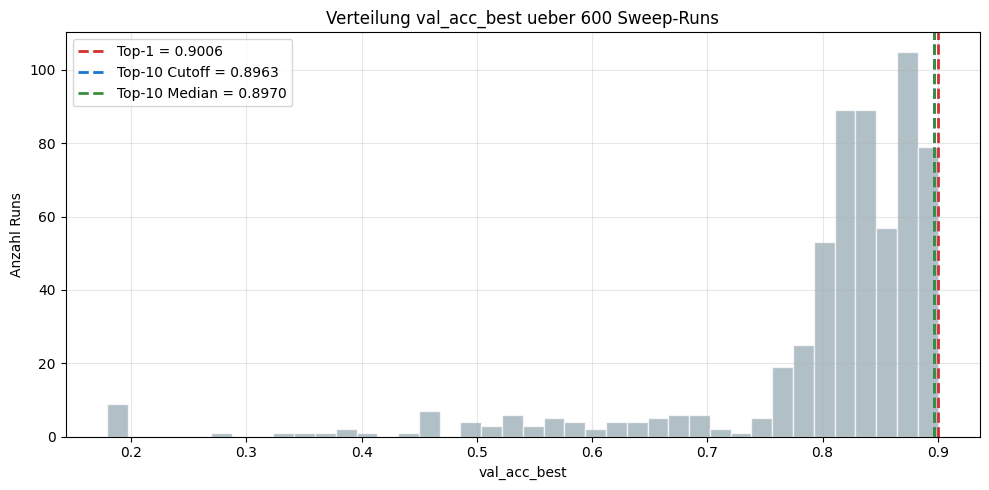


Delta Max <-> Top-10 Median: 0.36 pp -> sehr eng (Plateau bestaetigt)


In [40]:
all_val_acc = np.array(
    [r["val_acc_best"] for r in sweep_run_records if r["val_acc_best"] is not None]
)
top10_vals = np.array([r["val_acc_best"] for r in valid_runs[:10]])

stats = {
    "n_runs": len(all_val_acc),
    "max": float(all_val_acc.max()),
    "top10_median": float(np.median(top10_vals)),
    "top10_mean": float(top10_vals.mean()),
    "top10_std": float(top10_vals.std(ddof=1)),
    "top10_min": float(top10_vals.min()),
    "delta_max_top10_median": float(all_val_acc.max() - np.median(top10_vals)),
    "global_median": float(np.median(all_val_acc)),
    "global_p90": float(np.percentile(all_val_acc, 90)),
}
for k, v in stats.items():
    print(f"  {k:>26}: {v:.4f}" if isinstance(v, float) else f"  {k:>26}: {v}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_val_acc, bins=40, color="#90A4AE", alpha=0.7, edgecolor="white")
ax.axvline(
    stats["max"],
    color="#D32F2F",
    linestyle="--",
    linewidth=2,
    label=f"Top-1 = {stats['max']:.4f}",
)
ax.axvline(
    top10_vals.min(),
    color="#1976D2",
    linestyle="--",
    linewidth=2,
    label=f"Top-10 Cutoff = {top10_vals.min():.4f}",
)
ax.axvline(
    stats["top10_median"],
    color="#388E3C",
    linestyle="--",
    linewidth=2,
    label=f"Top-10 Median = {stats['top10_median']:.4f}",
)
ax.set_xlabel("val_acc_best")
ax.set_ylabel("Anzahl Runs")
ax.set_title(f"Verteilung val_acc_best ueber {len(all_val_acc)} Sweep-Runs")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

delta = stats["delta_max_top10_median"]
if delta < 0.005:
    plateau = "sehr eng (Plateau bestaetigt)"
elif delta < 0.015:
    plateau = "moderat (eher Plateau als Ausreisser)"
else:
    plateau = "weit (Top-1 koennte Ausreisser sein)"
print(f"\nDelta Max <-> Top-10 Median: {delta*100:.2f} pp -> {plateau}")

### Streuung der Top-10 Hyperparameter

Wir prüfen, ob die Top-10 Konfigurationen sich um die Top-1-Werte konzentrieren oder breit über den gesweepten Range verteilen. Konzentration → Sweet Spot bestätigt; Streuung → Modell wenig sensitiv für den Parameter, oder die Spitzenregion ist Sweep-Noise.

Maße: Range (max − min), Coefficient of Variation (Std/Mean) für numerische Parameter; für kategorische Parameter zusätzlich der Modus (häufigster Wert in Top-10).


Top-10 Hyperparameter-Streuung:
       parameter       min    median       max      mean       std     cv       mode
              lr 0.0001054 0.0002225  0.001287 0.0003607 0.0003635  1.008          -
    weight_decay 4.396e-06 4.651e-05 0.0004358 9.669e-05 0.0001329  1.374          -
    dropout_rate    0.1481    0.1759    0.4601    0.2398    0.1137  0.474          -
aug_color_jitter   0.03516     0.185    0.2926    0.1645   0.08965 0.5449          -
      batch_size         8        32        32      24.8     9.578 0.3862  32 (6/10)
    base_filters        32        64        64      54.4     13.49  0.248  64 (6/10)
       fc_hidden        64       256       512     262.4     189.5 0.7222 256 (3/10)
aug_rotation_deg         0         0        20       5.5     7.619  1.385   0 (6/10)


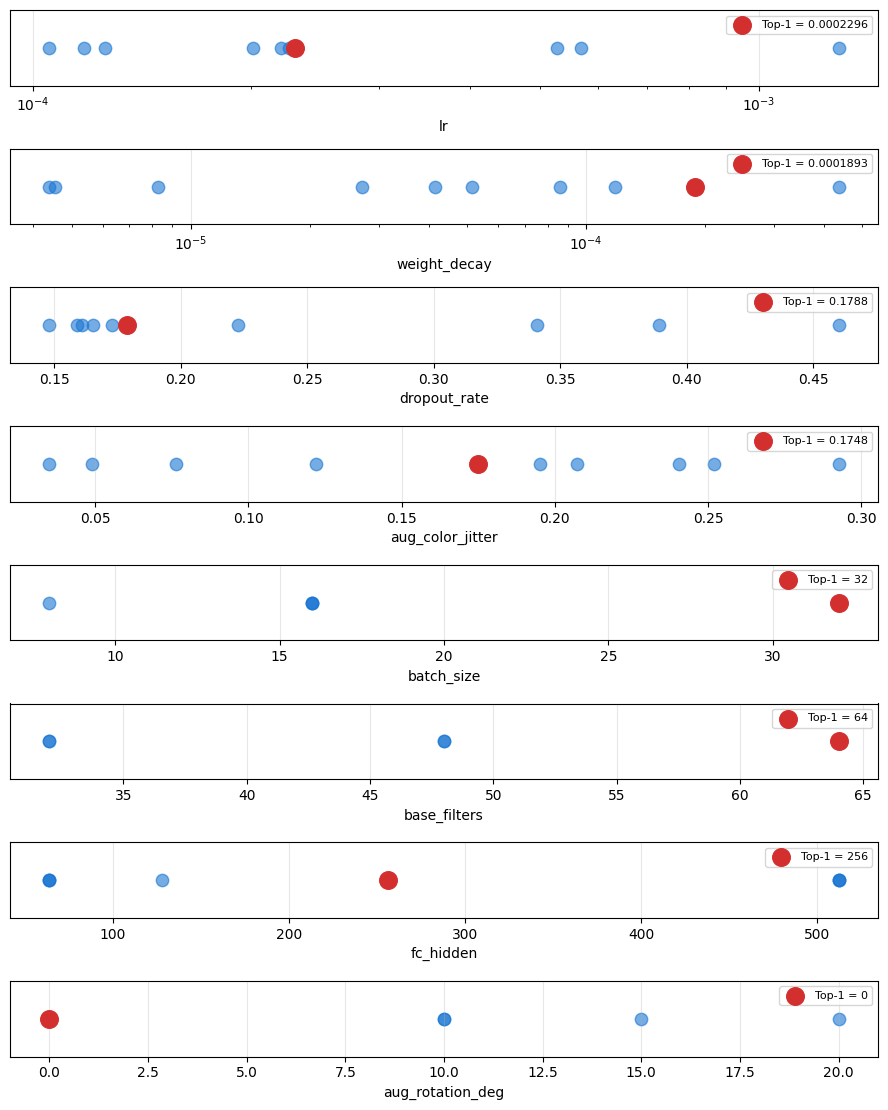

In [41]:
top10_records = valid_runs[:10]
numeric_params = ["lr", "weight_decay", "dropout_rate", "aug_color_jitter"]
categorical_params = ["batch_size", "base_filters", "fc_hidden", "aug_rotation_deg"]

rows = []
for p in numeric_params:
    vals = np.array([r["config"].get(p) for r in top10_records], dtype=float)
    rows.append(
        {
            "parameter": p,
            "min": vals.min(),
            "median": float(np.median(vals)),
            "max": vals.max(),
            "mean": vals.mean(),
            "std": vals.std(ddof=1),
            "cv": vals.std(ddof=1) / abs(vals.mean()) if vals.mean() else float("nan"),
            "mode": "-",
        }
    )
for p in categorical_params:
    vals = [r["config"].get(p) for r in top10_records]
    vals_num = np.array(vals, dtype=float)
    counts = pd.Series(vals).value_counts()
    rows.append(
        {
            "parameter": p,
            "min": vals_num.min(),
            "median": float(np.median(vals_num)),
            "max": vals_num.max(),
            "mean": vals_num.mean(),
            "std": vals_num.std(ddof=1),
            "cv": (
                vals_num.std(ddof=1) / abs(vals_num.mean())
                if vals_num.mean()
                else float("nan")
            ),
            "mode": f"{counts.index[0]} ({counts.iloc[0]}/10)",
        }
    )

streuung_df = pd.DataFrame(rows)
streuung_df_disp = streuung_df.copy()
for c in ["min", "median", "max", "mean", "std", "cv"]:
    streuung_df_disp[c] = streuung_df_disp[c].apply(lambda x: f"{x:.4g}")
print("Top-10 Hyperparameter-Streuung:")
print(streuung_df_disp.to_string(index=False))

# Visuelle Streuung: Top-10 als horizontale Striche entlang des gesweepten Bereichs.
fig, axes = plt.subplots(
    len(numeric_params + categorical_params),
    1,
    figsize=(9, 1.4 * len(numeric_params + categorical_params)),
    sharex=False,
)
for ax, p in zip(axes, numeric_params + categorical_params):
    vals = [r["config"].get(p) for r in top10_records]
    vals_num = np.array(vals, dtype=float)
    use_log = p in ("lr", "weight_decay")
    if use_log:
        ax.set_xscale("log")
    ax.scatter(vals_num, np.zeros_like(vals_num), s=80, alpha=0.6, color="#1976D2")
    ax.scatter(
        [vals_num[0]],
        [0],
        s=160,
        color="#D32F2F",
        zorder=5,
        label=f"Top-1 = {vals_num[0]:.4g}",
    )
    ax.set_yticks([])
    ax.set_xlabel(p)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### Fazit. 
Die Architektur-Parameter batch_size=32 und base_filters=64 clustern klar (jeweils 6/10) — der Sweet Spot ist hier eindeutig bestätigt, und die Top-1-Wahl liegt in beiden Fällen auf dem Modus. dropout_rate konzentriert sich am unteren Rand (Median 0.18, Top-1 ebenfalls bei 0.18) und aug_rotation_deg bevorzugt 0° (6/10), was darauf hindeutet, dass BatchNorm + ColorJitter+HFlip+RandomResizedCrop bereits genug regularisieren. Demgegenüber streuen lr, weight_decay, fc_hidden und aug_color_jitter mit CV ≥ 0.5 über mehr als eine Größenordnung — das Modell ist gegenüber diesen Parametern in der gesweepten Bandbreite weitgehend insensitiv, der Top-1-Wert dort ist also nicht stark privilegiert.

### Bester Run — Konfiguration


In [42]:
best_run = valid_runs[0]
best_config = best_run["config"]

print(f"Bester Run: {best_run['name']}")
print(f"Peak Val Acc: {best_run['val_acc_best']:.4f}")
print(f"Best Epoche:  {best_run['best_epoch']}")
print("\nHyperparameter:")
for k, v in best_config.items():
    if isinstance(v, float):
        print(f"  {k:>20} = {v:.6g}")
    else:
        print(f"  {k:>20} = {v}")

Bester Run: youthful-sweep-213
Peak Val Acc: 0.9006
Best Epoche:  45

Hyperparameter:
                    lr = 0.000229556
             fc_hidden = 256
            batch_size = 32
          base_filters = 64
          dropout_rate = 0.178836
          weight_decay = 0.000189305
      aug_color_jitter = 0.174785
      aug_rotation_deg = 0


## Finales Modell — Multi-Seed Re-Training

Die Best-Config aus dem Sweep wird mit **drei Seeds** neu trainiert. Hintergrund: Der absolute #1-Run aus 600 Random-Runs unterliegt dem Multiple-Comparison-Bias und ist nach oben verzerrt. Ein einzelner Re-Train mit fixem Seed wäre wieder nur eine Punktschätzung — drei Seeds liefern Mittelwert ± Std und zeigen, wie viel des Sweep-Peaks reine Trainings-Varianz ist.

Architektur und Hyperparameter sind in allen drei Seeds identisch zur Top-1-Config; nur der RNG-Seed (Modell-Init, Sample-Reihenfolge) variiert.


In [43]:
class DeepBNCNN(nn.Module):
    """4 Conv-Bloecke mit BN, MaxPool, 3x3 Kernel. FC mit Dropout. Aus H1-H10 abgeleitet."""

    def __init__(
        self, num_classes, base_filters, fc_hidden, dropout_rate, img_size=IMG_SIZE
    ):
        super().__init__()
        c1, c2, c3, c4 = (
            base_filters,
            base_filters * 2,
            base_filters * 4,
            base_filters * 8,
        )

        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(c3, c4, kernel_size=3, padding=1),
            nn.BatchNorm2d(c4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 16
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c4 * feat_size * feat_size, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(fc_hidden, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

### Augmentation-Pipeline gemäss Best-Config


In [44]:
final_train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.4, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(
            brightness=best_config["aug_color_jitter"],
            contrast=best_config["aug_color_jitter"],
            saturation=best_config["aug_color_jitter"],
        ),
        transforms.RandomRotation(best_config["aug_rotation_deg"]),
        transforms.ToTensor(),
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)

final_train_dataset = IntelImageDataset(hf_train, transform=final_train_transform)
final_train_loader = DataLoader(
    final_train_dataset, batch_size=best_config["batch_size"], shuffle=True
)
final_val_loader = DataLoader(
    val_dataset, batch_size=best_config["batch_size"], shuffle=False
)

### Multi-Seed Training mit Best-Val-Acc-Checkpointing TODO: text anpassen: return_best_state wird nun überall verwendet

Die Funktion `train_model` trägt seit dem Refactoring das Best-Val-Acc-Checkpointing intern (gibt bei `return_best_state=True` den State der Peak-Epoche zurück). Pro Seed wird ein eigener W&B-Run unter `group="final-multi-seed"` angelegt; **vor** `wandb.finish()` werden Confusion Matrix, Per-Class Precision/Recall/F1 und Top-Loss-Samples auf Validation **und** Test in den jeweiligen Run geloggt — dadurch sind alle Detail-Metriken pro Seed im W&B-Report verfügbar.


In [45]:
# Test-Loader hier definieren (wird vom Multi-Seed-Loop fuer evaluate_model + evaluate genutzt).
final_test_loader = DataLoader(
    test_dataset, batch_size=best_config["batch_size"], shuffle=False
)

seed_results = {}

for seed in SEEDS:
    print(f"\n{'='*60}\nSeed {seed}\n{'='*60}")

    run = wandb.init(
        project="del-mini-challenge",
        name=f"final-seed-{seed}",
        group="final-multi-seed",
        config={
            **best_config,
            "epochs": PHASE_FINAL_EPOCHS,
            "seed": seed,
            "experiment": "final-model-multi-seed",
        },
    )

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = DeepBNCNN(
        num_classes=NUM_CLASSES,
        base_filters=best_config["base_filters"],
        fc_hidden=best_config["fc_hidden"],
        dropout_rate=best_config["dropout_rate"],
    ).to(device)
    optimizer = optim.Adam(
        model.parameters(),
        lr=best_config["lr"],
        weight_decay=best_config["weight_decay"],
    )

    history, best_state = train_model(
        model,
        final_train_loader,
        final_val_loader,
        criterion,
        optimizer,
        device,
        epochs=PHASE_FINAL_EPOCHS,
        log_wandb=True,
        return_best_state=True,
    )
    model.load_state_dict(best_state)
    best_val_acc = history["val_acc_best"][-1]
    best_epoch = history["best_epoch"][-1]

    # Per-Class Metriken auf Val + Test in den AKTIVEN Run loggen,
    # bevor wandb.finish() aufgerufen wird (sonst landen sie nirgendwo).
    print(f"\n--- Seed {seed}: Validation-Eval ---")
    val_eval = evaluate_model(
        model, final_val_loader, CLASS_NAMES, device, channel_mean, channel_std
    )
    print(f"\n--- Seed {seed}: Test-Eval ---")
    test_eval = evaluate_model(
        model, final_test_loader, CLASS_NAMES, device, channel_mean, channel_std
    )
    test_loss, test_acc = evaluate(model, final_test_loader, criterion, device)

    wandb.summary["val_acc_best"] = best_val_acc
    wandb.summary["best_epoch"] = best_epoch
    wandb.summary["test_acc"] = test_acc
    wandb.summary["test_loss"] = test_loss

    wandb.finish()

    seed_results[seed] = {
        "model": model,
        "history": history,
        "val_acc_best": best_val_acc,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "val_eval": val_eval,
        "test_eval": test_eval,
    }
    print(
        f"\nSeed {seed} fertig — Peak Val Acc {best_val_acc:.4f}@{best_epoch} "
        f"| Test Acc {test_acc:.4f}"
    )


Seed 42


Epoch   0 | Train Loss: 0.9534  Acc: 0.6402 | Val Loss: 0.6769  Acc: 0.7560 | Best 0.7560@0
Epoch   1 | Train Loss: 0.6930  Acc: 0.7501 | Val Loss: 0.5995  Acc: 0.7927 | Best 0.7927@1
Epoch   2 | Train Loss: 0.6396  Acc: 0.7671 | Val Loss: 0.5193  Acc: 0.8165 | Best 0.8165@2
Epoch   3 | Train Loss: 0.6100  Acc: 0.7780 | Val Loss: 0.4995  Acc: 0.8233 | Best 0.8233@3
Epoch   4 | Train Loss: 0.5489  Acc: 0.8033 | Val Loss: 0.6914  Acc: 0.7528 | Best 0.8233@3
Epoch   5 | Train Loss: 0.5238  Acc: 0.8076 | Val Loss: 0.4763  Acc: 0.8365 | Best 0.8365@5
Epoch   6 | Train Loss: 0.5059  Acc: 0.8165 | Val Loss: 0.4530  Acc: 0.8436 | Best 0.8436@6
Epoch   7 | Train Loss: 0.4940  Acc: 0.8225 | Val Loss: 0.4068  Acc: 0.8596 | Best 0.8596@7
Epoch   8 | Train Loss: 0.4751  Acc: 0.8262 | Val Loss: 0.4556  Acc: 0.8468 | Best 0.8596@7
Epoch   9 | Train Loss: 0.4472  Acc: 0.8367 | Val Loss: 0.4501  Acc: 0.8447 | Best 0.8596@7
Epoch  10 | Train Loss: 0.4456  Acc: 0.8389 | Val Loss: 0.4127  Acc: 0.8593 | Be

best_epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▇▇██████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
eval/accuracy,▁█
train_acc,▁▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇█████████████
train_loss,█▅▅▅▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▁▅▆▆▅▆▇▇▆▇▆▇▇▅▇█▇▇█▇█▇▇▇▇▇▇██████▇██
val_acc_best,▁▃▄▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████████████████
val_loss,█▆▅▅█▃▄▄▃▃▂▃▃▃▃▂▂▄▂▂▂▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂
best_epoch,45
epoch,49
eval/accuracy,0.89733



Seed 42 fertig — Peak Val Acc 0.8967@45 | Test Acc 0.8973

Seed 7


Epoch   0 | Train Loss: 0.9578  Acc: 0.6320 | Val Loss: 0.6809  Acc: 0.7577 | Best 0.7577@0
Epoch   1 | Train Loss: 0.7180  Acc: 0.7333 | Val Loss: 0.5814  Acc: 0.7902 | Best 0.7902@1
Epoch   2 | Train Loss: 0.6318  Acc: 0.7706 | Val Loss: 0.5713  Acc: 0.8019 | Best 0.8019@2
Epoch   3 | Train Loss: 0.5986  Acc: 0.7825 | Val Loss: 0.5903  Acc: 0.7895 | Best 0.8019@2
Epoch   4 | Train Loss: 0.5592  Acc: 0.8003 | Val Loss: 0.6583  Acc: 0.7645 | Best 0.8019@2
Epoch   5 | Train Loss: 0.5437  Acc: 0.8032 | Val Loss: 0.4595  Acc: 0.8404 | Best 0.8404@5
Epoch   6 | Train Loss: 0.5058  Acc: 0.8160 | Val Loss: 0.4194  Acc: 0.8536 | Best 0.8536@6
Epoch   7 | Train Loss: 0.4874  Acc: 0.8192 | Val Loss: 0.4869  Acc: 0.8393 | Best 0.8536@6
Epoch   8 | Train Loss: 0.4769  Acc: 0.8274 | Val Loss: 0.4070  Acc: 0.8579 | Best 0.8579@8
Epoch   9 | Train Loss: 0.4576  Acc: 0.8338 | Val Loss: 0.4185  Acc: 0.8582 | Best 0.8582@9
Epoch  10 | Train Loss: 0.4439  Acc: 0.8398 | Val Loss: 0.3824  Acc: 0.8689 | Be

best_epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅██
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,█▁
train_acc,▁▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train_loss,█▆▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▃▁▆▅▆▆▇▇▆▇▆▇▇▇▇▇▇▇▇█▇█▇█▇█▇█▇▇▇██▇▇▇█
val_acc_best,▁▃▃▃▃▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
val_loss,█▆▆▆█▃▄▃▃▃▃▂▃▂▃▂▂▂▁▂▂▁▃▁▂▁▂▂▂▂▂▂▁▁▂▂▂▂▁▂
best_epoch,47
epoch,49
eval/accuracy,0.889



Seed 7 fertig — Peak Val Acc 0.8992@47 | Test Acc 0.8890

Seed 123


Epoch   0 | Train Loss: 0.9724  Acc: 0.6255 | Val Loss: 0.7251  Acc: 0.7424 | Best 0.7424@0
Epoch   1 | Train Loss: 0.7342  Acc: 0.7309 | Val Loss: 0.5646  Acc: 0.8083 | Best 0.8083@1
Epoch   2 | Train Loss: 0.6400  Acc: 0.7660 | Val Loss: 0.5281  Acc: 0.8222 | Best 0.8222@2
Epoch   3 | Train Loss: 0.6014  Acc: 0.7857 | Val Loss: 0.4867  Acc: 0.8375 | Best 0.8375@3
Epoch   4 | Train Loss: 0.5563  Acc: 0.7976 | Val Loss: 0.4977  Acc: 0.8240 | Best 0.8375@3
Epoch   5 | Train Loss: 0.5294  Acc: 0.8082 | Val Loss: 0.4804  Acc: 0.8261 | Best 0.8375@3
Epoch   6 | Train Loss: 0.5092  Acc: 0.8162 | Val Loss: 0.5966  Acc: 0.7748 | Best 0.8375@3
Epoch   7 | Train Loss: 0.4894  Acc: 0.8210 | Val Loss: 0.4345  Acc: 0.8457 | Best 0.8457@7
Epoch   8 | Train Loss: 0.4781  Acc: 0.8296 | Val Loss: 0.4283  Acc: 0.8443 | Best 0.8457@7
Epoch   9 | Train Loss: 0.4694  Acc: 0.8240 | Val Loss: 0.4116  Acc: 0.8632 | Best 0.8632@9
Epoch  10 | Train Loss: 0.4426  Acc: 0.8408 | Val Loss: 0.4167  Acc: 0.8518 | Be

best_epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▅▅▅▅▆▆▆▆▇▇▇▇█████████████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,█▁
train_acc,▁▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▅▅▅▆▆▆▆▇▇▆▆▇█▇▇▇▇██▇▇█▇▇█▇█▇█▇▇▇▇▇██▇▇
val_acc_best,▁▄▅▅▅▅▆▆▆▆▇▇▇▇██████████████████████████
val_loss,█▅▅▄▄▆▃▃▃▃▃▂▃▃▂▂▂▂▂▂▁▂▂▁▂▂▁▁▁▂▂▂▂▂▂▂▁▁▁▂
best_epoch,34
epoch,49
eval/accuracy,0.88967



Seed 123 fertig — Peak Val Acc 0.8963@34 | Test Acc 0.8897


### Lernkurven (Best Seed)

Die Lernkurven werden für den Seed mit der höchsten Peak-Val-Accuracy gezeigt; die anderen beiden Seeds sind im W&B-Group `final-multi-seed` einsehbar.


Bester Seed (nach val_acc_best): 7 -> 0.8992


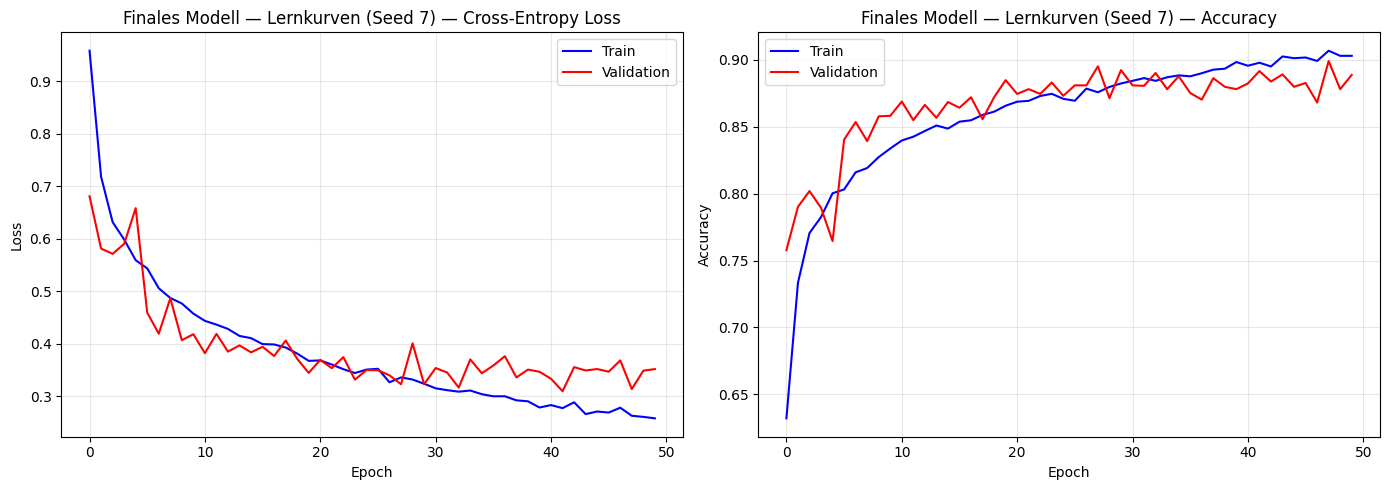

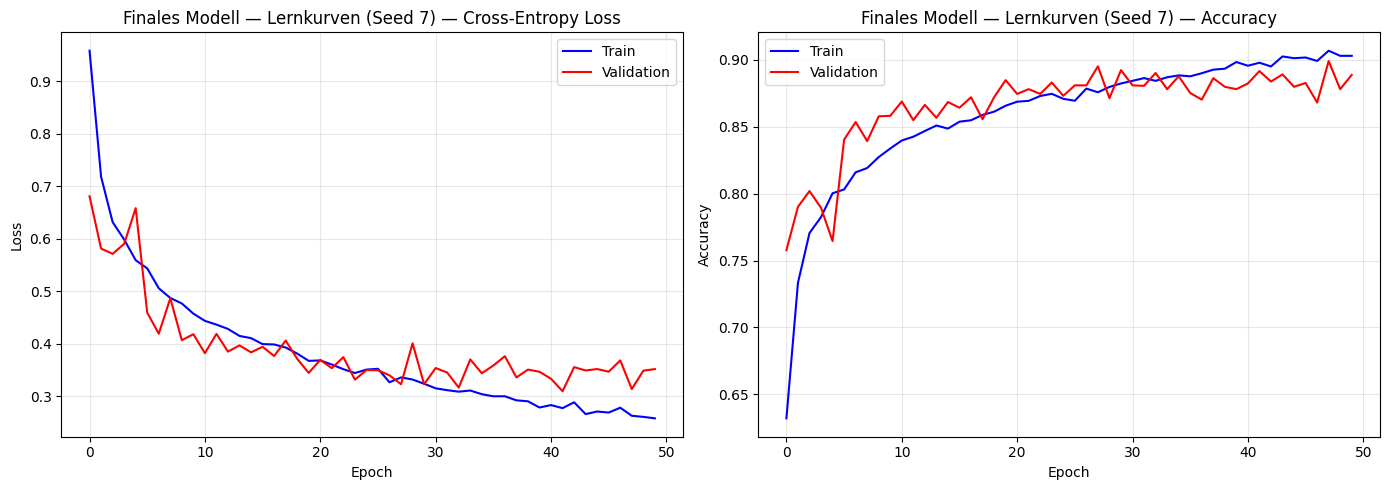

In [46]:
best_seed = max(SEEDS, key=lambda s: seed_results[s]["val_acc_best"])
print(
    f"Bester Seed (nach val_acc_best): {best_seed} -> {seed_results[best_seed]['val_acc_best']:.4f}"
)

final_model = seed_results[best_seed]["model"]
final_history = seed_results[best_seed]["history"]

plot_training(final_history, title=f"Finales Modell — Lernkurven (Seed {best_seed})")

### Multi-Seed Auswertung

Vergleich der drei Re-Trainings auf Validation und Test. Mittelwert ± Std liefert eine ehrlichere Punktschätzung als ein einzelner Run, weil Trainings-Noise (Init, Sample-Order, MPS-Nichtdeterminismus) ausgemittelt wird. Per-Class Metriken sind pro Seed im jeweiligen W&B-Run unter `eval/per_class_*` zu finden.


Multi-Seed Ergebnisse:
 seed  best_epoch  val_acc_best  test_acc  test_loss
   42          45      0.896687  0.897333   0.287831
    7          47      0.899181  0.889000   0.324745
  123          34      0.896331  0.889667   0.316119

Val Acc (peak):  0.8974 +/- 0.0016 (min 0.8963, max 0.8992)
Test Acc:        0.8920 +/- 0.0046 (min 0.8890, max 0.8973)

Sweep Top-1 Peak Val Acc: 0.9006
Bias (Sweep - Multi-Seed Val): +0.32 pp


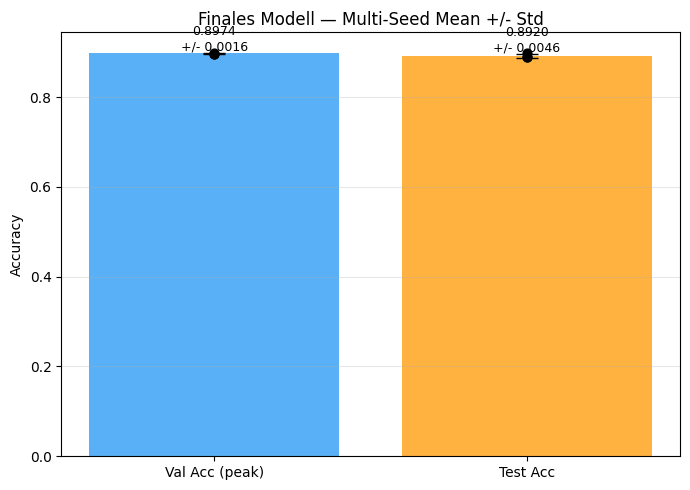

In [47]:
seed_summary_df = pd.DataFrame(
    [
        {
            "seed": s,
            "best_epoch": seed_results[s]["best_epoch"],
            "val_acc_best": seed_results[s]["val_acc_best"],
            "test_acc": seed_results[s]["test_acc"],
            "test_loss": seed_results[s]["test_loss"],
        }
        for s in SEEDS
    ]
)
print("Multi-Seed Ergebnisse:")
print(seed_summary_df.to_string(index=False))

val_mean = seed_summary_df["val_acc_best"].mean()
val_std = seed_summary_df["val_acc_best"].std(ddof=1)
test_mean = seed_summary_df["test_acc"].mean()
test_std = seed_summary_df["test_acc"].std(ddof=1)

print(
    f"\nVal Acc (peak):  {val_mean:.4f} +/- {val_std:.4f} "
    f"(min {seed_summary_df['val_acc_best'].min():.4f}, "
    f"max {seed_summary_df['val_acc_best'].max():.4f})"
)
print(
    f"Test Acc:        {test_mean:.4f} +/- {test_std:.4f} "
    f"(min {seed_summary_df['test_acc'].min():.4f}, "
    f"max {seed_summary_df['test_acc'].max():.4f})"
)
print(f"\nSweep Top-1 Peak Val Acc: {best_run['val_acc_best']:.4f}")
print(
    f"Bias (Sweep - Multi-Seed Val): {(best_run['val_acc_best'] - val_mean)*100:+.2f} pp"
)

fig, ax = plt.subplots(figsize=(7, 5))
metrics = ["Val Acc (peak)", "Test Acc"]
means = [val_mean, test_mean]
stds = [val_std, test_std]
xs = np.arange(len(metrics))
bars = ax.bar(xs, means, yerr=stds, capsize=8, color=["#2196F3", "#FF9800"], alpha=0.75)
for s in SEEDS:
    ax.scatter(0, seed_results[s]["val_acc_best"], color="black", zorder=5, s=40)
    ax.scatter(1, seed_results[s]["test_acc"], color="black", zorder=5, s=40)
ax.set_xticks(xs)
ax.set_xticklabels(metrics)
ax.set_ylabel("Accuracy")
ax.set_title("Finales Modell — Multi-Seed Mean +/- Std")
ax.grid(True, alpha=0.3, axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.005, f"{m:.4f}\n+/- {s:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Analyse und Reflexion

_Wird nach dem Multi-Seed-Lauf ergänzt. Drei Punkte adressieren:_
_- **Winner's Curse:** Differenz Sweep-Peak (Top-1) vs. Multi-Seed-Mittelwert; quantifiziert die Optimismus-Verzerrung der absoluten #1 aus 600 Random Runs._
_- **Top-10 Streuung:** Welche Hyperparameter clustern (Sweet Spot bestätigt) vs. streuen breit (geringe Sensitivität oder Sweep-Noise)._
_- **Statistische Unsicherheit:** Mittelwert ± Std über 3 Seeds für Validation und Test als realistische Punktschätzung des finalen Modells._
